# Lesson 131 · GNN + tabular encoder stack: trace the forward and backward pass

Executed teacher reference · PROVIDED: inspect. TODO: implement. CHECK: run unchanged. EXIT: defend. Default execution replays author traces and runs a small full-stack fixture. Fresh full-data training has an explicit gate.

In [1]:
# @colab-bootstrap: install missing dependencies; report actual versions.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','torch':'torch','torch_frame':'pytorch-frame==0.2.3','torch_geometric':'torch-geometric==2.6.1','relbench':'relbench==1.1.0','pooch':'pooch'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual notebook runtime:',sys.version)
print({k:importlib.metadata.version(k) for k in ['numpy','pandas','torch','pytorch-frame','torch-geometric','relbench']})


Actual notebook runtime: 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
{'numpy': '2.5.0', 'pandas': '3.0.3', 'torch': '2.13.0+cpu', 'pytorch-frame': '0.3.0', 'torch-geometric': '2.8.0.post1', 'relbench': '1.1.0'}


In [2]:
import copy,math,statistics,json,hashlib
from pathlib import Path
import torch
def rejected(fn):
    try:fn()
    except (ValueError,TypeError):return
    raise AssertionError('Expected rejection of invalid input')

<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 130 to this lesson</p>
<p>A working pipeline still leaves its internal computation hidden. Follow one real batch through row encoding, time addition, messages, root readout and gradients.</p>
<details><summary>Quick prerequisite reminder</summary><p>A tensor shape counts rows and coordinates. Autograd records differentiable operations. Detaching a tensor preserves its current values but cuts its gradient path.</p></details>
</aside>
<!-- sequence-review:end -->



## The question this lesson answers

**Can you follow one prediction through the actual network, and show how its loss changes the row encoders?** Lesson 130 established ownership of the experiment. This lesson opens the computation inside that experiment. Your deliverable is an annotated forward/backward trace with real tensor shapes, a checked gradient path and a defensible reproduction verdict.

[Student notebook](https://avistian.github.io/relational/labs/0131-gnn-tabular-stack.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0131-gnn-tabular-stack.html) · [Reference card](https://avistian.github.io/relational/reference/gnn-tabular-stack.html) · [Reproduction contract](https://avistian.github.io/relational/labs/l131-reproduction.md)

Recall the distinction between query roots, context occurrences and table parameters.

Before reading: which rows receive labels? Why can one driver appear several times in a minibatch? Does freezing a row encoder necessarily change today's prediction?

Read [Fey et al., §5, relational deep learning blueprint](https://proceedings.mlr.press/v235/fey24a.html) for the decomposition. Use [Robinson et al., RelBench v1 §3, Appendix B and Table 7](https://arxiv.org/html/2407.20060v1) for the implemented baseline and numerical target. These are different sources with different jobs: the blueprint motivates the stack; the benchmark specifies the selected experiment.

**Route.** First predict shapes on paper. Then trace the measured batch and complete the three functions. Run the short standalone notebook to inspect the author evidence and a small neural parity fixture. Finally use the explicit full-training gate for five fresh fits. The default replay, small fixture and full reproduction have separate evidence labels.



## 1 · Model architecture: a batch is a collection of questions

A query is `(driverId, cutoff)`. Its label is mean finishing position in the next 60 days. The full experiment contains 7,453 training, 499 validation and 760 test queries. A context node is a permitted database row that helps answer a query. It is not another supervised example.

The loader builds disjoint contexts for 512 queries at a time. A database row reused by two queries becomes two **node occurrences**, each with its own query owner and time cutoff. `n_id` maps an occurrence back to its database row; `batch` maps it to a query; `input_id` maps a supervised query back to the task table. These indices answer different questions.

<figure class="stream-figure" tabindex="0">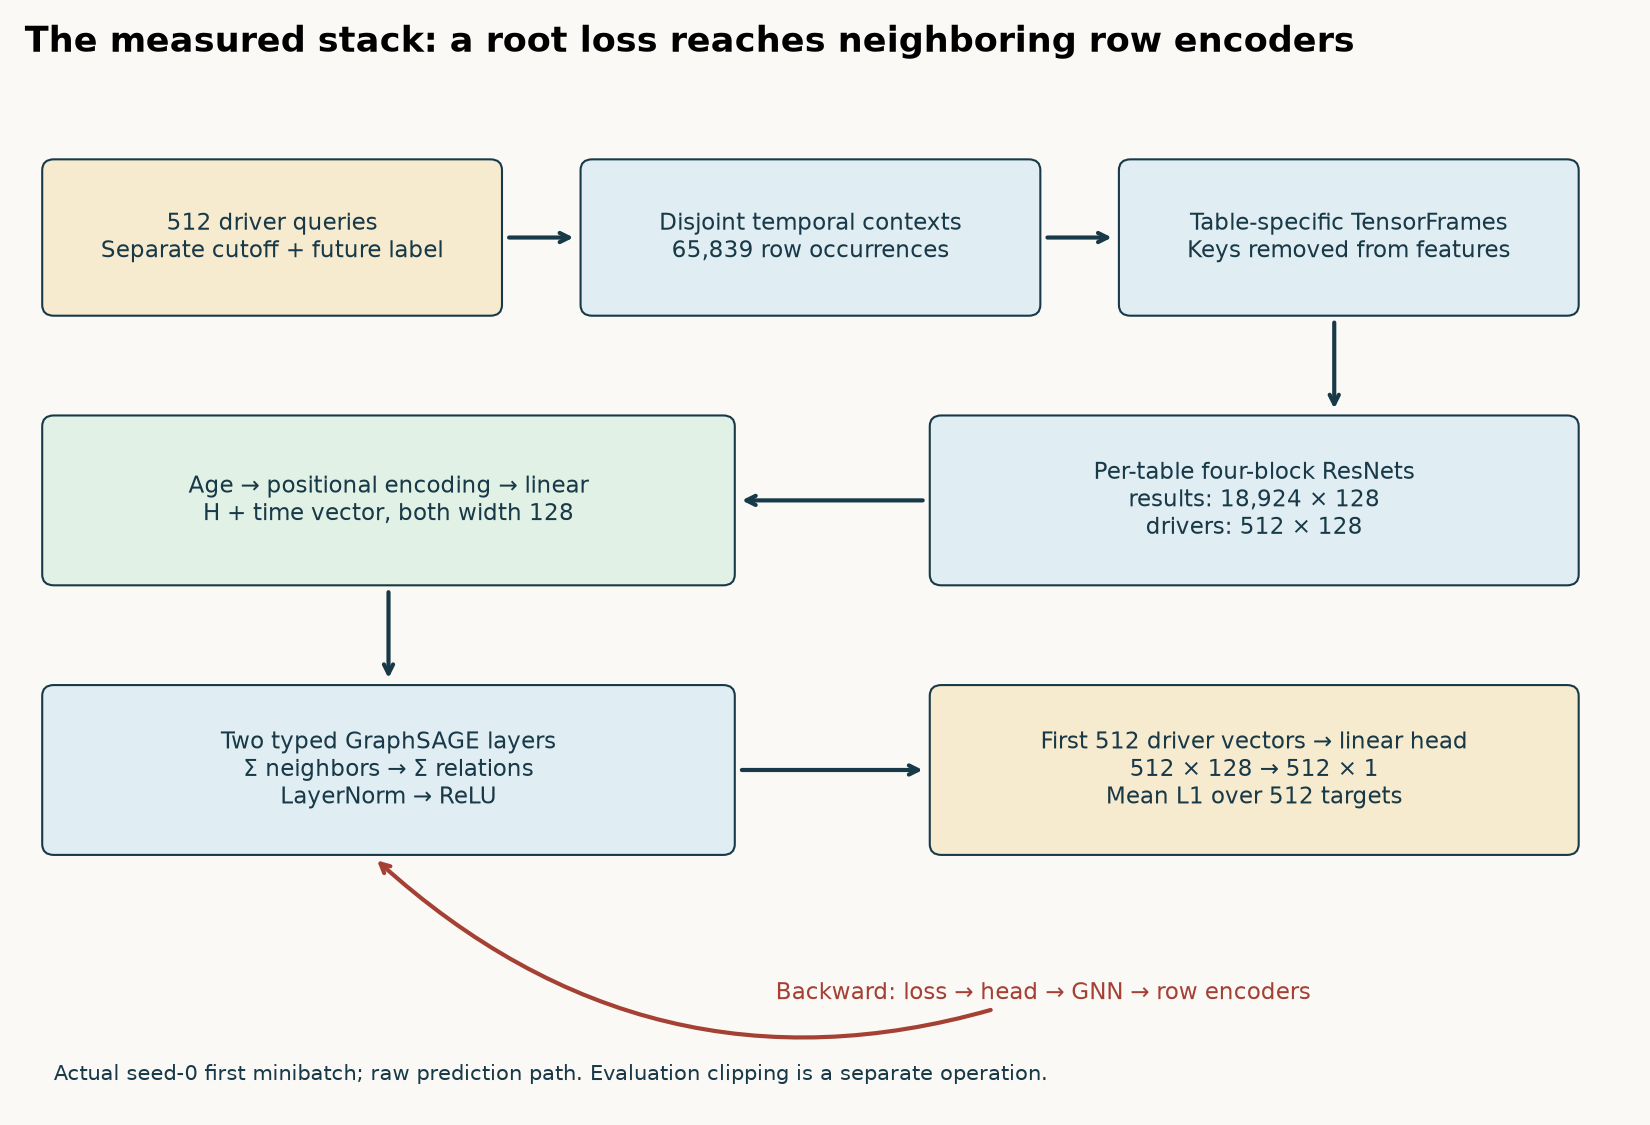<figcaption>Measured seed-0 first-batch counts, typed row encoders, time addition, two graph layers and root loss. The backward arrow reaches connected context encoders.</figcaption></figure>

**Diagram trace.** Trace the forward values and backward gradient path separately. Where would detaching preserve the current prediction but stop encoder learning? On a narrow screen, scroll the figure sideways.

The graph has nine table types. Each table owns a separate four-block Frame ResNet. Its output width is 128 regardless of how many raw columns that table has. Parameters are shared across occurrences of rows from the same table, but not across different table encoders. A row encoder can therefore process drivers and results with different input schemas while delivering compatible vectors to the graph network.

Time encodings are added to dated rows. Two heterogeneous GraphSAGE layers exchange information along foreign-key and reverse edges. Each relation uses neighbor **sum** aggregation in this experiment; relation outputs are also summed for each destination type. Node-wise LayerNorm and ReLU follow each layer. The scalar head reads only the first B driver vectors.

**Predict.** If the sampled batch contains 512 query roots and thousands of context occurrences, how many predictions and loss terms should it produce? Write the answer before inspecting the trace.

| Table | Actual row occurrences | Encoded shape |
|---|---:|---|
| races | 21,939 | [21939, 128] |
| drivers | 512 | [512, 128] |
| constructor_standings | 0 | [0, 128] |
| standings | 21,059 | [21059, 128] |
| constructors | 1,380 | [1380, 128] |
| constructor_results | 0 | [0, 128] |
| circuits | 0 | [0, 128] |
| qualifying | 2,025 | [2025, 128] |
| results | 18,924 | [18924, 128] |

The root head returns **[512, 1]**; this first-batch raw L1 loss is **13.797042**. First three predictions: 0.1245, -0.1279, 0.0334.

These are observed shapes from the first real training minibatch before any optimizer update. They are not the 99-node exhaustive single-query neighborhood used in Lesson 130. Sampling, query multiplicity and node type all affect the counts.



## 2 · From typed columns to row vectors

A TensorFrame groups columns by semantic type. Numerical values receive learned linear encodings; categorical values use embedding lookups; timestamps have their own encoding; precomputed text embeddings receive a learned projection. The ResNet combines those column representations into a row vector. Primary and foreign keys define identity and connectivity and are removed from feature columns by the released graph builder.

[Lesson 125](https://avistian.github.io/relational/lessons/0125-pytorch-frame-deep-dive.html) opened the row encoder. Here its output becomes the GNN's input. The question changes from “how is this row represented?” to “how can a root's loss train a representation of a neighboring row?”

**TODO 1 — `activation_summary`.** Report shape, mean, maximum absolute value, zero fraction and a small coordinate sample. Detach only the copy used for logging. Replacing the live activation with its detached copy changes training. Reject nonfinite forward activations explicitly; an empty tensor has no numerical mean.

The canonical code is visible in the notebook, including the typed encoders and ResNets. Read-only primitive source is included alongside its license and pinned provenance. No opaque model import is the sole explanation of the computation.



### TODO · activation_summary

Implement the contract explained above. The CHECK tests errors as well as the happy path.

In [3]:
def activation_summary(x):
    if not torch.isfinite(x).all():
        raise ValueError('Nonfinite activation')
    v=x.detach().float().cpu()
    return dict(shape=list(x.shape),mean=float(v.mean()) if v.numel() else None,
                max_abs=float(v.abs().max()) if v.numel() else None,
                zero_fraction=float((v==0).float().mean()) if v.numel() else None,
                first_rows=v[:3,:6].tolist() if v.ndim==2 else v[:6].tolist())

In [4]:
def check_summary(fn):
    x=torch.tensor([[1.,-2.],[0.,3.]],requires_grad=True)
    s=fn(x)
    assert s['shape']==[2,2] and s['mean']==.5 and s['max_abs']==3.
    assert s['zero_fraction']==.25 and s['first_rows']==[[1.,-2.],[0.,3.]]
    assert x.requires_grad and x.grad is None
    assert fn(torch.empty(0,2))['mean'] is None
    rejected(lambda:fn(torch.tensor([[float('nan')]])))
check_summary(activation_summary)
print("PASS: activation_summary")

PASS: activation_summary


## 3 · A node occurrence carries its owner's clock

For node occurrence i owned by query q, its age in days is `(cutoff[q] − node_time[i]) / 86400`. The index q is `batch_index[i]`, not the table row ID. Looking up the first query's cutoff for all rows silently misrepresents a disjoint batch.

<figure class="stream-figure" tabindex="0">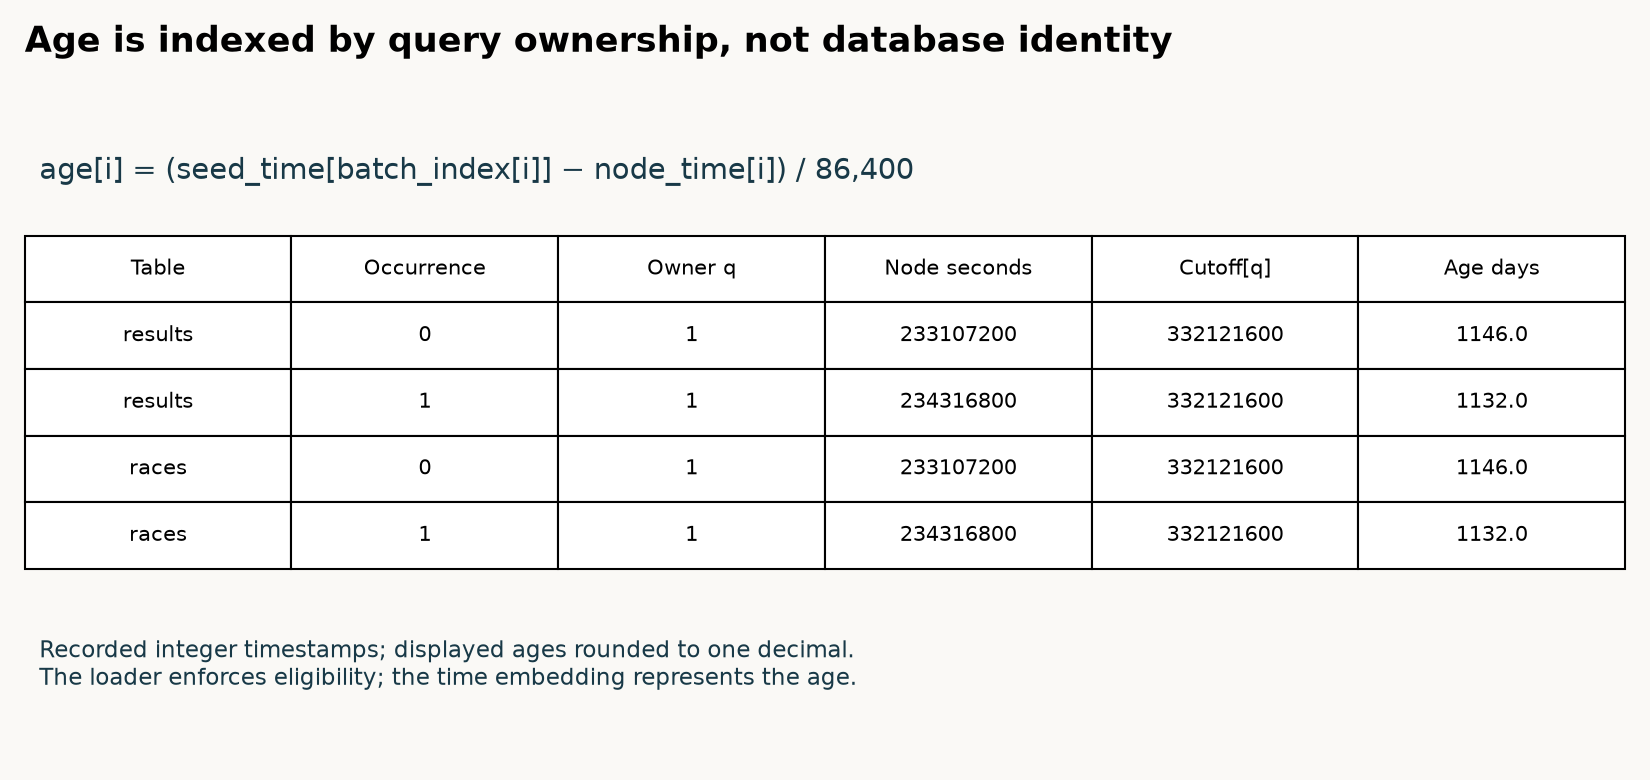<figcaption>Recorded occurrence owners gather their own query cutoffs. Integer seconds become days; no shared first-query clock.</figcaption></figure>

**TODO 2 — `relative_days`.** Validate the owner indices and tensor lengths, gather the correct root cutoff, reject a future row and convert seconds to days. The real trace replay calls your function on recorded timestamps. Static tables without timestamps receive no invented age.

**Predict before changing the control.** In the synthetic example, query cutoffs are days 10 and 20; node times are days 9 and 18; owners are 0 and 1. Correct ages are 1 and 2. What happens if both occurrences use query 0's clock?

Static arithmetic: correct ages [1,2] days; first-query clock gives [1,-8], which must be rejected.

The model applies a positional encoding to each age, followed by a table-specific linear layer, and adds the resulting 128-vector to the row representation. This addition does not enforce eligibility; the sampler and temporal audit do. A learned time vector cannot repair a future row that was incorrectly admitted.

<figure class="stream-figure" tabindex="0">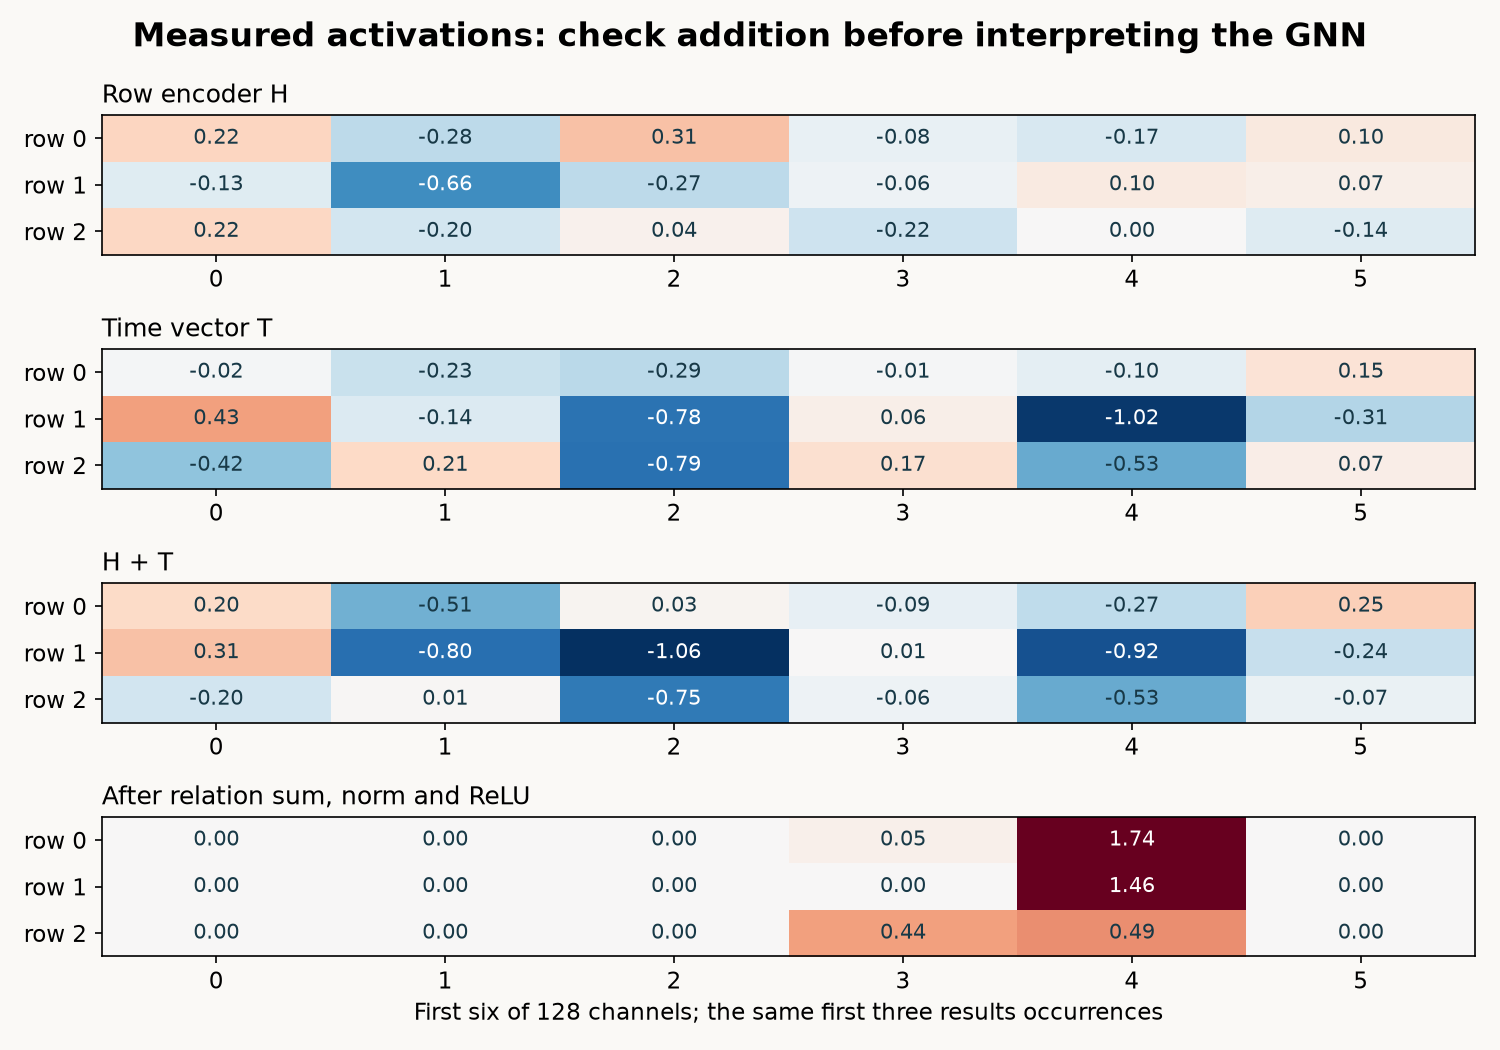<figcaption>The first three results occurrences and six of 128 channels. Check H + T coordinate by coordinate; later layers mix channels.</figcaption></figure>

Read the first row as an arithmetic check: the same occurrence's encoded features plus its time vector must equal the vector passed into message passing. Later channels mix through learned matrices, so channel 0 is not a conserved semantic feature.



### TODO · relative_days

Implement the contract explained above. The CHECK tests errors as well as the happy path.

In [5]:
def relative_days(seed_time, node_time, batch_index):
    if seed_time.ndim!=1 or node_time.ndim!=1 or batch_index.shape!=node_time.shape:
        raise ValueError('One time and one owner per node occurrence required')
    if batch_index.dtype!=torch.long or (batch_index<0).any() or (batch_index>=len(seed_time)).any():
        raise ValueError('Invalid query owner')
    delta=seed_time[batch_index]-node_time
    if not torch.isfinite(delta).all() or (delta<0).any():
        raise ValueError('Future or nonfinite context time')
    return delta/(60*60*24)

In [6]:
def check_days(fn):
    seed=torch.tensor([864000,1728000]);times=torch.tensor([777600,1555200,691200]);owner=torch.tensor([0,1,0])
    torch.testing.assert_close(fn(seed,times,owner),torch.tensor([1.,2.,2.]),rtol=0,atol=0)
    rejected(lambda:fn(seed,torch.tensor([1800000]),torch.tensor([1])))
    rejected(lambda:fn(seed,times,torch.tensor([0,2,0])))
    rejected(lambda:fn(seed,times,torch.tensor([0,1])))
check_days(relative_days)
print("PASS: relative_days")

PASS: relative_days


## 4 · Message passing changes representations; the head selects roots

For relation r from source type s to destination type t, the released sum-GraphSAGE operator computes a learned transform of the summed neighbor features plus a learned transform of the destination's own features. HeteroConv sums these relation outputs for destination t. Because each relation has its own root transform, the root contribution is also repeated across incoming relation types. This is the pinned implementation, not an assumed generic GNN equation.

After relation summation, node-wise LayerNorm normalizes each row across its channels and ReLU sets negative coordinates to zero. The next layer repeats this process. Two rounds make two-hop input information available to a root. The released wrapper accepts sampled-size metadata but its forward implementation processes the supplied node and edge dictionaries without trimming them layer by layer.

```python
def traced_forward(model, batch, entity_table, detach_encoder=False):
    trace={};seed_time=batch[entity_table].seed_time
    def record(stage,values):
        trace[stage]={k:activation_summary(v) for k,v in values.items()}
    x=model.encoder(batch.tf_dict)
    record('row_encoder',x)
    if detach_encoder:x={k:v.detach() for k,v in x.items()}
    times={};days={}
    for kind,node_time in batch.time_dict.items():
        days[kind]=relative_days(seed_time,node_time,batch.batch_dict[kind])
        times[kind]=model.temporal_encoder.lin_dict[kind](model.temporal_encoder.encoder_dict[kind](days[kind]))
    record('relative_days',days);record('time_encoder',times)
    x={k:v+times[k] if k in times else v for k,v in x.items()}
    for kind,embedding in model.embedding_dict.items():x[kind]=x[kind]+embedding(batch[kind].n_id)
    record('time_added',x)
    for layer,(conv,norms) in enumerate(zip(model.gnn.convs,model.gnn.norms),1):
        x=conv(x,batch.edge_index_dict)
        record(f'layer_{layer}_relation_sum',x)
        x={k:norms[k](v) for k,v in x.items()}
        record(f'layer_{layer}_normalized',x)
        x={k:v.relu() for k,v in x.items()}
        record(f'layer_{layer}_relu',x)
    roots=seed_readout(x[entity_table],int(seed_time.size(0)))
    prediction=model.head(roots)
    record('root_readout',{entity_table:roots});record('prediction',{entity_table:prediction})
    return prediction,trace
```

**TODO 3 — `seed_readout`.** Return `hidden[:B]`, reject invalid B, and preserve autograd. This works because this loader places the query roots first in their entity type. It is a loader contract, not a rule that any arbitrary graph tensor satisfies. Context driver rows after the roots must not receive the task's root labels.

In the recorded first batch, all 512 driver occurrences are roots, so an incorrect “all driver rows” readout could pass that example accidentally. The CHECK deliberately supplies five driver rows but only two roots; it verifies both output count and which rows receive gradients.

The head maps `[B,128]` to `[B,1]`. Training uses mean L1 over B query labels. Evaluation additionally clips predictions to training-label percentiles. Do not put evaluation clipping into the training-loss trace: it would describe a different gradient.



### TODO · seed_readout

Implement the contract explained above. The CHECK tests errors as well as the happy path.

In [7]:
def seed_readout(hidden, batch_size):
    if type(batch_size) is not int or hidden.ndim!=2 or not 0<batch_size<=len(hidden):
        raise ValueError('Invalid root count')
    return hidden[:batch_size]

In [8]:
def check_readout(fn):
    x=torch.arange(15,dtype=torch.float32).reshape(5,3).requires_grad_()
    y=fn(x,2);assert y.shape==(2,3)
    torch.testing.assert_close(y,x[:2]);y.sum().backward()
    torch.testing.assert_close(x.grad,torch.tensor([[1.,1.,1.],[1.,1.,1.],[0.,0.,0.],[0.,0.,0.],[0.,0.,0.]]))
    rejected(lambda:fn(x,6));rejected(lambda:fn(x,0));rejected(lambda:fn(x,1.5))
check_readout(seed_readout)
print("PASS: seed_readout")

PASS: seed_readout


## 5 · The backward pass explains what is learned

Backpropagation applies the chain rule from the root loss through the head, graph layers, time addition and row encoders. A context row can receive a gradient even though it has no direct task label: its representation contributed to a supervised root. Shared table parameters accumulate contributions from all their occurrences.

The trace uses three isolated copies of the same model on the same real batch and random state: the original forward, the explicitly instrumented forward, and a version that detaches encoded rows. It compares outputs, loss, gradient presence, nonfinite masks and finite gradient values. The original fit's parameters, buffers and random state are preserved.

<figure class="stream-figure" tabindex="0">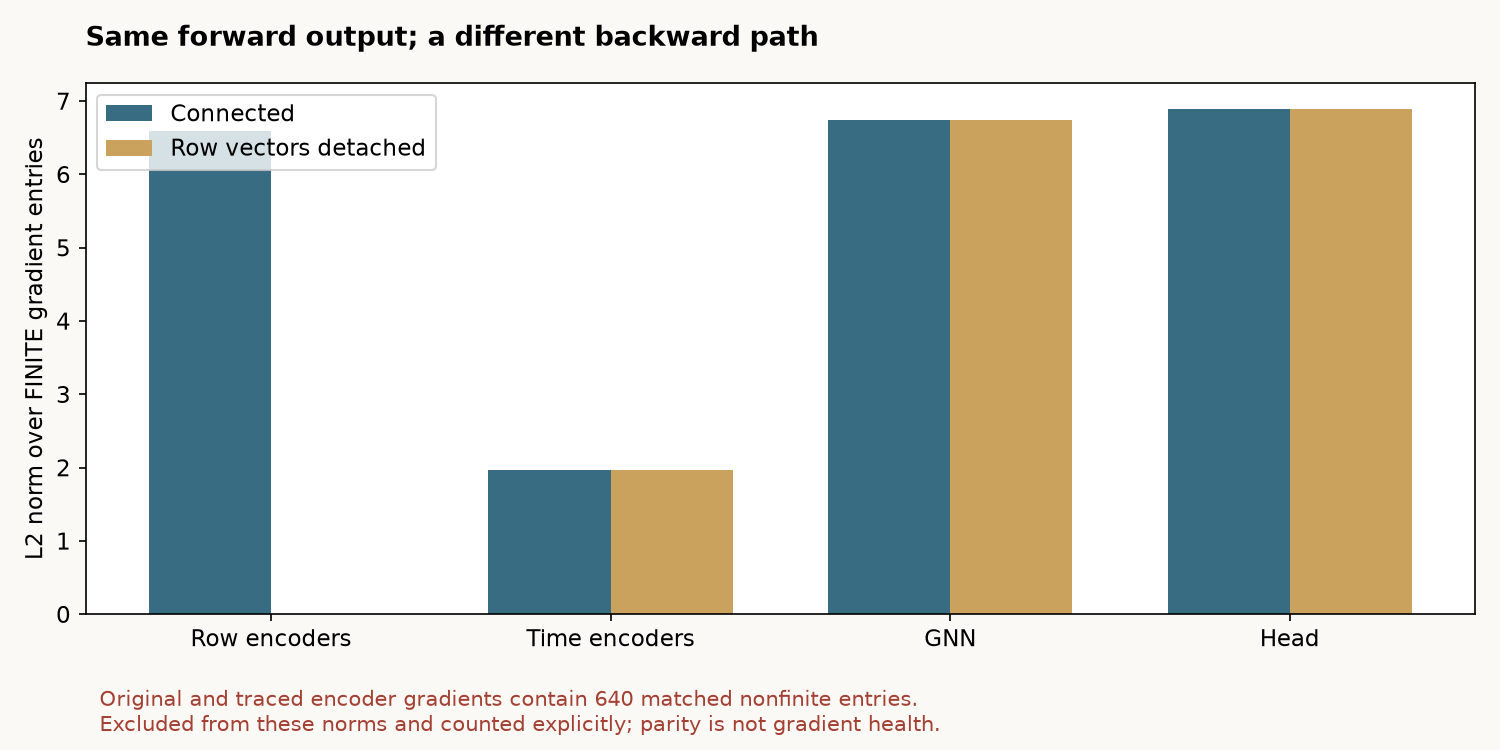<figcaption>Finite-entry gradient norms for the same batch, weights and random state. Nonfinite entries are counted separately; detach removes row-encoder gradients.</figcaption></figure>

**Predict.** Detach the row vectors immediately after encoding. Will the current prediction change? Will the row encoder receive gradients? Will the GNN still receive gradients?

Static intervention: predictions agree within measured tolerance; detached row encoders have no gradients, while GNN and head retain gradients.

**Measured caveat.** The seed-0 original and traced models both contain **640 nonfinite gradient entries**, in `encoder.encoders.results.encoder.encoder_dict.numerical.weight`. Nonfinite masks match; the maximum finite gradient discrepancy is **1.19e-07**. The initial pilot checker stopped on these NaNs. The corrected audit checks mask equality and finite values separately, and retains the original algorithm. This is source parity with an exposed pathology, not a claim of healthy gradients.

The pinned `StypeEncoder.forward` applies `nan_to_num` **after** feature encoding. A separately executed minimal example, `nan_to_num(w * NaN)`, produces zero forward output but a NaN gradient for w. This explains how finite activations can coexist with nonfinite gradients; the [diagnostic](https://avistian.github.io/relational/labs/_missing_gradient_l131_results.json) is separate from the five-seed benchmark. Repairing the encoder would be a new experimental variant.

A gradient norm describes local sensitivity under this batch and parameter state. It is not a causal feature attribution or a universal importance ranking. A missing gradient, a zero finite gradient and a nonfinite gradient are different observations; the trace keeps them separate.

**Failure diagnosis.** Explain why each bug is caught by a different check: (1) all context rows reach the head; (2) all nodes use the first root cutoff; (3) an activation logger replaces live tensors with detached values. A passing shape check alone does not catch all three.



## 6 · Reproduce the complete selected experiment

The named target is RelBench v1 Table 7, basic RDL on `rel-f1/driver-position`: five fresh seeds, ten complete epochs each, full graph and official query splits. The pinned model uses width128, two layers, fanouts `[128,64]`, uniform temporal sampling, batch512, Adam0.005 and mean L1. Choose the first strictly improved validation MAE checkpoint. Evaluate the frozen checkpoint and independently rescore every prediction by exact query identity.

<figure class="stream-figure" tabindex="0">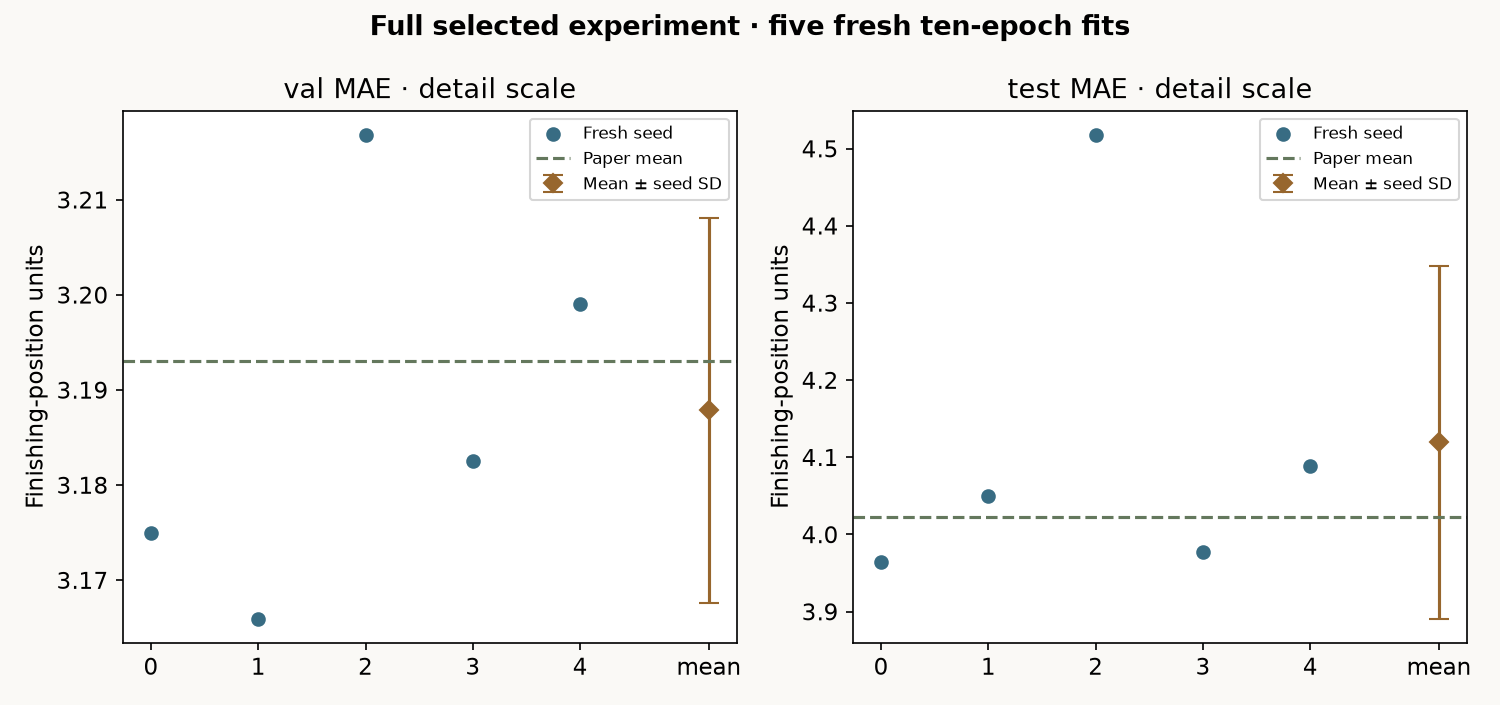<figcaption>Five fresh ten-epoch full-data fits. Points are seeds; diamonds show mean and sample seed SD; dashed lines are published means. Detail scales differ by split.</figcaption></figure>

**Fresh selected released-protocol experiment: COMPLETE.**

| Split | Mean MAE | Sample seed SD | Paper mean | Descriptive verdict |
|---|---:|---:|---:|---|
| val | 3.187860 | 0.020249 | 3.193 | CLOSE |
| test | 4.119595 | 0.228565 | 4.022 | CLOSE |

| Seed | Selected epoch | Final validation MAE | Test MAE |
|---|---:|---:|---:|
| 0 | 10 | 3.174941 | 3.963691 |
| 1 | 10 | 3.165964 | 4.049560 |
| 2 | 10 | 3.216836 | 4.517951 |
| 3 | 10 | 3.182499 | 3.977688 |
| 4 | 7 | 3.199059 | 4.089087 |

All **6,295** final predictions independently scored and compared with the original model. **403,895** sampled query occurrences audited. Successful pilot plus five-fit worker resource estimate **USD 0.061831**; failed pilot and notebook validation are accounted separately within the aggregate budget, with unitemized overhead. [Measured summary](https://avistian.github.io/relational/labs/evidence/l131/summary.json).

**Portable full-training gate: PASS.** All 24 notebook code cells executed in a separate pinned GPU environment, including five fresh fits and five stack traces. Its predictions were independently rescored; these validation runs are separate from the primary results above. The preempted attempt is preserved. [Gate verification](https://avistian.github.io/relational/labs/_notebook_gpu_l131_results.json). Live Colab remains NOT_CHECKED.

The reported closeness uses a predeclared absolute mean tolerance of 0.2 MAE. Seed SD is descriptive variability, not a confidence interval or a proof of equivalence. Final validation scores can differ from checkpoint-selection scores because evaluation resamples neighborhoods.

**What “full” covers here.** Every prescribed run, epoch, database row and final task query in this selected released-protocol experiment. It does not cover the paper's other 29 tasks. Exact historical training commit, seeds and runtime are not established. Released `[128,64]` fanouts differ from the paper table's `128`; feature statistics use the database through the test cap; original arrival and mutable-feature histories are unavailable. Numerical agreement does not erase these gaps.

The [protocol ledger](https://avistian.github.io/relational/labs/l131-reproduction.md) contains exact commands, archive hashes, source revision, budget reservations, the failed pilot and successful recovery, and the distinction between paper, local fixture, instrumented batch and full-data evidence. Instrumentation findings do not silently change the released algorithm.



## 7 · Your annotated trace and written defense

Submit the three working functions and an annotated trace that:

1. Maps a database row ID, occurrence index and query owner to their separate meanings.
2. Derives one recorded age and one coordinate of the time-vector addition.
3. Explains the observed `[B,128] → [B,1]` readout and which rows receive loss.
4. Predicts and explains the detach intervention, including the finite/nonfinite gradient distinction.
5. States the strongest reproduction claim supported by the seed artifacts and lists unresolved protocol gaps.

Return tomorrow and redraw the stack without opening the notebook. Explain why gradients can reach an unlabeled neighbor. Then compare with [Lesson 076](https://avistian.github.io/relational/lessons/0076-encoder-predictor-stack.html) and [Lesson 115](https://avistian.github.io/relational/lessons/0115-graph-ml-design-patterns.html); Lesson 132 will ask what identity-aware message passing adds to this baseline.

Author execution does not establish learner mastery: **PENDING_WRITTEN_DEFENSE**. Ask your tutor about any tensor, index, gradient or evidence claim that you cannot yet explain. Live Colab and deployment remain **NOT_CHECKED** unless separately verified.

<!-- sequence-next:start -->
**Carry this forward.** Ask how representations can depend on which entity is the current query root. [Continue to Lesson 132](https://avistian.github.io/relational/lessons/0132-identity-aware-message-passing.html).
<!-- sequence-next:end -->


## Replay the measured computation

Your functions inspect recorded real clocks and activation coordinates. This does not regenerate the full neural trace; the visible model fixture and fresh-training gate follow.

In [9]:
# PROVIDED: recorded real activations and query clocks, not a fresh neural run.
import io,base64,hashlib,json,statistics,math
from pathlib import Path
import numpy as np
recorded_trace = {'status': 'PASS', 'scope': 'First real training minibatch before any optimizer update; cloned models, training mode', 'batch_size': 512, 'inputs': {'races': {'rows': 21939, 'columns': {'categorical': ['year'], 'numerical': ['round'], 'timestamp': ['date', 'time'], 'embedding': ['name']}, 'node_ids': [285, 286, 287], 'owners': [1, 1, 1]}, 'drivers': {'rows': 512, 'columns': {'timestamp': ['dob'], 'embedding': ['code', 'driverRef', 'forename', 'nationality', 'surname']}, 'node_ids': [372, 118, 436], 'owners': [0, 1, 2]}, 'constructor_standings': {'rows': 0, 'columns': {'numerical': ['points', 'position', 'wins'], 'timestamp': ['date']}, 'node_ids': [], 'owners': []}, 'standings': {'rows': 21059, 'columns': {'numerical': ['points', 'position', 'wins'], 'timestamp': ['date']}, 'node_ids': [13056, 13097, 13143], 'owners': [1, 1, 1]}, 'constructors': {'rows': 1380, 'columns': {'embedding': ['constructorRef', 'name', 'nationality']}, 'node_ids': [2, 15, 2], 'owners': [9, 9, 10]}, 'constructor_results': {'rows': 0, 'columns': {'numerical': ['points'], 'timestamp': ['date']}, 'node_ids': [], 'owners': []}, 'circuits': {'rows': 0, 'columns': {'numerical': ['alt', 'lat', 'lng'], 'embedding': ['circuitRef', 'country', 'location', 'name']}, 'node_ids': [], 'owners': []}, 'qualifying': {'rows': 2025, 'columns': {'numerical': ['number', 'position'], 'timestamp': ['date']}, 'node_ids': [825, 848, 867], 'owners': [9, 9, 9]}, 'results': {'rows': 18924, 'columns': {'numerical': ['fastestLap', 'grid', 'laps', 'milliseconds', 'number', 'points', 'position', 'positionOrder', 'rank', 'statusId'], 'timestamp': ['date']}, 'node_ids': [6718, 6724, 6787], 'owners': [1, 1, 1]}}, 'time_inputs': {'races': {'node_seconds': [233107200, 234316800, 235526400, 236736000, 237859200, 239155200], 'owner': [1, 1, 1, 1, 1, 1], 'cutoff_seconds': [-305510400, 332121600, -326246400, 720921600, 746841600, 492825600, -429926400, 202521600, -289958400, 928281600, 1031961600, 264729600, 917913600, 15897600, -590630400, 829785600, 591321600, 363225600, 321753600, -362534400, 814233600, -15206400, 264729600, -170726400, 430617600, -559526400, -523238400, 41817600, 575769600, -518054400, 617241600, 1083801600, -67046400, -196646400, 902361600, -554342400, 104025600, 622425600, 352857600, 498009600, -274406400, -108518400, -82598400, 1057881600, 378777600, -518054400, 560217600, -455846400, 166233600, -362534400, 166233600, 995673600, 67737600, -82598400, 669081600, 1026777600, 399513600, 337305600, 969753600, 389145600, 783129600, -575078400, 612057600, 923097600, -72230400, 394329600, -134438400, 83289600, 161049600, 10713600, -523238400, 186969600, 98841600, 612057600, 171417600, 420249600, 591321600, 555033600, -393638400, 917913600, 145497600, 337305600, -305510400, 954201600, -321062400, -554342400, 192153600, 233625600, 10713600, 902361600, -139622400, 617241600, -440294400, 425433600, -554342400, 777945600, -175910400, 777945600, 632793600, 617241600, 777945600, -590630400, 1000857600, 243993600, 617241600, 809049600, 1083801600, 793497600, 243993600, 653529600, 736473600, 824601600, 648345600, 1063065600, 145497600, -232934400, -429926400, -398822400, -191462400, 368409600, 264729600, 83289600, -528422400, 803865600, 243993600, 21081600, 762393600, 855705600, -429926400, 451353600, -181094400, -51494400, 83289600, -455846400, 21081600, 477273600, 378777600, 648345600, 741657600, 249177600, 1016409600, 923097600, 321753600, -367718400, 985305600, 1026777600, 316569600, -492134400, 617241600, 461721600, 140313600, -461030400, 109209600, 933465600, 285465600, 777945600, 617241600, 860889600, 212889600, 337305600, 176601600, 871257600, 544665600, -331430400, 886809600, 399513600, 358041600, -232934400, -326246400, 259545600, 1026777600, -378086400, 622425600, 1057881600, -191462400, 93657600, 192153600, -108518400, -201830400, -67046400, -440294400, 145497600, -181094400, 632793600, 285465600, 643161600, 47001600, 886809600, 228441600, -492134400, 166233600, -305510400, 674265600, 83289600, 798681600, 254361600, 482457600, -336614400, 487641600, -336614400, -336614400, 907545600, 104025600, -429926400, -20390400, 93657600, 212889600, 492825600, 663897600, -590630400, 586137600, 446169600, 1088985600, 98841600, 632793600, 1063065600, 897177600, 78105600, -554342400, 52185600, 720921600, -10022400, -10022400, -72230400, -492134400, -611366400, 259545600, -367718400, -455846400, -538790400, 456537600, 643161600, 5529600, 700185600, 124761600, -393638400, 741657600, 15897600, 762393600, -362534400, -15206400, 451353600, 399513600, -165542400, 171417600, 829785600, -113702400, 793497600, -56678400, 161049600, 544665600, 233625600, -518054400, -367718400, 798681600, -590630400, 736473600, 171417600, 891993600, -523238400, 202521600, -518054400, 21081600, 834969600, -232934400, 311385600, -528422400, 337305600, 301017600, -331430400, 259545600, 461721600, 192153600, -424742400, 135129600, -144806400, 871257600, 166233600, 679449600, 171417600, -461030400, 741657600, 777945600, -305510400, -113702400, 964569600, -274406400, 643161600, 161049600, -424742400, -538790400, -362534400, 1057881600, 145497600, 358041600, 301017600, 166233600, -398822400, 1031961600, -139622400, 207705600, 145497600, 746841600, 1073433600, 653529600, 513561600, 52185600, -67046400, 461721600, 228441600, 632793600, -616550400, -25574400, -528422400, 777945600, 907545600, -476582400, -486950400, -440294400, 1000857600, -30758400, 124761600, 674265600, 316569600, 648345600, 1052697600, 140313600, 731289600, 166233600, 306201600, -160358400, -201830400, 368409600, 803865600, 109209600, -196646400, 560217600, 456537600, 663897600, 606873600, 290649600, -554342400, -108518400, -305510400, -181094400, 762393600, 653529600, 207705600, 316569600, 466905600, 399513600, 674265600, 98841600, 254361600, 705369600, 114393600, 715737600, 451353600, 684633600, -305510400, -461030400, 798681600, 425433600, -481766400, 674265600, -357350400, 518745600, 254361600, 135129600, -175910400, -492134400, 523929600, 466905600, 949017600, 622425600, -336614400, 549849600, 98841600, 891993600, 876441600, 1094169600, -528422400, 129945600, 321753600, 93657600, 544665600, -201830400, 285465600, 933465600, 192153600, -41126400, -481766400, -118886400, -575078400, -113702400, 586137600, -289958400, -362534400, 798681600, 746841600, 544665600, 1011225600, 606873600, 928281600, 1052697600, -232934400, 425433600, -134438400, -331430400, 233625600, 860889600, -98150400, 140313600, 337305600, 311385600, 1047513600, 326937600, 10713600, -559526400, -362534400, 124761600, -367718400, -326246400, 202521600, 446169600, -367718400, 964569600, 834969600, 622425600, 980121600, 233625600, -585446400, 461721600, -113702400, 78105600, 1094169600, 389145600, 321753600, -134438400, 176601600, -212198400, -30758400, 954201600, -264038400, -481766400, -611366400, -554342400, 679449600, 47001600, 290649600, 399513600, 140313600, 83289600, 809049600, 591321600, 637977600, 389145600, 1088985600, 269913600, 218073600, 492825600, 358041600, 104025600, -518054400, -549158400, 1078617600, -455846400, 72921600, 928281600, 705369600, -207014400, 383961600, 332121600, 78105600, 72921600, 959385600, -10022400, 41817600, 129945600, 466905600, -523238400, 897177600, -269222400, 876441600, 679449600, 1042329600, -367718400, 243993600, -492134400, 938649600, -175910400, -201830400, -429926400, 663897600, -367718400, -336614400, -232934400, -424742400, 529113600, 643161600, 866073600, -321062400, -212198400, -523238400, 202521600, 793497600, 5529600, 352857600, -56678400, 1016409600, 1021593600, 394329600]}, 'constructor_standings': {'node_seconds': [], 'owner': [], 'cutoff_seconds': [-305510400, 332121600, -326246400, 720921600, 746841600, 492825600, -429926400, 202521600, -289958400, 928281600, 1031961600, 264729600, 917913600, 15897600, -590630400, 829785600, 591321600, 363225600, 321753600, -362534400, 814233600, -15206400, 264729600, -170726400, 430617600, -559526400, -523238400, 41817600, 575769600, -518054400, 617241600, 1083801600, -67046400, -196646400, 902361600, -554342400, 104025600, 622425600, 352857600, 498009600, -274406400, -108518400, -82598400, 1057881600, 378777600, -518054400, 560217600, -455846400, 166233600, -362534400, 166233600, 995673600, 67737600, -82598400, 669081600, 1026777600, 399513600, 337305600, 969753600, 389145600, 783129600, -575078400, 612057600, 923097600, -72230400, 394329600, -134438400, 83289600, 161049600, 10713600, -523238400, 186969600, 98841600, 612057600, 171417600, 420249600, 591321600, 555033600, -393638400, 917913600, 145497600, 337305600, -305510400, 954201600, -321062400, -554342400, 192153600, 233625600, 10713600, 902361600, -139622400, 617241600, -440294400, 425433600, -554342400, 777945600, -175910400, 777945600, 632793600, 617241600, 777945600, -590630400, 1000857600, 243993600, 617241600, 809049600, 1083801600, 793497600, 243993600, 653529600, 736473600, 824601600, 648345600, 1063065600, 145497600, -232934400, -429926400, -398822400, -191462400, 368409600, 264729600, 83289600, -528422400, 803865600, 243993600, 21081600, 762393600, 855705600, -429926400, 451353600, -181094400, -51494400, 83289600, -455846400, 21081600, 477273600, 378777600, 648345600, 741657600, 249177600, 1016409600, 923097600, 321753600, -367718400, 985305600, 1026777600, 316569600, -492134400, 617241600, 461721600, 140313600, -461030400, 109209600, 933465600, 285465600, 777945600, 617241600, 860889600, 212889600, 337305600, 176601600, 871257600, 544665600, -331430400, 886809600, 399513600, 358041600, -232934400, -326246400, 259545600, 1026777600, -378086400, 622425600, 1057881600, -191462400, 93657600, 192153600, -108518400, -201830400, -67046400, -440294400, 145497600, -181094400, 632793600, 285465600, 643161600, 47001600, 886809600, 228441600, -492134400, 166233600, -305510400, 674265600, 83289600, 798681600, 254361600, 482457600, -336614400, 487641600, -336614400, -336614400, 907545600, 104025600, -429926400, -20390400, 93657600, 212889600, 492825600, 663897600, -590630400, 586137600, 446169600, 1088985600, 98841600, 632793600, 1063065600, 897177600, 78105600, -554342400, 52185600, 720921600, -10022400, -10022400, -72230400, -492134400, -611366400, 259545600, -367718400, -455846400, -538790400, 456537600, 643161600, 5529600, 700185600, 124761600, -393638400, 741657600, 15897600, 762393600, -362534400, -15206400, 451353600, 399513600, -165542400, 171417600, 829785600, -113702400, 793497600, -56678400, 161049600, 544665600, 233625600, -518054400, -367718400, 798681600, -590630400, 736473600, 171417600, 891993600, -523238400, 202521600, -518054400, 21081600, 834969600, -232934400, 311385600, -528422400, 337305600, 301017600, -331430400, 259545600, 461721600, 192153600, -424742400, 135129600, -144806400, 871257600, 166233600, 679449600, 171417600, -461030400, 741657600, 777945600, -305510400, -113702400, 964569600, -274406400, 643161600, 161049600, -424742400, -538790400, -362534400, 1057881600, 145497600, 358041600, 301017600, 166233600, -398822400, 1031961600, -139622400, 207705600, 145497600, 746841600, 1073433600, 653529600, 513561600, 52185600, -67046400, 461721600, 228441600, 632793600, -616550400, -25574400, -528422400, 777945600, 907545600, -476582400, -486950400, -440294400, 1000857600, -30758400, 124761600, 674265600, 316569600, 648345600, 1052697600, 140313600, 731289600, 166233600, 306201600, -160358400, -201830400, 368409600, 803865600, 109209600, -196646400, 560217600, 456537600, 663897600, 606873600, 290649600, -554342400, -108518400, -305510400, -181094400, 762393600, 653529600, 207705600, 316569600, 466905600, 399513600, 674265600, 98841600, 254361600, 705369600, 114393600, 715737600, 451353600, 684633600, -305510400, -461030400, 798681600, 425433600, -481766400, 674265600, -357350400, 518745600, 254361600, 135129600, -175910400, -492134400, 523929600, 466905600, 949017600, 622425600, -336614400, 549849600, 98841600, 891993600, 876441600, 1094169600, -528422400, 129945600, 321753600, 93657600, 544665600, -201830400, 285465600, 933465600, 192153600, -41126400, -481766400, -118886400, -575078400, -113702400, 586137600, -289958400, -362534400, 798681600, 746841600, 544665600, 1011225600, 606873600, 928281600, 1052697600, -232934400, 425433600, -134438400, -331430400, 233625600, 860889600, -98150400, 140313600, 337305600, 311385600, 1047513600, 326937600, 10713600, -559526400, -362534400, 124761600, -367718400, -326246400, 202521600, 446169600, -367718400, 964569600, 834969600, 622425600, 980121600, 233625600, -585446400, 461721600, -113702400, 78105600, 1094169600, 389145600, 321753600, -134438400, 176601600, -212198400, -30758400, 954201600, -264038400, -481766400, -611366400, -554342400, 679449600, 47001600, 290649600, 399513600, 140313600, 83289600, 809049600, 591321600, 637977600, 389145600, 1088985600, 269913600, 218073600, 492825600, 358041600, 104025600, -518054400, -549158400, 1078617600, -455846400, 72921600, 928281600, 705369600, -207014400, 383961600, 332121600, 78105600, 72921600, 959385600, -10022400, 41817600, 129945600, 466905600, -523238400, 897177600, -269222400, 876441600, 679449600, 1042329600, -367718400, 243993600, -492134400, 938649600, -175910400, -201830400, -429926400, 663897600, -367718400, -336614400, -232934400, -424742400, 529113600, 643161600, 866073600, -321062400, -212198400, -523238400, 202521600, 793497600, 5529600, 352857600, -56678400, 1016409600, 1021593600, 394329600]}, 'standings': {'node_seconds': [233107200, 234316800, 235526400, 236736000, 237859200, 239155200], 'owner': [1, 1, 1, 1, 1, 1], 'cutoff_seconds': [-305510400, 332121600, -326246400, 720921600, 746841600, 492825600, -429926400, 202521600, -289958400, 928281600, 1031961600, 264729600, 917913600, 15897600, -590630400, 829785600, 591321600, 363225600, 321753600, -362534400, 814233600, -15206400, 264729600, -170726400, 430617600, -559526400, -523238400, 41817600, 575769600, -518054400, 617241600, 1083801600, -67046400, -196646400, 902361600, -554342400, 104025600, 622425600, 352857600, 498009600, -274406400, -108518400, -82598400, 1057881600, 378777600, -518054400, 560217600, -455846400, 166233600, -362534400, 166233600, 995673600, 67737600, -82598400, 669081600, 1026777600, 399513600, 337305600, 969753600, 389145600, 783129600, -575078400, 612057600, 923097600, -72230400, 394329600, -134438400, 83289600, 161049600, 10713600, -523238400, 186969600, 98841600, 612057600, 171417600, 420249600, 591321600, 555033600, -393638400, 917913600, 145497600, 337305600, -305510400, 954201600, -321062400, -554342400, 192153600, 233625600, 10713600, 902361600, -139622400, 617241600, -440294400, 425433600, -554342400, 777945600, -175910400, 777945600, 632793600, 617241600, 777945600, -590630400, 1000857600, 243993600, 617241600, 809049600, 1083801600, 793497600, 243993600, 653529600, 736473600, 824601600, 648345600, 1063065600, 145497600, -232934400, -429926400, -398822400, -191462400, 368409600, 264729600, 83289600, -528422400, 803865600, 243993600, 21081600, 762393600, 855705600, -429926400, 451353600, -181094400, -51494400, 83289600, -455846400, 21081600, 477273600, 378777600, 648345600, 741657600, 249177600, 1016409600, 923097600, 321753600, -367718400, 985305600, 1026777600, 316569600, -492134400, 617241600, 461721600, 140313600, -461030400, 109209600, 933465600, 285465600, 777945600, 617241600, 860889600, 212889600, 337305600, 176601600, 871257600, 544665600, -331430400, 886809600, 399513600, 358041600, -232934400, -326246400, 259545600, 1026777600, -378086400, 622425600, 1057881600, -191462400, 93657600, 192153600, -108518400, -201830400, -67046400, -440294400, 145497600, -181094400, 632793600, 285465600, 643161600, 47001600, 886809600, 228441600, -492134400, 166233600, -305510400, 674265600, 83289600, 798681600, 254361600, 482457600, -336614400, 487641600, -336614400, -336614400, 907545600, 104025600, -429926400, -20390400, 93657600, 212889600, 492825600, 663897600, -590630400, 586137600, 446169600, 1088985600, 98841600, 632793600, 1063065600, 897177600, 78105600, -554342400, 52185600, 720921600, -10022400, -10022400, -72230400, -492134400, -611366400, 259545600, -367718400, -455846400, -538790400, 456537600, 643161600, 5529600, 700185600, 124761600, -393638400, 741657600, 15897600, 762393600, -362534400, -15206400, 451353600, 399513600, -165542400, 171417600, 829785600, -113702400, 793497600, -56678400, 161049600, 544665600, 233625600, -518054400, -367718400, 798681600, -590630400, 736473600, 171417600, 891993600, -523238400, 202521600, -518054400, 21081600, 834969600, -232934400, 311385600, -528422400, 337305600, 301017600, -331430400, 259545600, 461721600, 192153600, -424742400, 135129600, -144806400, 871257600, 166233600, 679449600, 171417600, -461030400, 741657600, 777945600, -305510400, -113702400, 964569600, -274406400, 643161600, 161049600, -424742400, -538790400, -362534400, 1057881600, 145497600, 358041600, 301017600, 166233600, -398822400, 1031961600, -139622400, 207705600, 145497600, 746841600, 1073433600, 653529600, 513561600, 52185600, -67046400, 461721600, 228441600, 632793600, -616550400, -25574400, -528422400, 777945600, 907545600, -476582400, -486950400, -440294400, 1000857600, -30758400, 124761600, 674265600, 316569600, 648345600, 1052697600, 140313600, 731289600, 166233600, 306201600, -160358400, -201830400, 368409600, 803865600, 109209600, -196646400, 560217600, 456537600, 663897600, 606873600, 290649600, -554342400, -108518400, -305510400, -181094400, 762393600, 653529600, 207705600, 316569600, 466905600, 399513600, 674265600, 98841600, 254361600, 705369600, 114393600, 715737600, 451353600, 684633600, -305510400, -461030400, 798681600, 425433600, -481766400, 674265600, -357350400, 518745600, 254361600, 135129600, -175910400, -492134400, 523929600, 466905600, 949017600, 622425600, -336614400, 549849600, 98841600, 891993600, 876441600, 1094169600, -528422400, 129945600, 321753600, 93657600, 544665600, -201830400, 285465600, 933465600, 192153600, -41126400, -481766400, -118886400, -575078400, -113702400, 586137600, -289958400, -362534400, 798681600, 746841600, 544665600, 1011225600, 606873600, 928281600, 1052697600, -232934400, 425433600, -134438400, -331430400, 233625600, 860889600, -98150400, 140313600, 337305600, 311385600, 1047513600, 326937600, 10713600, -559526400, -362534400, 124761600, -367718400, -326246400, 202521600, 446169600, -367718400, 964569600, 834969600, 622425600, 980121600, 233625600, -585446400, 461721600, -113702400, 78105600, 1094169600, 389145600, 321753600, -134438400, 176601600, -212198400, -30758400, 954201600, -264038400, -481766400, -611366400, -554342400, 679449600, 47001600, 290649600, 399513600, 140313600, 83289600, 809049600, 591321600, 637977600, 389145600, 1088985600, 269913600, 218073600, 492825600, 358041600, 104025600, -518054400, -549158400, 1078617600, -455846400, 72921600, 928281600, 705369600, -207014400, 383961600, 332121600, 78105600, 72921600, 959385600, -10022400, 41817600, 129945600, 466905600, -523238400, 897177600, -269222400, 876441600, 679449600, 1042329600, -367718400, 243993600, -492134400, 938649600, -175910400, -201830400, -429926400, 663897600, -367718400, -336614400, -232934400, -424742400, 529113600, 643161600, 866073600, -321062400, -212198400, -523238400, 202521600, 793497600, 5529600, 352857600, -56678400, 1016409600, 1021593600, 394329600]}, 'constructor_results': {'node_seconds': [], 'owner': [], 'cutoff_seconds': [-305510400, 332121600, -326246400, 720921600, 746841600, 492825600, -429926400, 202521600, -289958400, 928281600, 1031961600, 264729600, 917913600, 15897600, -590630400, 829785600, 591321600, 363225600, 321753600, -362534400, 814233600, -15206400, 264729600, -170726400, 430617600, -559526400, -523238400, 41817600, 575769600, -518054400, 617241600, 1083801600, -67046400, -196646400, 902361600, -554342400, 104025600, 622425600, 352857600, 498009600, -274406400, -108518400, -82598400, 1057881600, 378777600, -518054400, 560217600, -455846400, 166233600, -362534400, 166233600, 995673600, 67737600, -82598400, 669081600, 1026777600, 399513600, 337305600, 969753600, 389145600, 783129600, -575078400, 612057600, 923097600, -72230400, 394329600, -134438400, 83289600, 161049600, 10713600, -523238400, 186969600, 98841600, 612057600, 171417600, 420249600, 591321600, 555033600, -393638400, 917913600, 145497600, 337305600, -305510400, 954201600, -321062400, -554342400, 192153600, 233625600, 10713600, 902361600, -139622400, 617241600, -440294400, 425433600, -554342400, 777945600, -175910400, 777945600, 632793600, 617241600, 777945600, -590630400, 1000857600, 243993600, 617241600, 809049600, 1083801600, 793497600, 243993600, 653529600, 736473600, 824601600, 648345600, 1063065600, 145497600, -232934400, -429926400, -398822400, -191462400, 368409600, 264729600, 83289600, -528422400, 803865600, 243993600, 21081600, 762393600, 855705600, -429926400, 451353600, -181094400, -51494400, 83289600, -455846400, 21081600, 477273600, 378777600, 648345600, 741657600, 249177600, 1016409600, 923097600, 321753600, -367718400, 985305600, 1026777600, 316569600, -492134400, 617241600, 461721600, 140313600, -461030400, 109209600, 933465600, 285465600, 777945600, 617241600, 860889600, 212889600, 337305600, 176601600, 871257600, 544665600, -331430400, 886809600, 399513600, 358041600, -232934400, -326246400, 259545600, 1026777600, -378086400, 622425600, 1057881600, -191462400, 93657600, 192153600, -108518400, -201830400, -67046400, -440294400, 145497600, -181094400, 632793600, 285465600, 643161600, 47001600, 886809600, 228441600, -492134400, 166233600, -305510400, 674265600, 83289600, 798681600, 254361600, 482457600, -336614400, 487641600, -336614400, -336614400, 907545600, 104025600, -429926400, -20390400, 93657600, 212889600, 492825600, 663897600, -590630400, 586137600, 446169600, 1088985600, 98841600, 632793600, 1063065600, 897177600, 78105600, -554342400, 52185600, 720921600, -10022400, -10022400, -72230400, -492134400, -611366400, 259545600, -367718400, -455846400, -538790400, 456537600, 643161600, 5529600, 700185600, 124761600, -393638400, 741657600, 15897600, 762393600, -362534400, -15206400, 451353600, 399513600, -165542400, 171417600, 829785600, -113702400, 793497600, -56678400, 161049600, 544665600, 233625600, -518054400, -367718400, 798681600, -590630400, 736473600, 171417600, 891993600, -523238400, 202521600, -518054400, 21081600, 834969600, -232934400, 311385600, -528422400, 337305600, 301017600, -331430400, 259545600, 461721600, 192153600, -424742400, 135129600, -144806400, 871257600, 166233600, 679449600, 171417600, -461030400, 741657600, 777945600, -305510400, -113702400, 964569600, -274406400, 643161600, 161049600, -424742400, -538790400, -362534400, 1057881600, 145497600, 358041600, 301017600, 166233600, -398822400, 1031961600, -139622400, 207705600, 145497600, 746841600, 1073433600, 653529600, 513561600, 52185600, -67046400, 461721600, 228441600, 632793600, -616550400, -25574400, -528422400, 777945600, 907545600, -476582400, -486950400, -440294400, 1000857600, -30758400, 124761600, 674265600, 316569600, 648345600, 1052697600, 140313600, 731289600, 166233600, 306201600, -160358400, -201830400, 368409600, 803865600, 109209600, -196646400, 560217600, 456537600, 663897600, 606873600, 290649600, -554342400, -108518400, -305510400, -181094400, 762393600, 653529600, 207705600, 316569600, 466905600, 399513600, 674265600, 98841600, 254361600, 705369600, 114393600, 715737600, 451353600, 684633600, -305510400, -461030400, 798681600, 425433600, -481766400, 674265600, -357350400, 518745600, 254361600, 135129600, -175910400, -492134400, 523929600, 466905600, 949017600, 622425600, -336614400, 549849600, 98841600, 891993600, 876441600, 1094169600, -528422400, 129945600, 321753600, 93657600, 544665600, -201830400, 285465600, 933465600, 192153600, -41126400, -481766400, -118886400, -575078400, -113702400, 586137600, -289958400, -362534400, 798681600, 746841600, 544665600, 1011225600, 606873600, 928281600, 1052697600, -232934400, 425433600, -134438400, -331430400, 233625600, 860889600, -98150400, 140313600, 337305600, 311385600, 1047513600, 326937600, 10713600, -559526400, -362534400, 124761600, -367718400, -326246400, 202521600, 446169600, -367718400, 964569600, 834969600, 622425600, 980121600, 233625600, -585446400, 461721600, -113702400, 78105600, 1094169600, 389145600, 321753600, -134438400, 176601600, -212198400, -30758400, 954201600, -264038400, -481766400, -611366400, -554342400, 679449600, 47001600, 290649600, 399513600, 140313600, 83289600, 809049600, 591321600, 637977600, 389145600, 1088985600, 269913600, 218073600, 492825600, 358041600, 104025600, -518054400, -549158400, 1078617600, -455846400, 72921600, 928281600, 705369600, -207014400, 383961600, 332121600, 78105600, 72921600, 959385600, -10022400, 41817600, 129945600, 466905600, -523238400, 897177600, -269222400, 876441600, 679449600, 1042329600, -367718400, 243993600, -492134400, 938649600, -175910400, -201830400, -429926400, 663897600, -367718400, -336614400, -232934400, -424742400, 529113600, 643161600, 866073600, -321062400, -212198400, -523238400, 202521600, 793497600, 5529600, 352857600, -56678400, 1016409600, 1021593600, 394329600]}, 'qualifying': {'node_seconds': [826329600, 828144000, 828748800, 830563200, 831168000, 832377600], 'owner': [9, 9, 9, 9, 9, 9], 'cutoff_seconds': [-305510400, 332121600, -326246400, 720921600, 746841600, 492825600, -429926400, 202521600, -289958400, 928281600, 1031961600, 264729600, 917913600, 15897600, -590630400, 829785600, 591321600, 363225600, 321753600, -362534400, 814233600, -15206400, 264729600, -170726400, 430617600, -559526400, -523238400, 41817600, 575769600, -518054400, 617241600, 1083801600, -67046400, -196646400, 902361600, -554342400, 104025600, 622425600, 352857600, 498009600, -274406400, -108518400, -82598400, 1057881600, 378777600, -518054400, 560217600, -455846400, 166233600, -362534400, 166233600, 995673600, 67737600, -82598400, 669081600, 1026777600, 399513600, 337305600, 969753600, 389145600, 783129600, -575078400, 612057600, 923097600, -72230400, 394329600, -134438400, 83289600, 161049600, 10713600, -523238400, 186969600, 98841600, 612057600, 171417600, 420249600, 591321600, 555033600, -393638400, 917913600, 145497600, 337305600, -305510400, 954201600, -321062400, -554342400, 192153600, 233625600, 10713600, 902361600, -139622400, 617241600, -440294400, 425433600, -554342400, 777945600, -175910400, 777945600, 632793600, 617241600, 777945600, -590630400, 1000857600, 243993600, 617241600, 809049600, 1083801600, 793497600, 243993600, 653529600, 736473600, 824601600, 648345600, 1063065600, 145497600, -232934400, -429926400, -398822400, -191462400, 368409600, 264729600, 83289600, -528422400, 803865600, 243993600, 21081600, 762393600, 855705600, -429926400, 451353600, -181094400, -51494400, 83289600, -455846400, 21081600, 477273600, 378777600, 648345600, 741657600, 249177600, 1016409600, 923097600, 321753600, -367718400, 985305600, 1026777600, 316569600, -492134400, 617241600, 461721600, 140313600, -461030400, 109209600, 933465600, 285465600, 777945600, 617241600, 860889600, 212889600, 337305600, 176601600, 871257600, 544665600, -331430400, 886809600, 399513600, 358041600, -232934400, -326246400, 259545600, 1026777600, -378086400, 622425600, 1057881600, -191462400, 93657600, 192153600, -108518400, -201830400, -67046400, -440294400, 145497600, -181094400, 632793600, 285465600, 643161600, 47001600, 886809600, 228441600, -492134400, 166233600, -305510400, 674265600, 83289600, 798681600, 254361600, 482457600, -336614400, 487641600, -336614400, -336614400, 907545600, 104025600, -429926400, -20390400, 93657600, 212889600, 492825600, 663897600, -590630400, 586137600, 446169600, 1088985600, 98841600, 632793600, 1063065600, 897177600, 78105600, -554342400, 52185600, 720921600, -10022400, -10022400, -72230400, -492134400, -611366400, 259545600, -367718400, -455846400, -538790400, 456537600, 643161600, 5529600, 700185600, 124761600, -393638400, 741657600, 15897600, 762393600, -362534400, -15206400, 451353600, 399513600, -165542400, 171417600, 829785600, -113702400, 793497600, -56678400, 161049600, 544665600, 233625600, -518054400, -367718400, 798681600, -590630400, 736473600, 171417600, 891993600, -523238400, 202521600, -518054400, 21081600, 834969600, -232934400, 311385600, -528422400, 337305600, 301017600, -331430400, 259545600, 461721600, 192153600, -424742400, 135129600, -144806400, 871257600, 166233600, 679449600, 171417600, -461030400, 741657600, 777945600, -305510400, -113702400, 964569600, -274406400, 643161600, 161049600, -424742400, -538790400, -362534400, 1057881600, 145497600, 358041600, 301017600, 166233600, -398822400, 1031961600, -139622400, 207705600, 145497600, 746841600, 1073433600, 653529600, 513561600, 52185600, -67046400, 461721600, 228441600, 632793600, -616550400, -25574400, -528422400, 777945600, 907545600, -476582400, -486950400, -440294400, 1000857600, -30758400, 124761600, 674265600, 316569600, 648345600, 1052697600, 140313600, 731289600, 166233600, 306201600, -160358400, -201830400, 368409600, 803865600, 109209600, -196646400, 560217600, 456537600, 663897600, 606873600, 290649600, -554342400, -108518400, -305510400, -181094400, 762393600, 653529600, 207705600, 316569600, 466905600, 399513600, 674265600, 98841600, 254361600, 705369600, 114393600, 715737600, 451353600, 684633600, -305510400, -461030400, 798681600, 425433600, -481766400, 674265600, -357350400, 518745600, 254361600, 135129600, -175910400, -492134400, 523929600, 466905600, 949017600, 622425600, -336614400, 549849600, 98841600, 891993600, 876441600, 1094169600, -528422400, 129945600, 321753600, 93657600, 544665600, -201830400, 285465600, 933465600, 192153600, -41126400, -481766400, -118886400, -575078400, -113702400, 586137600, -289958400, -362534400, 798681600, 746841600, 544665600, 1011225600, 606873600, 928281600, 1052697600, -232934400, 425433600, -134438400, -331430400, 233625600, 860889600, -98150400, 140313600, 337305600, 311385600, 1047513600, 326937600, 10713600, -559526400, -362534400, 124761600, -367718400, -326246400, 202521600, 446169600, -367718400, 964569600, 834969600, 622425600, 980121600, 233625600, -585446400, 461721600, -113702400, 78105600, 1094169600, 389145600, 321753600, -134438400, 176601600, -212198400, -30758400, 954201600, -264038400, -481766400, -611366400, -554342400, 679449600, 47001600, 290649600, 399513600, 140313600, 83289600, 809049600, 591321600, 637977600, 389145600, 1088985600, 269913600, 218073600, 492825600, 358041600, 104025600, -518054400, -549158400, 1078617600, -455846400, 72921600, 928281600, 705369600, -207014400, 383961600, 332121600, 78105600, 72921600, 959385600, -10022400, 41817600, 129945600, 466905600, -523238400, 897177600, -269222400, 876441600, 679449600, 1042329600, -367718400, 243993600, -492134400, 938649600, -175910400, -201830400, -429926400, 663897600, -367718400, -336614400, -232934400, -424742400, 529113600, 643161600, 866073600, -321062400, -212198400, -523238400, 202521600, 793497600, 5529600, 352857600, -56678400, 1016409600, 1021593600, 394329600]}, 'results': {'node_seconds': [233107200, 234316800, 236736000, 237859200, 239155200, 241574400], 'owner': [1, 1, 1, 1, 1, 1], 'cutoff_seconds': [-305510400, 332121600, -326246400, 720921600, 746841600, 492825600, -429926400, 202521600, -289958400, 928281600, 1031961600, 264729600, 917913600, 15897600, -590630400, 829785600, 591321600, 363225600, 321753600, -362534400, 814233600, -15206400, 264729600, -170726400, 430617600, -559526400, -523238400, 41817600, 575769600, -518054400, 617241600, 1083801600, -67046400, -196646400, 902361600, -554342400, 104025600, 622425600, 352857600, 498009600, -274406400, -108518400, -82598400, 1057881600, 378777600, -518054400, 560217600, -455846400, 166233600, -362534400, 166233600, 995673600, 67737600, -82598400, 669081600, 1026777600, 399513600, 337305600, 969753600, 389145600, 783129600, -575078400, 612057600, 923097600, -72230400, 394329600, -134438400, 83289600, 161049600, 10713600, -523238400, 186969600, 98841600, 612057600, 171417600, 420249600, 591321600, 555033600, -393638400, 917913600, 145497600, 337305600, -305510400, 954201600, -321062400, -554342400, 192153600, 233625600, 10713600, 902361600, -139622400, 617241600, -440294400, 425433600, -554342400, 777945600, -175910400, 777945600, 632793600, 617241600, 777945600, -590630400, 1000857600, 243993600, 617241600, 809049600, 1083801600, 793497600, 243993600, 653529600, 736473600, 824601600, 648345600, 1063065600, 145497600, -232934400, -429926400, -398822400, -191462400, 368409600, 264729600, 83289600, -528422400, 803865600, 243993600, 21081600, 762393600, 855705600, -429926400, 451353600, -181094400, -51494400, 83289600, -455846400, 21081600, 477273600, 378777600, 648345600, 741657600, 249177600, 1016409600, 923097600, 321753600, -367718400, 985305600, 1026777600, 316569600, -492134400, 617241600, 461721600, 140313600, -461030400, 109209600, 933465600, 285465600, 777945600, 617241600, 860889600, 212889600, 337305600, 176601600, 871257600, 544665600, -331430400, 886809600, 399513600, 358041600, -232934400, -326246400, 259545600, 1026777600, -378086400, 622425600, 1057881600, -191462400, 93657600, 192153600, -108518400, -201830400, -67046400, -440294400, 145497600, -181094400, 632793600, 285465600, 643161600, 47001600, 886809600, 228441600, -492134400, 166233600, -305510400, 674265600, 83289600, 798681600, 254361600, 482457600, -336614400, 487641600, -336614400, -336614400, 907545600, 104025600, -429926400, -20390400, 93657600, 212889600, 492825600, 663897600, -590630400, 586137600, 446169600, 1088985600, 98841600, 632793600, 1063065600, 897177600, 78105600, -554342400, 52185600, 720921600, -10022400, -10022400, -72230400, -492134400, -611366400, 259545600, -367718400, -455846400, -538790400, 456537600, 643161600, 5529600, 700185600, 124761600, -393638400, 741657600, 15897600, 762393600, -362534400, -15206400, 451353600, 399513600, -165542400, 171417600, 829785600, -113702400, 793497600, -56678400, 161049600, 544665600, 233625600, -518054400, -367718400, 798681600, -590630400, 736473600, 171417600, 891993600, -523238400, 202521600, -518054400, 21081600, 834969600, -232934400, 311385600, -528422400, 337305600, 301017600, -331430400, 259545600, 461721600, 192153600, -424742400, 135129600, -144806400, 871257600, 166233600, 679449600, 171417600, -461030400, 741657600, 777945600, -305510400, -113702400, 964569600, -274406400, 643161600, 161049600, -424742400, -538790400, -362534400, 1057881600, 145497600, 358041600, 301017600, 166233600, -398822400, 1031961600, -139622400, 207705600, 145497600, 746841600, 1073433600, 653529600, 513561600, 52185600, -67046400, 461721600, 228441600, 632793600, -616550400, -25574400, -528422400, 777945600, 907545600, -476582400, -486950400, -440294400, 1000857600, -30758400, 124761600, 674265600, 316569600, 648345600, 1052697600, 140313600, 731289600, 166233600, 306201600, -160358400, -201830400, 368409600, 803865600, 109209600, -196646400, 560217600, 456537600, 663897600, 606873600, 290649600, -554342400, -108518400, -305510400, -181094400, 762393600, 653529600, 207705600, 316569600, 466905600, 399513600, 674265600, 98841600, 254361600, 705369600, 114393600, 715737600, 451353600, 684633600, -305510400, -461030400, 798681600, 425433600, -481766400, 674265600, -357350400, 518745600, 254361600, 135129600, -175910400, -492134400, 523929600, 466905600, 949017600, 622425600, -336614400, 549849600, 98841600, 891993600, 876441600, 1094169600, -528422400, 129945600, 321753600, 93657600, 544665600, -201830400, 285465600, 933465600, 192153600, -41126400, -481766400, -118886400, -575078400, -113702400, 586137600, -289958400, -362534400, 798681600, 746841600, 544665600, 1011225600, 606873600, 928281600, 1052697600, -232934400, 425433600, -134438400, -331430400, 233625600, 860889600, -98150400, 140313600, 337305600, 311385600, 1047513600, 326937600, 10713600, -559526400, -362534400, 124761600, -367718400, -326246400, 202521600, 446169600, -367718400, 964569600, 834969600, 622425600, 980121600, 233625600, -585446400, 461721600, -113702400, 78105600, 1094169600, 389145600, 321753600, -134438400, 176601600, -212198400, -30758400, 954201600, -264038400, -481766400, -611366400, -554342400, 679449600, 47001600, 290649600, 399513600, 140313600, 83289600, 809049600, 591321600, 637977600, 389145600, 1088985600, 269913600, 218073600, 492825600, 358041600, 104025600, -518054400, -549158400, 1078617600, -455846400, 72921600, 928281600, 705369600, -207014400, 383961600, 332121600, 78105600, 72921600, 959385600, -10022400, 41817600, 129945600, 466905600, -523238400, 897177600, -269222400, 876441600, 679449600, 1042329600, -367718400, 243993600, -492134400, 938649600, -175910400, -201830400, -429926400, 663897600, -367718400, -336614400, -232934400, -424742400, 529113600, 643161600, 866073600, -321062400, -212198400, -523238400, 202521600, 793497600, 5529600, 352857600, -56678400, 1016409600, 1021593600, 394329600]}}, 'query_entities': [372, 118, 436, 126, 109, 186, 547, 237, 475, 34, 30, 230, 48, 223, 660, 78, 76, 94, 205, 436, 88, 357, 208, 384, 116, 721, 680, 288, 122, 720, 132, 17, 311, 400, 34, 626, 327, 77, 202, 118, 288, 398, 355, 52, 186, 660, 94, 650, 199, 566, 266, 17, 332, 363, 137, 18, 174, 116, 14, 175, 92, 426, 137, 64, 345, 118, 403, 341, 250, 242, 687, 171, 292, 111, 299, 183, 121, 155, 501, 40, 279, 162, 355, 48, 448, 578, 198, 230, 359, 14, 363, 130, 623, 186, 689, 91, 363, 112, 93, 94, 13, 448, 21, 198, 161, 48, 44, 93, 218, 77, 111, 57, 144, 52, 220, 470, 501, 596, 408, 176, 237, 343, 654, 86, 118, 346, 90, 34, 595, 188, 372, 303, 320, 641, 340, 182, 195, 108, 117, 196, 30, 36, 223, 564, 43, 1, 136, 592, 101, 188, 251, 475, 312, 47, 198, 107, 144, 43, 251, 210, 198, 80, 118, 355, 24, 118, 109, 363, 479, 151, 48, 578, 156, 41, 372, 329, 230, 340, 439, 368, 554, 249, 400, 147, 196, 147, 328, 72, 207, 644, 231, 523, 64, 305, 92, 171, 136, 541, 118, 510, 288, 64, 234, 629, 344, 249, 234, 178, 121, 699, 158, 155, 7, 328, 76, 1, 70, 306, 686, 306, 109, 234, 352, 355, 456, 791, 181, 477, 668, 554, 157, 93, 345, 122, 295, 580, 70, 340, 55, 346, 359, 169, 176, 304, 199, 72, 397, 13, 234, 251, 122, 261, 578, 501, 76, 675, 83, 234, 73, 708, 228, 663, 320, 55, 460, 196, 675, 118, 172, 486, 230, 171, 186, 580, 223, 288, 34, 220, 142, 249, 596, 99, 100, 477, 398, 29, 481, 121, 237, 426, 501, 455, 20, 303, 200, 151, 171, 615, 22, 417, 284, 315, 104, 31, 148, 116, 316, 277, 181, 228, 137, 697, 359, 673, 56, 74, 501, 620, 581, 60, 261, 199, 98, 186, 150, 43, 222, 99, 230, 236, 339, 277, 116, 93, 222, 432, 89, 83, 87, 161, 171, 703, 327, 475, 427, 48, 54, 234, 218, 136, 109, 104, 331, 211, 29, 326, 109, 116, 116, 494, 656, 84, 172, 633, 126, 602, 104, 241, 186, 359, 520, 179, 183, 55, 54, 559, 155, 249, 67, 54, 14, 529, 304, 208, 330, 136, 433, 232, 54, 250, 360, 580, 288, 580, 396, 109, 403, 551, 88, 124, 162, 13, 144, 36, 3, 441, 159, 359, 566, 186, 63, 327, 320, 186, 218, 13, 157, 288, 730, 601, 198, 402, 543, 274, 181, 429, 49, 54, 139, 17, 228, 670, 159, 384, 289, 17, 169, 177, 384, 196, 439, 344, 20, 489, 647, 741, 745, 137, 349, 231, 186, 223, 319, 29, 164, 113, 203, 40, 242, 236, 155, 175, 306, 632, 609, 17, 579, 303, 63, 134, 429, 204, 157, 261, 329, 22, 350, 277, 232, 188, 663, 48, 489, 49, 121, 14, 539, 254, 658, 47, 345, 345, 520, 89, 562, 533, 468, 633, 176, 77, 62, 456, 434, 715, 223, 92, 355, 213, 355, 65, 22, 117], 'query_cutoffs': [-305510400, 332121600, -326246400, 720921600, 746841600, 492825600, -429926400, 202521600, -289958400, 928281600, 1031961600, 264729600, 917913600, 15897600, -590630400, 829785600, 591321600, 363225600, 321753600, -362534400, 814233600, -15206400, 264729600, -170726400, 430617600, -559526400, -523238400, 41817600, 575769600, -518054400, 617241600, 1083801600, -67046400, -196646400, 902361600, -554342400, 104025600, 622425600, 352857600, 498009600, -274406400, -108518400, -82598400, 1057881600, 378777600, -518054400, 560217600, -455846400, 166233600, -362534400, 166233600, 995673600, 67737600, -82598400, 669081600, 1026777600, 399513600, 337305600, 969753600, 389145600, 783129600, -575078400, 612057600, 923097600, -72230400, 394329600, -134438400, 83289600, 161049600, 10713600, -523238400, 186969600, 98841600, 612057600, 171417600, 420249600, 591321600, 555033600, -393638400, 917913600, 145497600, 337305600, -305510400, 954201600, -321062400, -554342400, 192153600, 233625600, 10713600, 902361600, -139622400, 617241600, -440294400, 425433600, -554342400, 777945600, -175910400, 777945600, 632793600, 617241600, 777945600, -590630400, 1000857600, 243993600, 617241600, 809049600, 1083801600, 793497600, 243993600, 653529600, 736473600, 824601600, 648345600, 1063065600, 145497600, -232934400, -429926400, -398822400, -191462400, 368409600, 264729600, 83289600, -528422400, 803865600, 243993600, 21081600, 762393600, 855705600, -429926400, 451353600, -181094400, -51494400, 83289600, -455846400, 21081600, 477273600, 378777600, 648345600, 741657600, 249177600, 1016409600, 923097600, 321753600, -367718400, 985305600, 1026777600, 316569600, -492134400, 617241600, 461721600, 140313600, -461030400, 109209600, 933465600, 285465600, 777945600, 617241600, 860889600, 212889600, 337305600, 176601600, 871257600, 544665600, -331430400, 886809600, 399513600, 358041600, -232934400, -326246400, 259545600, 1026777600, -378086400, 622425600, 1057881600, -191462400, 93657600, 192153600, -108518400, -201830400, -67046400, -440294400, 145497600, -181094400, 632793600, 285465600, 643161600, 47001600, 886809600, 228441600, -492134400, 166233600, -305510400, 674265600, 83289600, 798681600, 254361600, 482457600, -336614400, 487641600, -336614400, -336614400, 907545600, 104025600, -429926400, -20390400, 93657600, 212889600, 492825600, 663897600, -590630400, 586137600, 446169600, 1088985600, 98841600, 632793600, 1063065600, 897177600, 78105600, -554342400, 52185600, 720921600, -10022400, -10022400, -72230400, -492134400, -611366400, 259545600, -367718400, -455846400, -538790400, 456537600, 643161600, 5529600, 700185600, 124761600, -393638400, 741657600, 15897600, 762393600, -362534400, -15206400, 451353600, 399513600, -165542400, 171417600, 829785600, -113702400, 793497600, -56678400, 161049600, 544665600, 233625600, -518054400, -367718400, 798681600, -590630400, 736473600, 171417600, 891993600, -523238400, 202521600, -518054400, 21081600, 834969600, -232934400, 311385600, -528422400, 337305600, 301017600, -331430400, 259545600, 461721600, 192153600, -424742400, 135129600, -144806400, 871257600, 166233600, 679449600, 171417600, -461030400, 741657600, 777945600, -305510400, -113702400, 964569600, -274406400, 643161600, 161049600, -424742400, -538790400, -362534400, 1057881600, 145497600, 358041600, 301017600, 166233600, -398822400, 1031961600, -139622400, 207705600, 145497600, 746841600, 1073433600, 653529600, 513561600, 52185600, -67046400, 461721600, 228441600, 632793600, -616550400, -25574400, -528422400, 777945600, 907545600, -476582400, -486950400, -440294400, 1000857600, -30758400, 124761600, 674265600, 316569600, 648345600, 1052697600, 140313600, 731289600, 166233600, 306201600, -160358400, -201830400, 368409600, 803865600, 109209600, -196646400, 560217600, 456537600, 663897600, 606873600, 290649600, -554342400, -108518400, -305510400, -181094400, 762393600, 653529600, 207705600, 316569600, 466905600, 399513600, 674265600, 98841600, 254361600, 705369600, 114393600, 715737600, 451353600, 684633600, -305510400, -461030400, 798681600, 425433600, -481766400, 674265600, -357350400, 518745600, 254361600, 135129600, -175910400, -492134400, 523929600, 466905600, 949017600, 622425600, -336614400, 549849600, 98841600, 891993600, 876441600, 1094169600, -528422400, 129945600, 321753600, 93657600, 544665600, -201830400, 285465600, 933465600, 192153600, -41126400, -481766400, -118886400, -575078400, -113702400, 586137600, -289958400, -362534400, 798681600, 746841600, 544665600, 1011225600, 606873600, 928281600, 1052697600, -232934400, 425433600, -134438400, -331430400, 233625600, 860889600, -98150400, 140313600, 337305600, 311385600, 1047513600, 326937600, 10713600, -559526400, -362534400, 124761600, -367718400, -326246400, 202521600, 446169600, -367718400, 964569600, 834969600, 622425600, 980121600, 233625600, -585446400, 461721600, -113702400, 78105600, 1094169600, 389145600, 321753600, -134438400, 176601600, -212198400, -30758400, 954201600, -264038400, -481766400, -611366400, -554342400, 679449600, 47001600, 290649600, 399513600, 140313600, 83289600, 809049600, 591321600, 637977600, 389145600, 1088985600, 269913600, 218073600, 492825600, 358041600, 104025600, -518054400, -549158400, 1078617600, -455846400, 72921600, 928281600, 705369600, -207014400, 383961600, 332121600, 78105600, 72921600, 959385600, -10022400, 41817600, 129945600, 466905600, -523238400, 897177600, -269222400, 876441600, 679449600, 1042329600, -367718400, 243993600, -492134400, 938649600, -175910400, -201830400, -429926400, 663897600, -367718400, -336614400, -232934400, -424742400, 529113600, 643161600, 866073600, -321062400, -212198400, -523238400, 202521600, 793497600, 5529600, 352857600, -56678400, 1016409600, 1021593600, 394329600], 'targets': [8.5, 11.75, 14.0, 22.0, 16.33333396911621, 7.0, 9.5, 14.5, 1.0, 17.799999237060547, 7.333333492279053, 10.5, 2.0, 9.0, 13.0, 15.800000190734863, 10.666666984558105, 23.25, 8.5, 10.0, 17.33333396911621, 5.0, 29.0, 2.0, 14.25, 7.0, 7.0, 14.0, 6.75, 8.0, 15.75, 5.666666507720947, 21.0, 18.0, 9.75, 12.25, 5.75, 27.25, 14.25, 17.0, 12.666666984558105, 18.0, 4.75, 12.5, 6.0, 29.0, 14.0, 15.0, 13.75, 9.5, 20.0, 15.0, 19.0, 10.0, 21.0, 17.5, 13.5, 15.0, 12.5, 7.25, 21.0, 15.0, 18.200000762939453, 16.0, 8.0, 16.83333396911621, 18.0, 18.0, 20.0, 15.0, 9.0, 18.0, 22.0, 19.600000381469727, 17.0, 12.600000381469727, 15.666666984558105, 12.600000381469727, 9.399999618530273, 9.0, 22.0, 10.333333015441895, 4.333333492279053, 16.25, 10.0, 7.0, 21.0, 5.75, 14.0, 14.5, 3.0, 18.75, 6.0, 7.666666507720947, 14.0, 27.0, 7.5, 18.5, 7.0, 5.25, 4.0, 27.0, 10.0, 9.333333015441895, 33.75, 8.5, 15.600000381469727, 20.0, 23.5, 8.5, 19.66666603088379, 19.0, 8.0, 13.0, 9.5, 16.0, 11.5, 29.0, 12.0, 21.33333396911621, 8.25, 12.0, 17.0, 12.0, 8.0, 21.5, 9.5, 7.0, 16.0, 16.0, 2.5, 9.5, 29.0, 2.0, 14.25, 22.0, 15.0, 20.5, 11.399999618530273, 12.0, 3.5, 14.75, 11.0, 8.0, 6.0, 8.0, 11.5, 17.0, 4.25, 9.666666984558105, 14.5, 1.6666666269302368, 17.33333396911621, 15.25, 3.3333332538604736, 28.0, 15.25, 4.666666507720947, 13.666666984558105, 15.666666984558105, 11.666666984558105, 9.75, 16.0, 6.75, 5.5, 21.5, 18.25, 9.0, 21.0, 8.0, 20.0, 3.0, 30.0, 20.0, 1.0, 14.0, 9.0, 8.0, 9.0, 16.0, 2.0, 8.0, 16.0, 19.0, 14.333333015441895, 19.200000762939453, 17.66666603088379, 14.0, 13.0, 14.5, 22.0, 17.0, 16.0, 18.0, 20.0, 7.0, 12.333333015441895, 8.0, 14.199999809265137, 5.0, 9.5, 10.0, 13.75, 10.0, 12.0, 16.5, 17.5, 13.0, 17.0, 10.0, 17.25, 16.0, 10.75, 16.0, 18.0, 7.666666507720947, 13.5, 5.0, 7.0, 11.333333015441895, 19.0, 4.0, 10.0, 3.5, 17.0, 18.0, 13.666666984558105, 9.25, 19.0, 6.0, 19.600000381469727, 21.399999618530273, 15.0, 17.0, 17.0, 12.333333015441895, 7.0, 13.666666984558105, 15.0, 16.66666603088379, 3.3333332538604736, 13.0, 6.5, 12.0, 13.0, 16.0, 18.0, 10.5, 12.0, 9.0, 14.25, 9.0, 3.5, 6.0, 5.0, 3.0, 11.333333015441895, 21.5, 14.199999809265137, 24.0, 19.0, 14.5, 6.0, 16.5, 24.0, 24.0, 13.0, 19.66666603088379, 13.25, 17.0, 19.66666603088379, 19.33333396911621, 8.5, 4.0, 3.25, 4.0, 3.0, 10.75, 28.66666603088379, 10.5, 30.0, 19.399999618530273, 17.5, 18.0, 7.333333492279053, 5.400000095367432, 22.0, 15.0, 10.0, 17.0, 7.0, 14.0, 16.66666603088379, 10.25, 27.25, 19.0, 18.0, 22.0, 15.666666984558105, 14.5, 29.0, 29.0, 17.5, 11.0, 32.0, 2.75, 16.5, 4.0, 2.3333332538604736, 20.5, 6.0, 10.0, 2.0, 21.0, 2.75, 13.0, 7.333333492279053, 5.0, 8.0, 16.5, 7.0, 20.0, 28.75, 11.0, 16.25, 13.199999809265137, 2.5, 12.0, 18.5, 28.5, 19.0, 21.0, 5.666666507720947, 15.333333015441895, 11.25, 23.0, 12.0, 16.0, 6.0, 29.5, 15.333333015441895, 13.0, 11.5, 7.666666507720947, 19.0, 12.5, 16.5, 11.5, 16.5, 6.0, 9.5, 21.5, 6.0, 11.0, 12.25, 19.0, 6.333333492279053, 7.199999809265137, 9.0, 7.0, 17.0, 22.5, 24.33333396911621, 20.0, 15.75, 14.0, 11.399999618530273, 28.0, 9.75, 11.5, 23.0, 21.0, 15.0, 18.5, 14.333333015441895, 19.0, 7.75, 12.0, 14.199999809265137, 9.0, 11.0, 9.0, 3.0, 25.5, 12.0, 11.75, 19.0, 20.33333396911621, 12.75, 25.0, 12.333333015441895, 6.0, 3.0, 10.0, 16.0, 21.25, 2.0, 15.0, 17.75, 26.0, 14.666666984558105, 14.5, 5.5, 15.600000381469727, 9.399999618530273, 31.0, 15.666666984558105, 16.0, 11.0, 12.25, 16.66666603088379, 18.0, 19.0, 11.666666984558105, 21.0, 10.75, 18.5, 9.333333015441895, 15.0, 22.0, 7.0, 7.0, 15.0, 28.5, 7.0, 11.0, 12.800000190734863, 5.0, 24.5, 12.5, 17.0, 21.0, 19.66666603088379, 6.666666507720947, 11.5, 7.0, 24.0, 8.0, 6.0, 18.33333396911621, 13.0, 12.0, 8.0, 12.0, 19.0, 5.0, 12.0, 19.5, 11.0, 24.0, 3.0, 11.0, 15.333333015441895, 5.0, 27.0, 27.0, 27.5, 14.0, 26.75, 13.0, 21.0, 9.666666984558105, 14.75, 18.0, 6.0, 2.6666667461395264, 1.0, 11.333333015441895, 12.0, 32.0, 10.0, 18.33333396911621, 19.5, 20.0, 19.0, 11.75, 12.333333015441895, 18.0, 5.0, 16.0, 15.0, 15.5, 31.0, 14.5, 12.75, 5.0, 15.0, 18.66666603088379, 3.0, 13.5, 11.0, 14.5, 11.0, 15.0, 25.0, 6.0, 9.0, 15.5, 17.0, 16.600000381469727, 13.399999618530273, 9.0, 14.5, 29.0, 15.75, 16.0, 4.0, 25.0, 14.0, 13.75, 5.5, 18.33333396911621], 'predictions': [0.12454961985349655, -0.12792372703552246, 0.03335735946893692, -0.06700972467660904, 0.07086556404829025, -0.054081641137599945, 0.09727466851472855, -0.07349084317684174, -0.09940693527460098, -0.18683603405952454, 0.2140727937221527, -0.14148658514022827, -0.04180782288312912, 0.6217535734176636, -0.07667461782693863, -0.06505192071199417, -0.15047875046730042, -0.016223110258579254, -0.014408819377422333, 0.0332883819937706, -0.2828969359397888, 0.021147720515727997, 0.3906885087490082, 0.05622943490743637, -0.16877755522727966, -0.011671729385852814, -0.05126718431711197, 0.12554976344108582, -0.002874128520488739, -0.12156551331281662, 0.07001514732837677, -0.2111627459526062, 0.13757085800170898, -0.08010248094797134, -0.034926652908325195, 0.17542213201522827, 0.03534674644470215, -0.03424953669309616, -0.035896219313144684, 0.11249815672636032, 0.003805972635746002, -0.14500826597213745, -0.013252265751361847, 0.07935923337936401, -0.007587693631649017, -0.3508870303630829, -0.22842732071876526, 0.043090276420116425, -0.005293272435665131, 0.29219022393226624, -0.01499844342470169, 0.027047045528888702, 0.0869327262043953, -0.02686651051044464, -0.08219806104898453, 0.23112928867340088, -0.0693274587392807, 0.17629006505012512, -0.186618834733963, 0.14853110909461975, 0.35217106342315674, -0.1723124086856842, 0.020393751561641693, 0.021520443260669708, -0.15657702088356018, -0.10131240636110306, -0.10518459230661392, -0.12791883945465088, -0.331721693277359, 0.3208935558795929, -0.01676393300294876, -0.17497095465660095, -0.18532207608222961, -0.20593872666358948, -0.15048766136169434, -0.04458735138177872, 0.027861572802066803, -0.12085480242967606, -0.1305944323539734, 0.15120506286621094, -0.20160284638404846, -0.10941807180643082, -0.14925271272659302, -0.2553767263889313, -0.13924089074134827, 0.240359365940094, 0.026739411056041718, -0.06732965260744095, 0.04934638738632202, -0.20371249318122864, -0.012555934488773346, 0.1175602450966835, -0.0007088556885719299, 0.055631525814533234, -0.06970417499542236, -0.057141564786434174, -0.07478354126214981, -0.12385383993387222, -0.16156452894210815, -0.08326753228902817, -0.0957784429192543, 0.36922943592071533, -0.03163941949605942, -0.029968954622745514, 0.35216018557548523, -0.24057605862617493, 0.04874269664287567, 0.018598541617393494, 0.0064078643918037415, -0.07559031993150711, 0.15547755360603333, 0.5527465343475342, -0.013726688921451569, -0.013146407902240753, 0.29675787687301636, 0.03203781694173813, -0.010842300951480865, -0.059367939829826355, 0.03550230711698532, -0.15309187769889832, -0.049557410180568695, 0.34510138630867004, -0.10418843477964401, -0.25775858759880066, 0.29831135272979736, -0.02810225635766983, 0.06780091673135757, -0.12330680340528488, -0.07607576996088028, 0.1380620151758194, -0.1276969015598297, -0.161058247089386, -0.07460885494947433, -0.13197046518325806, 0.06911607831716537, 0.017816849052906036, -0.012346677482128143, -0.1508181095123291, 0.0005093514919281006, -0.002906419336795807, -0.00022826343774795532, -0.10110434144735336, 0.04537113755941391, 0.31258875131607056, -0.21932902932167053, 0.039230816066265106, -0.11140283197164536, -0.4435633420944214, -0.18821388483047485, -0.10615117102861404, 0.5296890735626221, -0.07252966612577438, 0.2473941147327423, 0.1808255910873413, -0.04480466991662979, 0.16585341095924377, -0.28831014037132263, -0.17412042617797852, -0.09622711688280106, 0.042956896126270294, 0.06586319953203201, 0.014412470161914825, 0.014536283910274506, 0.06486422568559647, -0.206022709608078, -0.03773752599954605, 0.0798153206706047, -0.13990667462348938, -0.07026738673448563, 0.41334590315818787, -0.11648876219987869, 0.0812857374548912, -0.012625634670257568, 0.01770288497209549, 0.008689440786838531, 0.03539019078016281, 0.11004874855279922, -0.15484833717346191, -0.07992199063301086, 0.06477733701467514, -0.11310020834207535, 0.16849058866500854, -0.26038169860839844, 0.011454887688159943, 0.03302165865898132, -0.15368333458900452, 0.19308406114578247, -0.21821576356887817, -0.07956839352846146, 0.07549013942480087, 0.16531097888946533, -0.12862128019332886, 0.018071338534355164, -0.022670410573482513, -0.15152326226234436, -0.27898886799812317, -0.09406780451536179, -0.21385017037391663, -0.1515560746192932, -0.1369987428188324, -0.09607767313718796, 0.019754059612751007, 0.031682051718235016, -0.09739822894334793, -0.07350055873394012, -0.014044664800167084, -0.02131839096546173, 0.029348544776439667, -0.05424448102712631, 0.1317375898361206, 0.27340641617774963, 0.19578993320465088, -0.23110121488571167, -0.07894953340291977, -0.20177847146987915, -0.09034308046102524, -0.21274757385253906, 0.145583376288414, 0.10650300234556198, 0.06721474975347519, 0.013271860778331757, -0.09864620119333267, 0.2853970229625702, -0.016859032213687897, 0.05188480764627457, 0.48649367690086365, 0.0948306992650032, 0.08581293374300003, -0.052045032382011414, 0.1378689557313919, -0.0490177646279335, -0.010229133069515228, -0.057502634823322296, -0.001666538417339325, -0.13381928205490112, 0.24328863620758057, 0.03748128563165665, 0.09767922013998032, 0.20424121618270874, -0.11314306408166885, 0.11454226821660995, 0.18693017959594727, -0.08024609833955765, -0.10344409197568893, -0.07295306771993637, -0.055439986288547516, 0.16518953442573547, 0.049714650958776474, 0.2393752932548523, 0.07015036791563034, -0.13635733723640442, -0.022158369421958923, 0.06288842111825943, 0.042528316378593445, 0.1507306694984436, 0.3505988121032715, 0.06477084010839462, -0.033556364476680756, 0.08829496800899506, -0.27769139409065247, 0.16859009861946106, 0.2080121636390686, 0.3409433662891388, -0.2753660976886749, 0.30604952573776245, 0.13892024755477905, -0.10218062251806259, -0.08458875119686127, 0.10083488374948502, -0.1823834776878357, -0.020009227097034454, -0.024508029222488403, -0.12621724605560303, 0.09977305680513382, -0.1332438886165619, -0.08317287266254425, -0.09735362976789474, -0.07035042345523834, 0.02480155974626541, 0.013688884675502777, -0.11528024822473526, 0.14824607968330383, 0.02830754965543747, -0.09693703800439835, -0.17639443278312683, -0.45143231749534607, -0.10521116107702255, 0.039932094514369965, 0.06987611949443817, 0.039751507341861725, -0.11858730763196945, 0.04886307567358017, -0.18053221702575684, 0.2839783728122711, 0.5845124125480652, -0.15294960141181946, 0.1664097011089325, 0.1020854264497757, -0.12580469250679016, -0.11295253783464432, 0.183460533618927, 0.1269838809967041, 0.05015338212251663, 0.35019561648368835, 0.03986062854528427, -0.1322845220565796, 0.31864842772483826, -0.21488353610038757, 0.02613084763288498, 0.023519597947597504, -0.0925203189253807, 0.345194011926651, -0.013259895145893097, 0.02043430507183075, -0.28892216086387634, -0.2939703166484833, -0.08764331787824631, 0.0767698809504509, -0.06586720794439316, 0.15903902053833008, -0.05917704850435257, 0.0712159276008606, -0.22030988335609436, 0.004915080964565277, -0.09846831113100052, 0.02494198828935623, 0.03639537841081619, -0.14155998826026917, -0.07124883681535721, 0.05101219564676285, 0.23066100478172302, 0.18211039900779724, -0.10141564160585403, 0.008853279054164886, -0.031571172177791595, 0.02874142676591873, 0.4449320435523987, -0.05980394035577774, -0.0431574210524559, 0.4501800537109375, -0.10063693672418594, 0.5907754302024841, 0.1017041727900505, -0.01019846647977829, -0.2218722105026245, 0.02767622470855713, -0.09622091799974442, 0.17138159275054932, -0.03955725580453873, 0.08431675285100937, -0.07461559027433395, 0.00416264683008194, 0.13576766848564148, 0.25369992852211, -0.0660475566983223, 0.01953059434890747, -0.1413082778453827, -0.0030658692121505737, -0.1873788833618164, 0.21393749117851257, -0.2353094518184662, 0.09842950850725174, -0.09476221352815628, -0.09449160844087601, 0.0648530051112175, -0.14465072751045227, -0.2858095169067383, 0.1112186387181282, 0.13437426090240479, 0.09055805206298828, -0.014427967369556427, 0.16289624571800232, 0.07213126868009567, -0.005764894187450409, 0.3441334664821625, -0.02300277352333069, -0.1939922571182251, 0.06291119009256363, 0.2503366470336914, -0.20392778515815735, -0.21001943945884705, -0.05273585766553879, 0.2543414533138275, -0.03996051102876663, 0.24523872137069702, -0.04638350009918213, 0.09823765605688095, 0.011921696364879608, -0.07718420773744583, -0.12291238456964493, 0.004660546779632568, 0.20328152179718018, -0.0939762070775032, -0.16078701615333557, -0.3935529589653015, -0.2082369029521942, -0.15683725476264954, -0.044538743793964386, -0.05837913602590561, 0.19345369935035706, 0.04104728251695633, -0.09046953171491623, -0.18856075406074524, 0.10731741040945053, 0.00731271505355835, -0.021612443029880524, 0.04229491949081421, -0.13887688517570496, 0.04080558568239212, -0.0066911205649375916, -0.20774775743484497, -0.1025133952498436, -0.11505682021379471, -0.0011800602078437805, 0.0016350895166397095, -0.2540394961833954, 0.10119722783565521, 0.162735253572464, 0.4388265311717987, -0.1739380955696106, -0.04712377488613129, 0.47593727707862854, -0.13432255387306213, -0.08173330873250961, 0.22988396883010864, 0.005704358220100403, -0.26162877678871155, -0.18978703022003174, -0.2238081991672516, 0.09999241679906845, -0.11498259752988815, 0.5098571181297302, -0.052321501076221466, -0.20799493789672852, 0.36678916215896606, -0.29413631558418274, 0.25095057487487793, -0.015622578561306, -0.14457520842552185, 0.2718883752822876, 0.1860751509666443, -0.14988437294960022, -0.11580956727266312, 0.3443080186843872, -0.30054131150245667, 0.2705906927585602, 0.200330913066864, -0.19509246945381165, -0.048036687076091766, 0.16443461179733276, 0.11523326486349106, -0.06475595384836197, 0.08469121158123016, -0.24121037125587463, 0.05552872270345688, -0.19494622945785522, 0.33682283759117126, -0.051925964653491974, 0.07817833125591278, 0.004590969532728195, 0.07514431327581406, -0.06406433135271072, 0.010699622333049774, 0.15241950750350952, 0.03638363629579544, -0.17280367016792297, -0.07570892572402954, 0.13266363739967346, -0.236393541097641, 0.36928170919418335, -0.20112302899360657, -0.03855787217617035, 0.21621859073638916, -0.019175715744495392, 0.023803703486919403, -0.11677522212266922, 0.046108804643154144, 0.04639444500207901, 0.34584811329841614, 0.19640889763832092, 0.005735866725444794, -0.34110766649246216, -0.04498063772916794, -0.25305643677711487, -0.050651855766773224, -0.21710923314094543, -0.04417093098163605, -0.0618894025683403, -0.10522977262735367, 0.06753397732973099, -0.00942154973745346, -0.12891685962677002, -0.1411896049976349, -0.23972585797309875, -0.05869898945093155, -0.06178600341081619, 0.37517115473747253, -0.07019729167222977, 0.014010034501552582, 0.06047523766756058, -0.10609719902276993, 0.007362619042396545, -0.0707252100110054, -0.33283594250679016, -0.1675478219985962, 0.06642156839370728, 0.05890640616416931, 0.3413914740085602, 0.07374206930398941, 0.1904258131980896, -0.09752026945352554, 0.15067434310913086], 'edges': {'races|f2p_circuitId|circuits': 0, 'circuits|rev_f2p_circuitId|races': 0, 'constructor_standings|f2p_raceId|races': 0, 'races|rev_f2p_raceId|constructor_standings': 0, 'constructor_standings|f2p_constructorId|constructors': 0, 'constructors|rev_f2p_constructorId|constructor_standings': 0, 'standings|f2p_raceId|races': 0, 'races|rev_f2p_raceId|standings': 21059, 'standings|f2p_driverId|drivers': 21059, 'drivers|rev_f2p_driverId|standings': 21059, 'constructor_results|f2p_raceId|races': 0, 'races|rev_f2p_raceId|constructor_results': 0, 'constructor_results|f2p_constructorId|constructors': 0, 'constructors|rev_f2p_constructorId|constructor_results': 0, 'qualifying|f2p_raceId|races': 0, 'races|rev_f2p_raceId|qualifying': 2020, 'qualifying|f2p_driverId|drivers': 2025, 'drivers|rev_f2p_driverId|qualifying': 2025, 'qualifying|f2p_constructorId|constructors': 0, 'constructors|rev_f2p_constructorId|qualifying': 2025, 'results|f2p_raceId|races': 0, 'races|rev_f2p_raceId|results': 18924, 'results|f2p_driverId|drivers': 18924, 'drivers|rev_f2p_driverId|results': 18924, 'results|f2p_constructorId|constructors': 0, 'constructors|rev_f2p_constructorId|results': 18924}, 'stages': {'row_encoder': {'races': {'shape': [21939, 128], 'mean': 0.017922835424542427, 'max_abs': 2.0805885791778564, 'zero_fraction': 0.0, 'first_rows': [[-0.040308915078639984, -0.3724377751350403, -0.22454942762851715, -0.05159309506416321, 0.13284806907176971, 0.05910661071538925], [0.11364442110061646, -0.6090559959411621, 0.2751758098602295, 0.039945196360349655, 0.2077828198671341, 0.1828382909297943], [0.008155610412359238, -0.5252013206481934, 0.28878337144851685, 0.03462029621005058, -0.44250476360321045, -0.30727922916412354]]}, 'drivers': {'shape': [512, 128], 'mean': -0.024356544017791748, 'max_abs': 1.8915411233901978, 'zero_fraction': 0.0, 'first_rows': [[-0.359645813703537, -0.07028739154338837, -0.4460267424583435, -0.6891170740127563, 0.42289116978645325, 0.650818943977356], [-0.415947288274765, -0.3481504023075104, -0.8714113831520081, -0.02746337652206421, 0.3610812723636627, 0.28878235816955566], [-0.09357835352420807, -0.41636019945144653, -0.26257386803627014, 0.4216355085372925, 0.2107773721218109, 0.23131243884563446]]}, 'constructor_standings': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'standings': {'shape': [21059, 128], 'mean': 0.02487083338201046, 'max_abs': 2.1178603172302246, 'zero_fraction': 0.0, 'first_rows': [[-0.22033537924289703, -0.5097690224647522, -0.26320481300354004, 0.48064032196998596, 0.8877039551734924, -0.27758488059043884], [-0.4263368248939514, 0.26231884956359863, 0.22240117192268372, -0.17701782286167145, 0.5246258974075317, -0.3070107400417328], [-0.22859777510166168, -0.6261731386184692, -0.17992058396339417, 0.11116214096546173, 0.6744129657745361, -0.040344808250665665]]}, 'constructors': {'shape': [1380, 128], 'mean': -0.020620819181203842, 'max_abs': 1.9936975240707397, 'zero_fraction': 0.0, 'first_rows': [[-0.023432116955518723, -0.06093663349747658, 0.13345706462860107, 0.04430023208260536, 0.04017574340105057, -0.06683701276779175], [0.20003178715705872, -0.01524832472205162, 0.0247204452753067, -0.18902267515659332, -0.04516591131687164, -0.526185929775238], [0.17212557792663574, -0.49083250761032104, 0.008926764130592346, 0.0637701153755188, 0.36550578474998474, -0.5815228223800659]]}, 'constructor_results': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'circuits': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'qualifying': {'shape': [2025, 128], 'mean': 0.027736879885196686, 'max_abs': 2.1438381671905518, 'zero_fraction': 0.0, 'first_rows': [[0.4621785879135132, -0.4004003703594208, 0.3791293203830719, 0.18668460845947266, 0.19829526543617249, -0.10223814100027084], [-0.05314772576093674, -0.37808728218078613, 0.23117795586585999, 0.3086715340614319, -0.19648882746696472, 0.0023230575025081635], [0.6118382215499878, -0.2301105558872223, -0.05277669057250023, 0.4911361336708069, 0.16435572504997253, -0.4441986680030823]]}, 'results': {'shape': [18924, 128], 'mean': -0.008475360460579395, 'max_abs': 2.113654851913452, 'zero_fraction': 0.0, 'first_rows': [[0.22453895211219788, -0.27708274126052856, 0.3120206296443939, -0.08141094446182251, -0.16840733587741852, 0.10410322993993759], [-0.128268763422966, -0.6582130789756775, -0.27417677640914917, -0.05697207152843475, 0.09917877614498138, 0.06533242762088776], [0.219655841588974, -0.1963755190372467, 0.04419080168008804, -0.22274285554885864, 0.002213425934314728, -0.13706368207931519]]}}, 'relative_days': {'races': {'shape': [21939], 'mean': 1203.2149658203125, 'max_abs': 5347.0, 'zero_fraction': 0.0013218469684943557, 'first_rows': [1146.0, 1132.0, 1118.0, 1104.0, 1091.0, 1076.0]}, 'constructor_standings': {'shape': [0], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'standings': {'shape': [21059], 'mean': 1184.6431884765625, 'max_abs': 5347.0, 'zero_fraction': 0.001377083477564156, 'first_rows': [1146.0, 1132.0, 1118.0, 1104.0, 1091.0, 1076.0]}, 'constructor_results': {'shape': [0], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'qualifying': {'shape': [2025], 'mean': 1038.1214599609375, 'max_abs': 3334.0, 'zero_fraction': 0.0024691359139978886, 'first_rows': [1180.0, 1159.0, 1152.0, 1131.0, 1124.0, 1110.0]}, 'results': {'shape': [18924], 'mean': 1172.357666015625, 'max_abs': 5347.0, 'zero_fraction': 0.0013739167479798198, 'first_rows': [1146.0, 1132.0, 1104.0, 1091.0, 1076.0, 1048.0]}}, 'time_encoder': {'races': {'shape': [21939, 128], 'mean': 0.022671112790703773, 'max_abs': 1.7759195566177368, 'zero_fraction': 0.0, 'first_rows': [[-0.9044853448867798, 0.15489789843559265, -0.38541558384895325, -0.10069777816534042, -0.24855758249759674, 0.04804820567369461], [-0.7675524950027466, -0.10902184247970581, -0.6642406582832336, -0.3452107310295105, -0.4185763895511627, -0.17586471140384674], [-0.8812980651855469, 0.24855974316596985, -0.16545139253139496, -0.6492999792098999, -0.023360010236501694, 0.22585752606391907]]}, 'constructor_standings': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'standings': {'shape': [21059, 128], 'mean': 0.005218160338699818, 'max_abs': 1.8049119710922241, 'zero_fraction': 0.0, 'first_rows': [[-0.3575524687767029, -0.4044032096862793, 0.43881773948669434, 0.6131075620651245, 0.5206242203712463, -0.013334332033991814], [-0.0341918021440506, -0.22589558362960815, 0.24770182371139526, 0.3917616903781891, 0.1498798429965973, -0.2678185999393463], [-0.25736004114151, -0.795944333076477, 0.40805304050445557, 0.3431081771850586, 0.3394583761692047, 0.2771570682525635]]}, 'constructor_results': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'qualifying': {'shape': [2025, 128], 'mean': 0.005888402462005615, 'max_abs': 1.9471913576126099, 'zero_fraction': 0.0, 'first_rows': [[-0.05460706353187561, -0.47432276606559753, 0.14883005619049072, -0.7462831735610962, -0.2097977101802826, 1.02532160282135], [-0.19296672940254211, -0.2729431688785553, -0.01970759779214859, -0.20176070928573608, -0.3174189627170563, 0.6649689078330994], [-0.038488611578941345, 0.12150461971759796, -0.33428409695625305, -0.042185403406620026, 0.2439754605293274, 0.2672763764858246]]}, 'results': {'shape': [18924, 128], 'mean': -0.004172613378614187, 'max_abs': 2.2348005771636963, 'zero_fraction': 0.0, 'first_rows': [[-0.02448924072086811, -0.23206540942192078, -0.28659698367118835, -0.009298056364059448, -0.1015542522072792, 0.1474897265434265], [0.43462130427360535, -0.14069095253944397, -0.7843981981277466, 0.06331546604633331, -1.0195683240890503, -0.30858924984931946], [-0.42393800616264343, 0.2100035399198532, -0.7914510369300842, 0.16665828227996826, -0.5349770784378052, 0.06909789890050888]]}}, 'time_added': {'races': {'shape': [21939, 128], 'mean': 0.0405939519405365, 'max_abs': 2.895103931427002, 'zero_fraction': 0.0, 'first_rows': [[-0.944794237613678, -0.21753987669944763, -0.6099650263786316, -0.15229088068008423, -0.11570951342582703, 0.10715481638908386], [-0.6539080739021301, -0.7180778384208679, -0.38906484842300415, -0.30526554584503174, -0.21079356968402863, 0.006973579525947571], [-0.8731424808502197, -0.2766415774822235, 0.12333197891712189, -0.6146796941757202, -0.46586477756500244, -0.08142170310020447]]}, 'drivers': {'shape': [512, 128], 'mean': -0.024356544017791748, 'max_abs': 1.8915411233901978, 'zero_fraction': 0.0, 'first_rows': [[-0.359645813703537, -0.07028739154338837, -0.4460267424583435, -0.6891170740127563, 0.42289116978645325, 0.650818943977356], [-0.415947288274765, -0.3481504023075104, -0.8714113831520081, -0.02746337652206421, 0.3610812723636627, 0.28878235816955566], [-0.09357835352420807, -0.41636019945144653, -0.26257386803627014, 0.4216355085372925, 0.2107773721218109, 0.23131243884563446]]}, 'constructor_standings': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'standings': {'shape': [21059, 128], 'mean': 0.03008900210261345, 'max_abs': 2.962064266204834, 'zero_fraction': 0.0, 'first_rows': [[-0.5778878331184387, -0.9141722321510315, 0.1756129264831543, 1.093747854232788, 1.4083281755447388, -0.2909192144870758], [-0.4605286121368408, 0.03642326593399048, 0.470102995634079, 0.21474386751651764, 0.6745057106018066, -0.5748293399810791], [-0.4859578013420105, -1.4221174716949463, 0.2281324565410614, 0.45427030324935913, 1.0138713121414185, 0.2368122637271881]]}, 'constructors': {'shape': [1380, 128], 'mean': -0.020620819181203842, 'max_abs': 1.9936975240707397, 'zero_fraction': 0.0, 'first_rows': [[-0.023432116955518723, -0.06093663349747658, 0.13345706462860107, 0.04430023208260536, 0.04017574340105057, -0.06683701276779175], [0.20003178715705872, -0.01524832472205162, 0.0247204452753067, -0.18902267515659332, -0.04516591131687164, -0.526185929775238], [0.17212557792663574, -0.49083250761032104, 0.008926764130592346, 0.0637701153755188, 0.36550578474998474, -0.5815228223800659]]}, 'constructor_results': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'circuits': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'qualifying': {'shape': [2025, 128], 'mean': 0.0336252823472023, 'max_abs': 2.689486026763916, 'zero_fraction': 0.0, 'first_rows': [[0.4075715243816376, -0.8747231364250183, 0.5279593467712402, -0.5595985651016235, -0.011502444744110107, 0.923083484172821], [-0.24611446261405945, -0.651030421257019, 0.211470365524292, 0.1069108247756958, -0.513907790184021, 0.6672919392585754], [0.5733495950698853, -0.10860593616962433, -0.3870607912540436, 0.44895073771476746, 0.4083311855792999, -0.1769222915172577]]}, 'results': {'shape': [18924, 128], 'mean': -0.012647970579564571, 'max_abs': 3.011014938354492, 'zero_fraction': 4.1283556129201315e-07, 'first_rows': [[0.20004971325397491, -0.509148120880127, 0.025423645973205566, -0.09070900082588196, -0.2699615955352783, 0.2515929639339447], [0.30635255575180054, -0.7989040613174438, -1.058574914932251, 0.00634339451789856, -0.9203895330429077, -0.2432568222284317], [-0.20428216457366943, 0.013628020882606506, -0.7472602128982544, -0.05608457326889038, -0.532763659954071, -0.0679657831788063]]}}, 'layer_1_relation_sum': {'circuits': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'races': {'shape': [21939, 128], 'mean': -0.002279644599184394, 'max_abs': 4.387590408325195, 'zero_fraction': 0.0, 'first_rows': [[-0.11841350793838501, 0.11762945353984833, -0.35423511266708374, 0.03353089094161987, 0.3268500566482544, 0.9259089827537537], [0.5837305188179016, 1.0854568481445312, -0.002490222454071045, -0.14902359247207642, -0.5701033473014832, 0.4336358606815338], [0.17375844717025757, -0.16170398890972137, -0.48586684465408325, 0.3786468505859375, -0.9067857265472412, 0.2578434944152832]]}, 'constructor_standings': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'constructors': {'shape': [1380, 128], 'mean': -0.023070676252245903, 'max_abs': 2.423942804336548, 'zero_fraction': 0.0, 'first_rows': [[0.051050812005996704, 0.23006199300289154, 0.3442118167877197, -0.5165325403213501, -0.5543702840805054, -0.5161153674125671], [0.6267393231391907, 0.4199145436286926, 0.2238246500492096, -0.546413004398346, -0.2806088924407959, 0.054236069321632385], [0.7731146812438965, 0.4348403513431549, 0.13161683082580566, -0.7304954528808594, 0.028589360415935516, -0.5735468864440918]]}, 'standings': {'shape': [21059, 128], 'mean': -0.02102477289736271, 'max_abs': 3.4117202758789062, 'zero_fraction': 0.0, 'first_rows': [[0.9774718284606934, -0.48888468742370605, 0.6623303294181824, -1.871904730796814, 0.06642535328865051, 0.8342663645744324], [0.45708680152893066, 0.10229522734880447, 0.9634982943534851, -1.4578466415405273, -0.2872554659843445, 0.42523425817489624], [-0.4890282154083252, -0.5678166151046753, 1.4420039653778076, -1.4196937084197998, -0.42551958560943604, 1.003641128540039]]}, 'drivers': {'shape': [512, 128], 'mean': 0.4562664031982422, 'max_abs': 127.69711303710938, 'zero_fraction': 0.0, 'first_rows': [[0.11956825852394104, 0.13294366002082825, 0.07037867605686188, 0.6454883813858032, -0.17979073524475098, -0.11479273438453674], [7.028120040893555, 10.176154136657715, 8.602910041809082, -3.251354932785034, 6.200913906097412, 21.84108543395996], [1.522080421447754, 1.0928850173950195, 0.7233944535255432, -0.4870558977127075, 0.7894840240478516, 1.9552578926086426]]}, 'constructor_results': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'qualifying': {'shape': [2025, 128], 'mean': 0.012572715990245342, 'max_abs': 3.6429967880249023, 'zero_fraction': 0.0, 'first_rows': [[-0.12150007486343384, 1.2065708637237549, 0.5173234343528748, 0.5141324400901794, -0.13036757707595825, 1.264299750328064], [-0.07767456769943237, 1.35880708694458, 0.7052521705627441, 0.014237701892852783, 0.21274065971374512, 0.5656545162200928], [0.8662388324737549, 1.0238897800445557, 0.7041487693786621, 0.7088369131088257, 0.2832624316215515, 1.7203173637390137]]}, 'results': {'shape': [18924, 128], 'mean': 0.05351310223340988, 'max_abs': 4.280144691467285, 'zero_fraction': 0.0, 'first_rows': [[-0.6028023958206177, -0.86710524559021, -1.2236812114715576, 0.12666672468185425, 1.4423377513885498, -0.4145030379295349], [-0.3638013005256653, -0.49334701895713806, -1.665470838546753, -0.2390742301940918, 1.1431725025177002, -0.1653062105178833], [-0.04370357096195221, -0.8902788162231445, -1.7125849723815918, 0.38086432218551636, 0.4293178915977478, -0.5550478100776672]]}}, 'layer_1_normalized': {'circuits': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'races': {'shape': [21939, 128], 'mean': 0.0, 'max_abs': 4.635106086730957, 'zero_fraction': 0.0, 'first_rows': [[-0.10073550045490265, 0.16321146488189697, -0.36443495750427246, 0.06917112320661545, 0.3971652388572693, 1.067042350769043], [0.7434723377227783, 1.3311142921447754, 0.056867338716983795, -0.11475836485624313, -0.6079437136650085, 0.5676755309104919], [0.2340930700302124, -0.10745115578174591, -0.43749096989631653, 0.4426960051059723, -0.8660409450531006, 0.31970253586769104]]}, 'constructor_standings': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'constructors': {'shape': [1380, 128], 'mean': -6.910683580940713e-09, 'max_abs': 4.194836139678955, 'zero_fraction': 0.0, 'first_rows': [[0.10419687628746033, 0.4134068787097931, 0.6105804443359375, -0.8762025237083435, -0.9415605068206787, -0.875481903553009], [1.2147040367126465, 0.8161295652389526, 0.43824243545532227, -1.0460916757583618, -0.5338573455810547, 0.11142628639936447], [1.4353575706481934, 0.8189430236816406, 0.26639920473098755, -1.304569959640503, 0.07865917682647705, -1.0185731649398804]]}, 'standings': {'shape': [21059, 128], 'mean': 0.0, 'max_abs': 4.912875652313232, 'zero_fraction': 0.0, 'first_rows': [[1.4464703798294067, -0.6634776592254639, 0.9930116534233093, -2.653512477874756, 0.13556084036827087, 1.240411400794983], [0.675338625907898, 0.17924530804157257, 1.3834370374679565, -2.0022494792938232, -0.36545053124427795, 0.6308003067970276], [-0.6559067964553833, -0.7641704678535461, 1.997536301612854, -1.9347398281097412, -0.5686392188072205, 1.395179271697998]]}, 'drivers': {'shape': [512, 128], 'mean': -3.725290298461914e-09, 'max_abs': 3.356894016265869, 'zero_fraction': 0.0, 'first_rows': [[0.1249423399567604, 0.1505448818206787, 0.03078603930771351, 1.131632924079895, -0.4480760395526886, -0.3236600458621979], [0.3930663466453552, 0.5819194912910461, 0.48753926157951355, -0.2236078679561615, 0.34344154596328735, 1.2817083597183228], [0.5088056921958923, 0.35970538854599, 0.2313462644815445, -0.18915794789791107, 0.2543054521083832, 0.6592893004417419]]}, 'constructor_results': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'qualifying': {'shape': [2025, 128], 'mean': 1.883801115099004e-09, 'max_abs': 4.206118106842041, 'zero_fraction': 0.0, 'first_rows': [[-0.1705772876739502, 1.5101531744003296, 0.6378811001777649, 0.6338427662849426, -0.1817994862794876, 1.5832115411758423], [-0.10954165458679199, 1.7591387033462524, 0.908946692943573, 0.010024544782936573, 0.2682517170906067, 0.7273478507995605], [1.0499567985534668, 1.241939902305603, 0.8525679111480713, 0.8582769632339478, 0.34002378582954407, 2.0900306701660156]]}, 'results': {'shape': [18924, 128], 'mean': -5.644236189539242e-09, 'max_abs': 4.993892192840576, 'zero_fraction': 0.0, 'first_rows': [[-0.881900429725647, -1.2202414274215698, -1.6767035722732544, 0.05191194266080856, 1.736136555671692, -0.6408535242080688], [-0.510344386100769, -0.6801024079322815, -2.2160656452178955, -0.34690073132514954, 1.4644098281860352, -0.25023436546325684], [-0.0637144148349762, -1.0623626708984375, -2.0323822498321533, 0.4371199607849121, 0.49427738785743713, -0.6669130325317383]]}}, 'layer_1_relu': {'circuits': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'races': {'shape': [21939, 128], 'mean': 0.3989870846271515, 'max_abs': 4.5689568519592285, 'zero_fraction': 0.49705004692077637, 'first_rows': [[0.0, 0.16321146488189697, 0.0, 0.06917112320661545, 0.3971652388572693, 1.067042350769043], [0.7434723377227783, 1.3311142921447754, 0.056867338716983795, 0.0, 0.0, 0.5676755309104919], [0.2340930700302124, 0.0, 0.0, 0.4426960051059723, 0.0, 0.31970253586769104]]}, 'constructor_standings': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'constructors': {'shape': [1380, 128], 'mean': 0.40092480182647705, 'max_abs': 3.7994818687438965, 'zero_fraction': 0.49873754382133484, 'first_rows': [[0.10419687628746033, 0.4134068787097931, 0.6105804443359375, 0.0, 0.0, 0.0], [1.2147040367126465, 0.8161295652389526, 0.43824243545532227, 0.0, 0.0, 0.11142628639936447], [1.4353575706481934, 0.8189430236816406, 0.26639920473098755, 0.0, 0.07865917682647705, 0.0]]}, 'standings': {'shape': [21059, 128], 'mean': 0.40034055709838867, 'max_abs': 4.912875652313232, 'zero_fraction': 0.49798446893692017, 'first_rows': [[1.4464703798294067, 0.0, 0.9930116534233093, 0.0, 0.13556084036827087, 1.240411400794983], [0.675338625907898, 0.17924530804157257, 1.3834370374679565, 0.0, 0.0, 0.6308003067970276], [0.0, 0.0, 1.997536301612854, 0.0, 0.0, 1.395179271697998]]}, 'drivers': {'shape': [512, 128], 'mean': 0.4084685444831848, 'max_abs': 3.3282508850097656, 'zero_fraction': 0.5013580322265625, 'first_rows': [[0.1249423399567604, 0.1505448818206787, 0.03078603930771351, 1.131632924079895, 0.0, 0.0], [0.3930663466453552, 0.5819194912910461, 0.48753926157951355, 0.0, 0.34344154596328735, 1.2817083597183228], [0.5088056921958923, 0.35970538854599, 0.2313462644815445, 0.0, 0.2543054521083832, 0.6592893004417419]]}, 'constructor_results': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'qualifying': {'shape': [2025, 128], 'mean': 0.40098807215690613, 'max_abs': 4.206118106842041, 'zero_fraction': 0.5017399787902832, 'first_rows': [[0.0, 1.5101531744003296, 0.6378811001777649, 0.6338427662849426, 0.0, 1.5832115411758423], [0.0, 1.7591387033462524, 0.908946692943573, 0.010024544782936573, 0.2682517170906067, 0.7273478507995605], [1.0499567985534668, 1.241939902305603, 0.8525679111480713, 0.8582769632339478, 0.34002378582954407, 2.0900306701660156]]}, 'results': {'shape': [18924, 128], 'mean': 0.3991086781024933, 'max_abs': 4.565689563751221, 'zero_fraction': 0.5008058547973633, 'first_rows': [[0.0, 0.0, 0.0, 0.05191194266080856, 1.736136555671692, 0.0], [0.0, 0.0, 0.0, 0.0, 1.4644098281860352, 0.0], [0.0, 0.0, 0.0, 0.4371199607849121, 0.49427738785743713, 0.0]]}}, 'layer_2_relation_sum': {'circuits': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'races': {'shape': [21939, 128], 'mean': 0.11599374562501907, 'max_abs': 4.647406101226807, 'zero_fraction': 0.0, 'first_rows': [[1.6285055875778198, -0.3837888836860657, -0.21126723289489746, -0.17771704494953156, -0.03292408585548401, 2.0919270515441895], [2.5862274169921875, -1.3556091785430908, 0.35079723596572876, 0.3576054871082306, -0.2034251093864441, 1.1800334453582764], [1.1359100341796875, -0.8299767971038818, -0.48679986596107483, 0.6330559253692627, -0.19629424810409546, 1.9929133653640747]]}, 'constructor_standings': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'constructors': {'shape': [1380, 128], 'mean': -0.10203711688518524, 'max_abs': 3.2692055702209473, 'zero_fraction': 0.0, 'first_rows': [[0.2942841649055481, 0.048435091972351074, 0.17452985048294067, 0.8618804216384888, 0.3451020121574402, -0.27306482195854187], [-0.531110405921936, -0.46806883811950684, -0.3270636200904846, 0.4743503928184509, -0.23023708164691925, -0.16533519327640533], [-0.5284963846206665, -0.5294151902198792, 0.807044267654419, 0.8297637701034546, -0.45696839690208435, -0.010179907083511353]]}, 'standings': {'shape': [21059, 128], 'mean': -0.12481130659580231, 'max_abs': 3.8527910709381104, 'zero_fraction': 0.0, 'first_rows': [[-0.23582333326339722, 0.06148267164826393, 0.7051537036895752, 0.023645266890525818, 1.4935657978057861, -0.03620469570159912], [-0.45247918367385864, 0.3994542956352234, 0.5640352964401245, 0.16747453808784485, 0.8444433808326721, 0.6066087484359741], [0.04531863331794739, 0.718986451625824, 0.5336529016494751, -0.3172319233417511, 1.3542464971542358, 0.24414396286010742]]}, 'drivers': {'shape': [512, 128], 'mean': -0.6185749769210815, 'max_abs': 209.56898498535156, 'zero_fraction': 0.0, 'first_rows': [[-1.412245273590088, -0.19882145524024963, -1.3377392292022705, 0.24927625060081482, 0.5190871953964233, 0.09262329339981079], [10.187910079956055, -14.501331329345703, -38.461692810058594, -1.1713299751281738, -24.352157592773438, 17.631643295288086], [-0.6325687170028687, -1.7339626550674438, -7.331045150756836, 0.9585736989974976, -3.7831077575683594, 2.677614688873291]]}, 'constructor_results': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'qualifying': {'shape': [2025, 128], 'mean': -0.09814313054084778, 'max_abs': 4.340945243835449, 'zero_fraction': 0.0, 'first_rows': [[0.34944868087768555, -0.2185535728931427, 0.7952851057052612, 2.5152194499969482, 0.5562090277671814, 2.2618956565856934], [-0.4623180031776428, -1.026088833808899, 1.1243563890457153, 1.9953585863113403, 1.1128510236740112, 2.2300071716308594], [-0.49762964248657227, -0.15654784440994263, 0.31250104308128357, 1.589033603668213, 0.3226069211959839, 1.811579704284668]]}, 'results': {'shape': [18924, 128], 'mean': -0.05412515252828598, 'max_abs': 4.681014060974121, 'zero_fraction': 0.0, 'first_rows': [[0.46676719188690186, -0.2558917999267578, -0.6523665189743042, -1.246108055114746, 0.3079460859298706, -0.02988564968109131], [0.43337762355804443, -0.20797225832939148, -1.6313143968582153, -1.1831941604614258, 0.9776293039321899, 0.20678487420082092], [0.17033571004867554, -0.36091750860214233, -1.1337215900421143, -1.063096284866333, 0.27606210112571716, -0.7110177278518677]]}}, 'layer_2_normalized': {'circuits': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'races': {'shape': [21939, 128], 'mean': 9.7371373186661e-09, 'max_abs': 4.436498165130615, 'zero_fraction': 0.0, 'first_rows': [[1.5713098049163818, -0.5693139433860779, -0.3857901096343994, -0.3501003682613373, -0.19607357680797577, 2.0642848014831543], [2.786168098449707, -1.6490062475204468, 0.2709641754627228, 0.2786245048046112, -0.3526214361190796, 1.2039828300476074], [1.1062694787979126, -1.0656802654266357, -0.6865317225456238, 0.5507065653800964, -0.36557552218437195, 2.05310320854187]]}, 'constructor_standings': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'constructors': {'shape': [1380, 128], 'mean': -2.764273476785206e-09, 'max_abs': 4.284064769744873, 'zero_fraction': 0.0, 'first_rows': [[0.4918611943721771, 0.18539297580718994, 0.3425790071487427, 1.1994099617004395, 0.555209219455719, -0.21537935733795166], [-0.481732040643692, -0.4006953537464142, -0.21944044530391693, 0.810735821723938, -0.09497493505477905, -0.011546915397047997], [-0.5944181084632874, -0.5956621766090393, 1.213906168937683, 1.2446683645248413, -0.49756911396980286, 0.10738325864076614]]}, 'standings': {'shape': [21059, 128], 'mean': 0.0, 'max_abs': 4.387270927429199, 'zero_fraction': 0.0, 'first_rows': [[-0.1527470201253891, 0.21662181615829468, 1.0163097381591797, 0.16961315274238586, 1.9958220720291138, 0.09525639563798904], [-0.4204173982143402, 0.6390836834907532, 0.8437637090682983, 0.35058367252349854, 1.1924911737442017, 0.8967098593711853], [0.227243110537529, 1.1701815128326416, 0.9107685089111328, -0.2802218496799469, 2.0593600273132324, 0.5055405497550964]]}, 'drivers': {'shape': [512, 128], 'mean': 4.656612873077393e-10, 'max_abs': 4.395518779754639, 'zero_fraction': 0.0, 'first_rows': [[-2.1497745513916016, -0.2885448932647705, -2.035492181777954, 0.39877694845199585, 0.8126307725906372, 0.1584923267364502], [0.5457008481025696, -0.6447580456733704, -1.8000719547271729, -0.0020157776307314634, -1.1197423934936523, 0.9046206474304199], [-0.12013159692287445, -0.44991087913513184, -2.125788927078247, 0.35628819465637207, -1.0634658336639404, 0.871003270149231]]}, 'constructor_results': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'qualifying': {'shape': [2025, 128], 'mean': -2.8257016726485062e-09, 'max_abs': 4.102464199066162, 'zero_fraction': 0.0, 'first_rows': [[0.3372858464717865, -0.16495878994464874, 0.7315077781677246, 2.2523255348205566, 0.5201095342636108, 2.0283288955688477], [-0.2948256731033325, -0.8044267892837524, 1.13939368724823, 1.9267059564590454, 1.1289937496185303, 2.138808488845825], [-0.30235815048217773, 0.028960997238755226, 0.4845844805240631, 1.7245793342590332, 0.49440109729766846, 1.9407556056976318]]}, 'results': {'shape': [18924, 128], 'mean': -3.2252778225938528e-09, 'max_abs': 4.402929306030273, 'zero_fraction': 0.0, 'first_rows': [[0.49565890431404114, -0.2700425684452057, -0.6901318430900574, -1.3192373514175415, 0.32737821340560913, -0.030575226992368698], [0.47452929615974426, -0.2248222976922989, -1.7768871784210205, -1.2882403135299683, 1.068001389503479, 0.22744420170783997], [0.11989452689886093, -0.43306800723075867, -1.2374522686004639, -1.1639409065246582, 0.22994135320186615, -0.7974748611450195]]}}, 'layer_2_relu': {'circuits': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'races': {'shape': [21939, 128], 'mean': 0.3983283042907715, 'max_abs': 4.194182395935059, 'zero_fraction': 0.497058242559433, 'first_rows': [[1.5713098049163818, 0.0, 0.0, 0.0, 0.0, 2.0642848014831543], [2.786168098449707, 0.0, 0.2709641754627228, 0.2786245048046112, 0.0, 1.2039828300476074], [1.1062694787979126, 0.0, 0.0, 0.5507065653800964, 0.0, 2.05310320854187]]}, 'constructor_standings': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'constructors': {'shape': [1380, 128], 'mean': 0.40196940302848816, 'max_abs': 4.284064769744873, 'zero_fraction': 0.506929337978363, 'first_rows': [[0.4918611943721771, 0.18539297580718994, 0.3425790071487427, 1.1994099617004395, 0.555209219455719, 0.0], [0.0, 0.0, 0.0, 0.810735821723938, 0.0, 0.0], [0.0, 0.0, 1.213906168937683, 1.2446683645248413, 0.0, 0.10738325864076614]]}, 'standings': {'shape': [21059, 128], 'mean': 0.39566394686698914, 'max_abs': 4.387270927429199, 'zero_fraction': 0.501872718334198, 'first_rows': [[0.0, 0.21662181615829468, 1.0163097381591797, 0.16961315274238586, 1.9958220720291138, 0.09525639563798904], [0.0, 0.6390836834907532, 0.8437637090682983, 0.35058367252349854, 1.1924911737442017, 0.8967098593711853], [0.227243110537529, 1.1701815128326416, 0.9107685089111328, 0.0, 2.0593600273132324, 0.5055405497550964]]}, 'drivers': {'shape': [512, 128], 'mean': 0.39449432492256165, 'max_abs': 4.395518779754639, 'zero_fraction': 0.4960174560546875, 'first_rows': [[0.0, 0.0, 0.0, 0.39877694845199585, 0.8126307725906372, 0.1584923267364502], [0.5457008481025696, 0.0, 0.0, 0.0, 0.0, 0.9046206474304199], [0.0, 0.0, 0.0, 0.35628819465637207, 0.0, 0.871003270149231]]}, 'constructor_results': {'shape': [0, 128], 'mean': None, 'max_abs': None, 'zero_fraction': None, 'first_rows': []}, 'qualifying': {'shape': [2025, 128], 'mean': 0.4053804874420166, 'max_abs': 4.011684417724609, 'zero_fraction': 0.5066203474998474, 'first_rows': [[0.3372858464717865, 0.0, 0.7315077781677246, 2.2523255348205566, 0.5201095342636108, 2.0283288955688477], [0.0, 0.0, 1.13939368724823, 1.9267059564590454, 1.1289937496185303, 2.138808488845825], [0.0, 0.028960997238755226, 0.4845844805240631, 1.7245793342590332, 0.49440109729766846, 1.9407556056976318]]}, 'results': {'shape': [18924, 128], 'mean': 0.39990800619125366, 'max_abs': 4.384122848510742, 'zero_fraction': 0.5036040544509888, 'first_rows': [[0.49565890431404114, 0.0, 0.0, 0.0, 0.32737821340560913, 0.0], [0.47452929615974426, 0.0, 0.0, 0.0, 1.068001389503479, 0.22744420170783997], [0.11989452689886093, 0.0, 0.0, 0.0, 0.22994135320186615, 0.0]]}}, 'root_readout': {'drivers': {'shape': [512, 128], 'mean': 0.39449432492256165, 'max_abs': 4.395518779754639, 'zero_fraction': 0.4960174560546875, 'first_rows': [[0.0, 0.0, 0.0, 0.39877694845199585, 0.8126307725906372, 0.1584923267364502], [0.5457008481025696, 0.0, 0.0, 0.0, 0.0, 0.9046206474304199], [0.0, 0.0, 0.0, 0.35628819465637207, 0.0, 0.871003270149231]]}}, 'prediction': {'drivers': {'shape': [512, 1], 'mean': 0.000874954741448164, 'max_abs': 0.6217535734176636, 'zero_fraction': 0.0, 'first_rows': [[0.12454961985349655], [-0.12792372703552246], [0.03335735946893692]]}}}, 'loss': 13.797041893005371, 'gradients': {'encoder': {'parameters': 388, 'with_gradient': 259, 'nonfinite': 640, 'finite_l2': 6.596298213652027}, 'time': {'parameters': 12, 'with_gradient': 8, 'nonfinite': 0, 'finite_l2': 1.965524190241049}, 'gnn': {'parameters': 192, 'with_gradient': 52, 'nonfinite': 0, 'finite_l2': 6.73858600604623}, 'head': {'parameters': 2, 'with_gradient': 2, 'nonfinite': 0, 'finite_l2': 6.897496975227442}, 'row:races': {'parameters': 45, 'with_gradient': 45, 'nonfinite': 0, 'finite_l2': 1.9935836261091628}, 'row:drivers': {'parameters': 46, 'with_gradient': 46, 'nonfinite': 0, 'finite_l2': 2.650780617260128}, 'row:constructor_standings': {'parameters': 42, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:standings': {'parameters': 42, 'with_gradient': 42, 'nonfinite': 0, 'finite_l2': 3.6537377270476417}, 'row:constructors': {'parameters': 42, 'with_gradient': 42, 'nonfinite': 0, 'finite_l2': 1.835168730879123}, 'row:constructor_results': {'parameters': 42, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:circuits': {'parameters': 45, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:qualifying': {'parameters': 42, 'with_gradient': 42, 'nonfinite': 0, 'finite_l2': 0.3075656369199848}, 'row:results': {'parameters': 42, 'with_gradient': 42, 'nonfinite': 640, 'finite_l2': 3.9620570791489897}}, 'detached_gradients': {'encoder': {'parameters': 388, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'time': {'parameters': 12, 'with_gradient': 8, 'nonfinite': 0, 'finite_l2': 1.965524201781515}, 'gnn': {'parameters': 192, 'with_gradient': 52, 'nonfinite': 0, 'finite_l2': 6.7385860326082865}, 'head': {'parameters': 2, 'with_gradient': 2, 'nonfinite': 0, 'finite_l2': 6.897496982879782}, 'row:races': {'parameters': 45, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:drivers': {'parameters': 46, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:constructor_standings': {'parameters': 42, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:standings': {'parameters': 42, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:constructors': {'parameters': 42, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:constructor_results': {'parameters': 42, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:circuits': {'parameters': 45, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:qualifying': {'parameters': 42, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}, 'row:results': {'parameters': 42, 'with_gradient': 0, 'nonfinite': 0, 'finite_l2': 0.0}}, 'parity': {'max_output_error': 1.7881393432617188e-07, 'max_gradient_error': 1.1920928955078125e-07, 'nonfinite_gradient_parameters': ['encoder.encoders.results.encoder.encoder_dict.numerical.weight'], 'nonfinite_masks': 'MATCH', 'detached_output_error': 2.086162567138672e-07}, 'interpretation': 'Detach preserves this forward prediction but removes the row encoder gradient path; finite gradients are sensitivity, not causal attribution. Any matched nonfinite gradients are explicitly counted; parity does not establish healthy training.', 'source_sha256': '6c75500406cdde1050b56d1f40b6aca1252165f8f1b3c73eacd519f330fb19fc'}
payload = {'0': {'base64': 'UEsDBC0AAAAIAAAAIQBhvo2E//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAFQcAAAAAAACdlPtbDIgax5VB25RmKt2bSzXNVDNT0nWS+tg2EV3EKTNdVQop0tOhic1gWRz3Y5cTJ0sbsZWUZ9kOua4Hx4Y9HB1aG9blWGvLJYQz+y+c97f3+zzvD9/3+3y+W5KmT0mZYTGkcohRWVC4ML9cqZMpx84KUaplylll5RXleaU5ZeUFhX/o8XklCwvN+sLivPmF5l0VEhmp9lPLlsj+77F+cl7IYF0Sk84Iua2cStW3o/khNhyf/X60xTgSWqTj45nhpJvKOLVmKmndZazPT+TbqbYkGGdyI2kCp6tquGir4PO5IJgrwiMpnCM7U5BN0zMlMZv2FDn+Pg4cz9RQsziI6/EFLLdWs/RkLkvmSIkLlZD+dQm9Z/QcfBhO4NZRvHf05n1zJC9t3Xn8wI/uCj37wqL4PS+UnC9d2HhKyvEPvpQOxuP2qJBOKwlBvWoeRagpybfGP1LPn0+oGPjJSJ9TGWG/a/CtmIO6Qc6hiyZEOjk/NKkQRVjjNcYFVZaGghg9ogp7CiTDuG01mmLnuYz81ZN6syfxkxiuDiiwuiZi9Tl/4hapCerJp39qApOlEqRWOha+nEGrs4LMbCO/bA/E7q6W4bpctoiGk5knp1MXhNevvrS1jKanN5nXs8bwuimJyQYrCuP0nDbaMGg5kZTVYmrtsmno8mbiAU8+PeJCRaUndxtFjBtfSPsSMdUCD/7toOV1t4oTBXKqm9R0+BhxFOQgbzSRtklL//NluKyWcN51GlfEYoYIU5nq7YnomJC4d6VcLvXnQdpM/PuF9PRFsWeLiq5UmPSlD74NcRT3ulL2bCTjr9nReDmcp5FyrDvKqZcOQ2OUsnLNMjp/k6Eaava2xBZ/RwOVOW5cOBCK5YCGzYec0cuEvPtRQ9KIDLY0xZPlFUDLuunEpiWxotkZ++YidrwZxaWGUnKqknG3UbPPKQPjLR8sPySw6qtlfLZzPM1RAbzZriIrzY79a21wGC+hbmUOjz5Lpc8YTbwigIPIED2RciNhJQlrJ7HXXkPDiGp89oo4djiYRms/nk1OprhAwC3RQkLyBeTLtLT/wxH3a45IzT5P5ZlzdlExJsOTjd+IUZ3PpbdBwcD7EUx5pcYyTEvly8X43FjKpUA9uQsEXN9v4PkmKR2pek6OCeZFvol7JY7ENfvxVipgzcMSDsrkpG0ZwdNZckR5MhZtKMLH08D1NaPZtCuZzAdhqFI8WREp5PDZIIre+WM46khzSxXZQ4zcKg7knE0gfaWBRN0xcD7PnujIaN4GlaHrV9G2ejS/XZyGZnUUCV2uPDwZwIoBN55rfZgywZ7H/QsYMUrBviYHVpv56jom5wsrZ1puhtF2wA67UF/SauU8Xh/CyZ+iKYwScmGxAVtpFX/5ogYf9xxqdwpIfG/JnO9mo/aQMTBJimlVJuntLlwetMH3+Ef8vVZB6M0y6p6JGFBVsfUjezSrlLQe8OBP47RMvqLgk40yWrU2LFlWwoK+YDyvenOhTsl9cxcYovXc6xbxt/kLWBlaw1Zzd1jcDWb7bhNdy/2536EF61xsNug5tiuE+hMWiBea6O4SIzSzs6M6iBtOGqrNXDSetULlGI4kaRTpds68aJ/H1WvJdH5ezPy97sT2uDDO5MuKeFeOK/S4zwogqseWrYIwhuljmB1nx0mVnvr7gWT1K3lZpGZssZHnrdnkmobyfZglm59L8CuRka+Q8FIcSHClkkHtbGJ+nsDtx0IynRP5NGAY22JdWBGh4+IdIW2fmP/wzMDXR105VziSw29SMO1RUv5qBrHtDmwzZ/7XQQkhh4uo2zuGpyIlcW/VXDhSROX3auZmCdCuFdIZ4YasLIkXVWJ+fisg1JRKh4eK5So5e9s1tG/2YkqAhOv6QO6/8ibxjILuohBStjsT66fj3H8U6MXF+Gs/5n2qLS1WatbtUlMXsJjd2QLSH2tZU52NPGcoFvc8EY4Lxiuwgrq7TtTKSjF2q5mV7kzG/HBk//Knd7e509Pl1M4zMKdHQPV39vQqpExb4sSryVKupClw2+3N5b5cWrKmcOtQPE26aMa3jqTr6Gx09Roezqnix9NadHcyiHucTmdRIK3/1dMUaEHQKwnzW3xp1DujqFXT9SAbD+1Iag95MrijiIhqTxSX7LA5YGaoch5OFX7kLp1nvnckYTCDHVdseHh5HqoNE836dLJTA0hxCybj5UhOCV14e82PHSU2RE4dR+3BCBjmxfBFBoIGh3I9aTr1Z4fSNDOC/ldyvI54EOOqYNXNIJo7RVwo1DPTOpVskyu/NEbTkZhG9x4tyVeF6P8pBJUbN0Y50Ha0FPE6Z+7ZGzi4wJWBvWPRfeXENkcdPhbJWA9XsUlXyNkUP7TOSiTCApKW1mDzjTX2H+IQ6oahzq1h/eQg+ioMlHVKqV+2nOce7vwPUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAKNTPbL//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAUggAAAAAAACdlntUVNUex0HQbDgTA456xsQ7qLxnnHMO3CQjne9gKoRmXlMew4jj8BBKYWYiBa00RS4ItzSLLNG79F4UlZTE8JGZr3XR8pGKCmqULM3HJZdlugL1nv07zlT/3llrr7PPOfvs/fl+f7/927Ny0isTJ6f5+hT7lEY4sl2znBGj9BEJOXERBn1Ezlyn2zlzzoy5Tkc2ez5u5quubPm5K29mYbZ8HznyGcEQZdAv1P/fP9UQdzbGtQdh3cJ07ByfjqNpRWhsTUfYhwJGb8/C7qQsWDdn4OqPPD5NSkdwSga1q29l4OaeDfT+wYUMjP5VQ3PQ2D+8e/tHDn06jGgrEdARzuHsP9NROcaKhlweny3MpLVsQ3X4zjcLjhojbj1Kp/6WU37YlGvCUwlG/KSKou/WlA7EcK2V+j5LZY47A5FQrkZcixNGSwwuHgnBrUCgzd/i1cGYG6fqwHRaTkiwz5SInzEzXr9HgcTJGnvO+Nk3N/U6GsOeccUcFp+U+feJWJeSgxstwVgZtAD7R85C4X0Dyk/zqDUqWrYMELG/XYDPGDXaFw9DYUUJprSl01rbA4Ppyu5nFi1A2osa0so0a+uicKG6CMZ3hqPg36BYsLGVtn7Ezpgif+KJp6QxFrWf5VF/cV4GbrUFQNpUDadaguU5jvq/NFuJZ3W8iK0HRZxPygf/QIV7HSbsjBJgHiTQ9z2DbOjaw9NYFpeezTz564nDt6ODsfyVEvgkzULMs2poXhcwqlTAjmXAfD8dzM5MvFmhw6RxNtzUxnj1JP9ShM4APTYmmjHx3UQcmacjDZ64vNoe7NXI8qz3ARVxs761jsPuegfqy3KhWSRhbE8O7GMl3EkQcXKqiJ1fBtAcVVw+jBMkrOgQ0NNsgnUVR7m3bLqV4qn6PAiTm0q9Ws5GGUjj9508tNM4zJlmg/2AAKlGi543BJS8Z8D5p13Y/DAKye3Amw16FBeMpZy41aj4yvz2aFhap/jPfPx4ZD4WzZfwfaoJ24+bkDXMTmPiqjnqXzqv+D2jfzZpzrkehPIcEaPy7ND7hhEfa2K6P+pXxpAGH31/FG+YgY9fFrHrjIi2r/tDs8aOy8UmDEnshc3rE1EQb8bcX/PQF7HEyXy7X8Uh8W+Kh8xPxulhvtc4gq6GJYrfjI21J3qbcL0uB5f3iPS+bItEDMxP5qV2vICH5zhEfK3svzFtPOZNzPByezxm185IP0SGjcCyiHDUV5lonp+zeDguZ6Kzlz8K55nJiw0WK6KuVeAw38+bC546ZE3ToFwlEEvbsyOQ/43CNU3HE2/CFUUH15qLb+W8uLM8AFNss6A/rNSh4BXKuh4+DxtbN/F0BLrTojEpXMC0v5pwRV5nor+AnWPtWKAagIIaEZ2bhqDwNzNKjYsgqIE1CUrduDRYyePlx2KQHqL0PbFmret5A4Lk2smeHZ/EYfbgbEj/EnFhoeLb3mM8hu3gaK4/+mZzG3Cj1J+Yh34aDc1SKwY3iYg7PAySU47HNn980tIL/G0T5Zxaq/buF3YdrFd56xq7sthvvBeA2kYb5QVr7B2LJavNLK6e8Vu1mcTmvsHjwzAHGiqV8+Cy7GnOJxw6n7Sh/CMXQpf1QqrM2ZwloNVtRGScDlkFSp0ZFeNERq4djuog7LjMYVm1muYMqZJjauG9Wie/FgP7XQO6zEPw/j8suL9eyVPG+cNDEyyPJJw35BNbn9BY2BfM/lP+Un3YnOE9d1hj92y8meO82jznVs/bdtgM/UhPZr5S5xyTlVhUVvBo+M2BInlvvXFEwMEmAbZmAw5ku1FcF4OaSqeXm9WNt+bzuHbXioNreYqTp64fsZXiaFY/GAOdePFhEZp/DkGrr4XikjOUI467pnz0XSmh+8QIuAcpeaOdYcKWqcHenA9P4MgH5oc2R2Fm+oaXByA5TPmGzcWeJ4cGY6uZ+9MepbNKPmfjC0zw+WAoLsaJ4FLt3vwPbXfBfcWFrAwDhr8cg+s1fvjv4/zr9YWJ9Ey5rcR+7IQSnO34C+p9h6FMXkPK9aM8bHw/EbVNuZg3PRairO/4LM7LHzE9GEubJKQ8o0ODzMraxPU8Me+SNdm6lXw82hlA96zPvt3yQIMeWScbX7VUOeNCgwXStUfWxda/ckaJXUO7G4dqXdgb60LIARHtS+z0vm2fiWJasXIg+jRYcdTmT/ukFibvWtu+4eBfJeGFF373/G6NhP/459F+ZXquPVIh/8ST1K9MzsOhEAlP9BWx4l0B3V8IuPj32cTR/JwOS7ocNI9llYaYxZFqXJX3isfTrxzRlDfmEh5Hdv2eL1utxfhKzsnFz8ux3qfD2mNOrDvn7+XMlzkZO/Pj9S4eXS+JxNPZokJ5HxHOZBM0G2bDrpGwdpyE1Q9ycaZCRRoqTwtoLg7AB91KjlfX8MRgcyr+lT3OF+briksCtm0SiNmTI4w9bbcTt0erEVgUhHca7DCcKFb2zecZGHdX+X+wOESeL1BAoVrE3iQjUg4LmPSREY2ro9ERvwjLo0OgeQk40xSKH15LRP9zFlwZFYKWbgvVfeaX5JZI81OJHOlLHxzg1R12gidG5teEOiVeJeOD6F3rdR6+9wNoDnYfL2trPqrCxvcE5MhMTKPtkAnz5fOpbL0bJ+9Eo+RLlzcu6gESdu+fgcyzkWgzgMazdupcGLrL/VAywEm5ztqELgvMqRIxsxpUJtci5gXjJD8f16an62djeEos6WkN5by5PULONU9cbS0Kc598ZX+knufpal2j7DlPXG7INay3mkOKTqkB8adkb9Oyof1OiSGbIynFhfBpMeBX+SE1zYRNfCgWzbOCixKxL1yLOTYO/SbH4H9QSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAGG+jYQVBwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAVMHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAd0LAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAeIOAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAo1M9slIIAABgDAAADQAAAAAAAAAAAAAAgAG9EQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAU4aAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAGpIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIABvyQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAkigAAAAA', 'sha256': 'dc1e59dc60376ca337516fdf3e789645499e7b852f95e0fd08b00b8da2bb06af', 'result': {'seed': 0, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.1756723340224964, 'scores': {'val': 3.1749409579402537, 'test': 3.9636905683550916}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 142990}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139774}}, 'trace': [{'epoch': 1, 'train_mae': 8.99408009035322, 'val_mae': 4.2930623529111855, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.835616267416824, 'val_mae': 4.345783369845363, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.523648135409041, 'val_mae': 3.7657429733989876, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.39960351086904, 'val_mae': 3.7224690237918057, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.248790435402022, 'val_mae': 3.2568536064667786, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 4.978623407792041, 'val_mae': 3.278819375175114, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.929824732173038, 'val_mae': 3.3434632703313527, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.870021890381527, 'val_mae': 3.2198099481637423, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.829485900095289, 'val_mae': 3.347351724462821, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.7892361264988255, 'val_mae': 3.1756723340224964, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 34.147773333, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '211f4182f2174aad8432c0410da6ef6306c7eb2445b998e2f46e8b3e02d36cdb', 'total_seconds': 45.642906388}}, '1': {'base64': 'UEsDBC0AAAAIAAAAIQArHBsZ//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAJwcAAAAAAACdlOlb1IcVhY0YVAIDIouIyjrs+8DAzLD8XjYREFwAGURwFAZBRDZx3FFopEgUFURJiEaMMUY0wYqKiGvcIjYSY5BQQECSosS41DwKTUv/hZ5v9/1y7nOfe87emPi585TvjSsat8E+Lb1geb693NLeX+1t72Jpr16dX5ivykldnZ+W/j8ersouSB/jBStUueljs4O3TObi6GK5yfL/lk7ZeD1OVifTkPZKMLmbRMqPMkwKIzk34MeKZ/pc3hSOnXkokZ/mkGK+kG2mq+hqiSLnuYhTq6tZZjabmrx1nC63YUVwLDGu03kvNYQtO5VUhCkJNs0m6ZEVsX+bRkmhgv0VQUQGK9l5WUZhv4qJl9zxyHZh4F0GhnGLOSeWonfMkkPVUkpLZ1P2nS+GP7hQt1/JaE8YaboexHu60VnvjPckR7aJFzHLPJv4JmfuvIXmnf5ULjAkYo+SqgY3jr7I46OBTNYOyijZsRbJx+5oAtbRGOpCzVY5Ip1JWMZbMGFGEL1BSuSVupRduCfUNvpT9m4VE2e/EuJSzAi6Gs3CZzZUyAzZXxvIzoSxPW9mcnNDDOsSzTFaFEL5/Uxe60nQ+OchblNQfD6AwJOpGO/RpvSCE+N7Ayj+WkLQaTnLRpIYbxPGVXUKxwc7hHf2Ss6pp1BiOpfyOBFLli+ndaYfQ0OOjI8Rk2TmgujvFgQMr6Cv0IL7Peb89LuAbYuMv2BHR6Wc9uEi3DLSueFcQu0iBS88t9BQ4IG2w2KC+/QQP4hn4yoJGe/r8Sx1DduDJTR1ZdFqpkOvQThuc1z4R+MC6kNtGC0Ixe0zMxZLzfFpF5FyE3TvW43daAWXvQeFfD1PdnsXUVfrycQAR6pEb4TLJssQD8+kcSAEfV/4snomZ0O12ZsmJZlU0lUJXH/phbFbGkX/SmZnhhOhEctoWDmLLw+sIrwmhuSLAnaPU1lhH8HhhkgatddxYV4ch38MIrdRxp6lItprp9Hp4cBH5vMxOVyEX18IsmN+mP7uTqOHFxH1pVyIWcj+fD92Hygm9isDVL3BlBb6cDQ8he7Gq4JF61qu9lwTvNL8mBNszaxCfWrcZ7HgeCC9Vj7MH3Lij6ipJFoVsq3GgcrP9WjwV6DKVBDsvYYb9hoK9ZQ8jnosXG9XU9bhjvBGieZyGPIlxXStF3HlBymD528J8/ZtYuUGVzqfdgjfjrgTPyTF8c9MTI4kY6SOZvNfl7KvReDBGjGus03Jego6SwLwODqdrOe5vG4uYMycnO8VbPzQnx1xKTgVzeDkvUDqDLIpeyFjRqCC1LlL8G+Lpc3Ims2T/elPtmVZ4NivxesxbF9M0213Dr6vT6utDc8cXSkrMcLJLISO4Sk45VpzvNuBZ7ESdHzn4rJOj9E/SpBfzGGO7kYCqtQ4JGphJe4RTCPWcC/Nk6t1zhwVVCTensnK02+ESa8nc+wTCX2bc7B00OWfJRqarEXs+05OosqOh8ZjnXJfSkO1C4s72wTbvhxanwfiHSNBHeeF0S8OHENJ81YrLl0qQiutGG2rmSzd4kl/z3rqNX5YvFMwwSOLn92ViI4oCGy7LwSoNZyKNqQ8I45BTTADkRIScp1pHNLhXUUY3amm6FZZUdy/Ev+XMey1VHPoiiM1Umu+iHTEbdSBE6OJVF/0w0mlT8yjYFK6opAFTePOFCVNgge77zlzfqs9TY2rmd6zHEedXuFVyzgKd7lzMsGNjQoxUcfgtwNy/h1fwOuF0fxywgBJSTJNV28KtmauaL0JYzBhMr++grjzqXyT6MP1MwYc7FuM1+cSKs2U/PTUhpJrW6gQuzAiycH1jjfjjrtwsE2OWWUedvV+VJU8FgycdTFpnkWXayJnxvKZ+PC2oJmQxp/OEp5pezFtmS8tp2Q04Uh+nJwTIh+KNFKGNwr4dxhRNUfB+CpPLPqzudMazWuTqQSl29MhVtC5o4CNb/uFpcMyvn6g5ni7FkNnbantc6emtIjGa9YY5WRQdCOUGLEFJ9eHE18nRdU5lqUaD+4WJhEbdE+YVPsBdxs8OGRihNktJwq/8mFuhR+i0STqUlLQPInjjHEE3VXGVP+ci8lkO3JkuewakmPvupxdRirqe3xx2p6MoWhE6BqxQ5yg4IixBXeUoXj9R8VQkB4vzzgz0JDJ1DAnuof1mRGig4n+WrI+9uCKaSoGNyUoo1NouvEB3+9azeYTkQQnqWjxDaC9I5nkvCmUPzHm2BdiDj01IKkqCmmnD3ZLbDkRsZ3fnLXweqGmbneH8IkDPNR4MfLEkk+lrsw/FUizzIDyaUkUWyrxum3Ct93zaP4mFfdHvvhbTcTEdDJxmxx52GJG84RV9DVZ0F6VQNkUZ6ZvnoP1LRvk6ZCqvYT9p30Y/DCRXz9TcNRaTJY6jw3SrSx9q0ur1gKCX0wgJmALs476cTZficEBT5JiNFiG2vJfUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAFvCE+f//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAcwgAAAAAAACdVndUlFcexYIaF0GzzEiUNjIEjIMwMAwzQ/su1UITRXqTNlQRkCOSELMHS6wYkbgCLsaSWAicHMMiNiyHzTGoKCuJjagMthVLNAoDITvv9+3Muv/unPPOe9+r997ffb83O8KiQiNixxiVGpU7pGcUpxU5qGwdvDJlDhJbh8zlRSVFqQXJy4vSM1h/UGpecYauv1idWpih+3b0kLtIZktsP7H9v3+T7c/tRk3NdCjPJuBRcizW/bMSyzfHYXOoB1a6rkeC50bE/SsRskv2mN2dgI1eSVQyHVMRuLiextu6k8BVCGgPNvfdsbETtFxMmRwmkYF43GaKbTGxuPBDKQK6xXh7OoXOsp9uAxfvLBwN9UTZ5wnUDst7wH3zkx9ymuU4ku5D60qyROg9lUDtyK1xWDMggtWvQ9zBydlw7FLgWKUzDg4uwHnzRQYeDHPDd2Iwni1nAiCUBBJ+hpnhPa4UEk5WWD/Dz9a45NrTHNanmjrCVYz6oPWRK3qslqG9X4DDFbkYfyobU6+q0F5uixnSJDovem4wxlbLsblpiGu+IMPdPbkI6Yuls05/ak41+/45qgDzNELiyjgfXajEuu4szMyWwunEQooFm9sunU7YGab9s8SEp6NYgbK7GdR+kl+KTVemoKe9FjHf+yFlsSm1H773MeGRbOfQGCXDlvEZOK8ww+SnPnjjGYSFFgpaP2kwBV/ctaa5LC5L19uRvvo4VO0Q4ub1bAhrMnF5v5arcwiAwlSOxqZwNGy0RXNCCpa+NwuHD6bAv8DLwKe6MQsVK5xRcmAeSrZF4P58MXHQx0WzW2DgyHw2dSfPgbXrn/7Onc6tw7auTLQOyDFpdTrCgxWYeBU4acRhRp8J7fGNXI2ZKhk0rUHoEXvArm+YY96TtS+jeK48JEDh7/kGLiYLvYjj7nQxLJ1eclv+tARtZVKsjrbB3tZALLVyR1hkDkYGlBi+EYKtxlIcmbKEPLGknNeV6a3nUNSXQt9MR4s5aog3ydH+qRwR/5Dh6eYvaE6iZgq1L3/N0byq22rivOSeAA0dUgwmxKNoREr4WLlxoI/7coEPcfDbbotzvrG43eaG1j1SVNwXQVOTgOHF3hg+cY97oI2A5VcLsCgpG84zFIST6eZnN8o5vh4lDZmeDKcec4hAQfWZY2bEh2FjZfWAAi53UjBq70bj05LcCAPTk2l5+qovxHbDXMNoHPmj+bjOi2uSDLj1GrO6+dF97o/rKvTHSLDI2ov2WXPVCi+mpWDHPg23bH4wadH7WyK2T6uHcIXQ4AV9HuI6BJg5wGOtGqvCjqN+1O6UziK8adH8WEtyPv5q6YqY4KlodsjC6zkWtMcNO/5cPT49NnbuQpULRH94wzwZEF+X402lD8ojvDD+ZCI0r2ahc40UDy0kuNofgnX+pYieuQi+ggBa+8P0D8nHqzMUeGXJ50R9rFl5PChD14++1PfR52bYa5eF+HIpWqV83pKcEOOricMc2+td3RKXKeG79hHHMF9o9EFtahSqZW7AWakOZDxqG+5xw0aPubpLHuQ5s9b/3hdWFywwNeQ1VrPYPy8e5mzatpIvWGFjLJYsN7O46ucfi08kbLs4MYrWq/FBBZ+nRgLMYPPbEBeWvxwTAnJh1XGfuxiqRNHjIKRlumO+vQhtlXzeK3oaBwvjNLiEmOPg+2+4yoIhju3Zq4rDZ64iA9fDGiXO/0WJvEnO0DaFQRvO+5ThrL4ow1R7BZT2BYStcKISF8tz/8e/jC/jon93WGHfbP7+jkFOz03/brUXZkLk/mfiE1ZiS3us2s97+JzPhwiJT8OBXik2zfeFxioYc52U+GxuAbJvqNAZmW3AzfJG7pVZqL2XjCveVuQtfV5vWpOP9UcEuGabg1vP1XgQ7YSj4aEUl44zpoRj/up8OJ9yR5KHAoL9vG+0e5QofG5u8PyTfXy8mB6p5kLqZ/yqfIc4UzW/hu3F+h0zBNh9cZB7944yDQ7uC0JenxyHnrshZ7wbbP6WYPC/Rp6P3fV5+PixJ97f4omWjn5O77+RYz7Ex72YP7duTA6M50gwvM+JuG4o+4Xz0/nQoiEc3+Zk4dpGOfFTvZ5iwP9JnRCVtf544MFjpf8LLWJDXtKO4/lZPNMaYs7WPskUEE82f+cQ/8b9/bI38YrX8WLnrxsn4u+/93LEDOTimXUO2qa5IdI/kca3lnhRTD/KFeFRQSLOfNLHsXvSV66C/qwXfsPcqL0/Sj0EBswmmQpIqjLovjI+p15OQYExf7eMI5dhQaQ7moOBll4ZrDxdEZWsJhyTCkU4+WM27eMnFRDmCGv+rug1fe6hIt9sr7ZDZ1+8wS+zb6WhqF6AnspU1A2JsHe7GtroWwZNNrmOoTvO9BD222Eo1I/wHDU3gzreD4eUOu0fqtElc0foORm+1Or0Oc+/Mw6OujeywhSSQD7fPDtlTxh+6eb10/uF6brBJAjHfXRvng7zuzny2HfZuOui5Z7aC1F9IR3fDmXQWuOuRB0uG9r3To0It896oexhINo+kGPH7EDEfe8BwS5P7Hy7Cj5JzgiLCkd4oxPa10agZlw4Gr92wrXrYZT3mV7WLaDYdN4b4Rg/o59MDLyLs8WEkek14SZ/RyyNhDSWsNUON6MHKYey7/RYO3TPM0Pv2gBUR8iJ46ZFPvQ+WdsW4FmNzu9NuYa4xO6SoXimjo/aGxvSQ2k+K4rrEix5dZ/rqckC8zornRtC4HfNnzCzHMRyEdOC4dT/B2D9q8fmIE+uID6XHoxwem9HPhMY/JfeoyXMb1fy96P+pR3V50t5P+rjEqDLYV2rtFzkf3zavtQFFbo7p2ni8xfbI+dVDs7VKnHXop/7Nc8TGksJ8u5E4OcVrrhTZYUJL15xOXsV+DdQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhACscGxknBwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAWUHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAe8LAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAfQOAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAW8IT53MIAABgDAAADQAAAAAAAAAAAAAAgAHPEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAYEaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAHcIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIAB8iQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAxSgAAAAA', 'sha256': '8265957862201091e29ec1ee2ce3ef06d006808fe3bf14bd2a83fe40efb82b21', 'result': {'seed': 1, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.1658060617262147, 'scores': {'val': 3.1659638992212735, 'test': 4.049560357980561}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 142994}, 'test': {'queries': 760, 'max_original_logit_error': 2.86102294921875e-06, 'sampled_nodes': 139753}}, 'trace': [{'epoch': 1, 'train_mae': 9.060797507532904, 'val_mae': 4.321933552799977, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.880951174054388, 'val_mae': 4.390044373389316, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.565745271421448, 'val_mae': 3.8179268966297664, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.4252504873768395, 'val_mae': 3.7390373144614832, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.381368169844686, 'val_mae': 3.6686269599593477, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.20671982946259, 'val_mae': 3.2249874169140074, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.982523480214065, 'val_mae': 3.2457688938719316, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.879744889159403, 'val_mae': 3.1696205139160156, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.798897973806222, 'val_mae': 3.199871341244093, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.766093311734637, 'val_mae': 3.1658060617262147, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 34.9441409, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '12212f1d458954c81a52aa0fd133f5103b82c14c45548b747029b2ec22c2cf08', 'total_seconds': 47.833094333}}, '2': {'base64': 'UEsDBC0AAAAIAAAAIQCfnAuD//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAKAcAAAAAAACdlPlT0wcCxTEhXNoOi+HwJEIgBEI4DJAEhO8HkEIqCiJaQG6CiBoOKyqOKyiH4gWKeHTtKrLu2rJe1YLSWqV4rNhaLTKUetX7qCKua5Va3ey/sO+39+b98mbefDZPTY5PSBlmUWaxTJFnXJhbqtDLFGH5GoVKpsgvKv24NNuUWVSaZ/xfHpM9f6HRnC8syC42mr2XRqdTKVWy5bL/W3Yj26zocJlB08CAYLiZxoWzwbSug/FrQygVWfK8fhLlwZOwHzaHlt54WlYbmf3Xyfg52HHn+jYavgonPGsJzXGuHJHGc2fdOH7dH0usez6fJNZwuz2H13Xvc1ThiPfESB5OiGSoK48/tCFs+jCDR85qDNFq1ukyWe2whmtv3MkY5sTlBn/0deFYKLzIeqfEM38dQ9vDkB9QIKxSE2Y1lg1LzV3feN4eNVJqVHDzNjTvi6CtV8qgphZ5vBSZqoATU/JweRJCR1IxlzcHED98AbPt1JRND2NALeHLBBlBpjCGztYQGmuBqeuiUNwmIP6kgHOHRbjoxzAYOAWttxuGmhEMNUKjXMuyLTm4+kyh5gcbAjvjGPLajKkqhskTCth9SkvUu1AW70kjq9WSsg1q3rzScDzQF5dnE+l/kULAi0lYXkzmwdqrguh2NaIfxfiLdaR4i3m1OwNNQxA5cm9Oz3PnrULBqbPjWVabS02fjLcaW85PjeTWilCalXJ2LdTiF1zICU0Wc5YspxMt1tdL6RSrmH56BldLxDw6EsXjqX74N7wVdhaV4n9FzfeHjAQHWnE+VgejlKjrDWy8Oh6n23rkEhvOPh1NTfpwpLNi2DbkSuCzTLr6ngg5Pn7U1xbiFu2LIlKFp/NT4eaifLbFSTkWFo76RBjl4a7IXllyb6MGaVEG+pxE7JcFUNyVy4KDaQyUKNkfMoNzPda0WeZzrTyW1bmJJOzIxs4zAoN3NK3/KuPpyljyHkLBp3peRgxnQDuGy1s8yG/PZWjun/FuMhA9SsPWBh822fqhjKukeFsi23P8sa9fgaFEgnpYGPMdgxHFJyPa861wcPs8zmm7hZN9OvaNkZMaKyYmbSyv/qYloWQSg3Ye2C9/H7c+Ew0ljvQsklIQH0zkGR0JHXP5qWYepderKS0ZFOaOrGPHJiW3tDX0b40i5fcK+n8TYdWp5Y7kkqBbWYYkX0mhc5/wTWUA+uwg3p01snxYDdLfo5kSmEus+AOm7vTAIcmZF/XR5P0jEp3vSKY35xO1qoD9zqE07tZxKVWPongNkaqROG7wIa0xl7eXdIxOCcbG/DUX31iaWt3psdCz9oUnHbHmD660ZO+oJWQdUeB0V8S2QTe+bpLTvUDC/uMxJPw0nGPXJmBTFYTdz3KS7sXRm+ZMa/wOHE1GHsmLafwmE1OiGOnG+0JEVTEV7t7krfBj9WYjOx87MN31mXAl2YZ/V/hzZHM+vbYifrllQl9lyWcZIXh+r2R7nZ7W5iAs3lMz3+6i8DSgkC6HyWhqNZxvDMStRUZ/cjVnb7qxZ4mJjfVLuZ7kh91JGamDc3jTpyFmRCgnx2djoa3lRq4OreSeEO1QZOaUhFvhSXit0HIgQMMzLzWdPVa0G8N4UGtLkdiJL/bmceNSHDG6ZC6bVKzc9B5O8zwJ71Qy9esq2jvV7B9jy3f1sbx8bcApahyL9dWcWOXOzNdapOeUbL1gJCc7i79sHRCOv7Kge6YSwxQ/Th30I+EXuJgcSkvUIryeB9MutsLl2yRWRnULWyplPG8I47mzhN/ap2HZlIHPXQXrJgynZUMGe/tjaDtcxX9S3ChLKudzCw96/M38me2F2DWYXZ+GoEozMsM2iHs/PxYSM6yIeeiE4XEyVZFWvHrcLUiHUnBfH0TGl+btGTr2O07k5d+V1JkmMXZNEO3pQRyxjEGbY4lVTAAzI/ScG8qneWwc2bNG8ahEgdseM//TCkjdMCikfxxEW1oO6q0iTj71xmDmYIXKhE2tC0OjMrm/MJwHv8pYei2cH07p6J0TSvkuFamnq+ly7xa8qy04PODJH2slCCcnsKkjmAsVIfRYZ/PMZOb94o8YDPiAaPvRhB8tpKLYk55UI5HOOhzC0+m7l07LrEA+qmrgjPtL4f5mPw4e0XP4rowVA5HYX01E2GHBGWUg/c9nk2wMoLJJxN211niuXkqhlQ+dS+fgH+DB4O107o6wpvLYXO6WxeDhkoP/s2lM1ebxvNWWr05LGOchZ0eLE3qfWPq+88J+nYbHj3bQcGcYouxshB+fCFqrMO4n+7KlzJuZB3y5VBzCqRuWrJesRk4yb/eMoMIhDtln6Yy+EsTV+xKuW9uwzxBAlZcNzR2ZVHxoTcsXidyqV2N7KIq6Sg80/wzB9vN0bon15AwYcZRG8C7CnWl1hcR1l/OnEinTexN41yPisJd526yJHPp1Pd6jVawpLOagVsl/AVBLAwQtAAAACAAAACEACvm4mf//////////DgAUAHZhbF90YXJnZXQubnB5AQAQABgQAAAAAAAASgQAAAAAAACdl81uHFUQhTsRRJFjLDuQYA/+aU/G0zPjmfb8OFGMkKZX2YHYZMEKWcQWC0SQjdhESP0OWYVHgJfwAyTvkkUUZYk9db5q3XLY0JvSvX371qlzq07dfvnd02+//+FG9kf2onh2cv7TWfF1Xnxz+rgY5sXp87Pfz45//fH52bOTq/knx7+cn1zOn/98/NvJ5bh3eHQ07A/zP/P//Sy9eX31rFb//H319Kqni6eoZovnoDpdPO/nti6vssWzLjuUbZutexpPZQfVX6+unrHvZ/N3ZSfyN9J4LLsqv0NZ7Z/lvu/CVJPKcJXa/478raXrar7/QjbTugN939V8L8yPZTe1/wOtW/b1hh9/M9mO1u+FuDopjnr/ml8bt2SHmr8nHoSzhvcPc3jk/Gyd/NXslwvPROP9EM9I3y9V7Me5mN3S/GbAz/4f5uZXfGfd/zg3xV/verycs41viO/43W0/DxsfOm6Lg3ybhrj6IR/WFQ/nAi8jrdvVfCGc+BuKn5vOs82XHm9ivQ4OAu5+4Kst/185rzZPfZTCq7yqqKN9n0/jaXiz+Q3hHfvY3gtfDU8dvf9M49WPx+V5jH1n+ed5nAk/8XPeE+H+UmNwPhTvfeHcDv5K58cs54NewOdtWeod/zsBr9bXXcUL7kP5h3fqq+frF/aC+m7yy973Xeds/p7s57K58mAQ6oJ6xB9xU9fE19L3cT06Cb87QY/ggzxdCbys+T7UgY2Xr/UBm4evPdelFA/6gF4UIa5p4GmquD4RTvQDm4d6Fo565u/NKq8rdLDUvvSp+7Jt2ZnXs+0PnqaeOSd01/braNwJ++lcLjifTa9T80M8hz422/L6tPfk7dt5iod+I74r1qse0Kka3QIH6+CBfBjofD/VeexVaX/f97pM+o5/3/hN+5J0uCaP4LEV+uFyitfzqiO/W8L3QOONsJ78GoUxeXrL47bvC8dh8+ibeKo7Po9OUk82/0g29zjtfdQT+J6JT+qiEA7FWU1Dn4PfSbADv5+k9b3hemjjRifMrgTdhyf6JH7p48LpOk7/2A35AU/xflH6vYP6SPsSeTPy80j3JX9K92+2uR+l99H7VXrfKMP6QvGzz9s598TUP/0QPiaBT+bLoNv4hVd0qevfJfnhvLf8vdmu50Wab+vCL77RlZr96JPkZRbuEegweFbFM/df8Oh8LsjbtvPCvQkcxgvfodfo1cDxG0/b6TqvS3Ro2+vD/KDv4EavVdf1nnAMwz0m9P1syfsW+k8cqR9woyeNnpIn4Da/k/Q8uOfXTV6k9Q/P3CeavACfjem/3IvQE+WV90PuPTvhP20c+kujG2Yz7cN8GcbU55b3Q/o6/PH/k+rZIOR36fWc+PHz3vV65B6Uvm8H3OCcuR/0BD0jH1J/ut/U4KAPDFxv6ff0N3tPPsx8//S/hP7CfYB71Lr/x6T3p+1wzq0q1R/plNcz+aF6vuyr/wJQSwMELQAAAAgAAAAhAM9HkMD//////////w4AFAB2YWxfZW50aXR5Lm5weQEAEAAYEAAAAAAAAMUCAAAAAAAAnZfNb4xRFMbnQw310Raj7VAuxdsms7RQsRKxIzYWVjLREU1EZUZsxF9hg79WxfNb+CUnEnfz5N5533vO8zznnvfOt+cvn7141e997n3pDufLN4vuYeseHT3opq17e7z4tJh9eH28OJz/Xn86e7+cn6wv380+zk/me/cPDqb70/a1/fdYHfX+jHO9v8dKcCN4NtgPngoOhJeCq8WceNeK54h3M3hVcTeDt4L3gkPtfyV4PngnuB5swYvCx8EfwcvBM8FxEL7oQN4r+p33L2ifDT030f7kDQ/eN9+14N0g/LaD8LquOXqil+OdVhwG7020jk/4Br9qf3jsK4593grCc13YgjeC8ENX9LQ/1LPrHv/xCf/ID11cX/Afa45O+Mc+1oP34AXfbc35fTcIX/tV1V11rvFpoN8957wSh/15H//gQ947ytf1CDLw333GuhO38rdaJ2+fb/cr6s/5uG+Rn30lP+Khy572RTf8tS7oZf++B/HDde/69py41OtQc3je1r7wcj+Cp8/pWoHUhfvVzyA6PgmiP3kz4DXWuv1w30Iv+8A+8Kl8NR/zBvHPfYV+Q9yqXh3fc/ensdbdn9xvfY7wG//9Pe6C5o+P9GP8bUHXtc8Vg3zI1/3Nc+vSL9YZEz1X9WP8og7gzfvWiX5g/9FlV+vo43Nc9TGfP99DQPexf91Dqn7ovu46IL77BPtSFy0IX3+vjfhAXM6J83M/8/eC/Ks+PtL6ln63XuiP/+Ztv+0z8di/ume5n4FVXVd1zDr7O1942Ff8c//e0XoL2k984h6Nfvjo/PGrL6y+Y0P97rl14P6Pz8Qzb/Rw/drXpnXu39ah8sV17PPnuqNuqvsb9bSp590HqjrneXRkf9/rq/qBdwu6Tny+/T+KuPRBzgX5wdP8R0LrZp2t70BznkMn1w8+Eh/+fBesF7r4/1kLVvfhX1BLAwQtAAAACAAAACEAOrkbmf//////////DAAUAHZhbF90aW1lLm5weQEAEAAYEAAAAAAAAJ0CAAAAAAAApVdNSFRhFH1CRFSgswhavkXyEmYh5sKRQCKygkpBREJEBx2dQjNnQkQRDIqQyI0FQrUNF4GgLqWNEiK2iXKTSFAQSZCIEKFEX8Shj8Mc7ptpNod5P/e7557796avtV5tvl4WDAdjUU8m352L6sPo7I26KBlGvYO5O7n0rc7BXE/mz/XGdH8+467ns+nbGff/dG0qlaxKhuNhyb+jQTDxPbHWlgiCg48NnRc8HHk7sFdTAPeWn06GDr+9+LGwXxEE2ZnKy18dfp5s2dpw2DV2N7/iYfO51Oqoh+s1fR1ZD1dOLD8472Hd9pWLxx0ufhjd/Fn+D6vfzA59cfjy1cbh9x4+uzfV/tDDk8NLOyMOH/dt3+8tgOAHu+CFcxEPheAPfpv9c0fmHb5rOnbmkYeKL/DSqSe7rR5v5hmXF/hw3GCH/cG5zAd6AsGL+bH/QJyv/GDdwumu188LoOIJneAHn8v5cujXp9qbCZ3fKs8RD8ZS4wP/OA6KN/NU9sATPCx/gVyfKo85X7g+FR/kK3SDDngP5/E5sM+6AZU+3IcY0ZcYWT9Vx1b9Kp2t+EBvznfwZ/9hH/dVnJAPKi4qDtyvuC8Bue8qHmousN5s1+LHuqs8jjtvVJ+Kq1exPK0+pPqPpSPHQc0hVc9x5w/zhy5sn+3gPfDBfaU3x+V/+at84HhYe0jcPYPjwv1B1b3KexUXtYdZfc2a52reWP2N5xnrzfc5TriOOMTdR629jPNAzTeVB3H3GvihnrN48bxW/UXtm6yfmtuWfshz3nesPgnkfGZUOiq+Kp+tPaXUvRR1yfxh39p7uK653xe7r6g4FPv9oeqc55TSVc0BNS9xH37iuWL3c7XPWt+f6jtU7TtW/7f2INbfyhPwgB9/n/8NUEsDBC0AAAAIAAAAIQD7UB+1//////////8NABQAdGVzdF9wcmVkLm5weQEAEABgDAAAAAAAAHIIAAAAAAAAnVZ5VNNXFkZwAQIEtCoCWgxLgAQEJAFCgN8Xg+MoiiJFUFlCFkKEqDC1qBU91ipuVREUcBmtdGoVW2s9A1LrbuterJSpdcEVa6GIgDA6pzh5N5PU/js555289b7vu/e79/22Tntn6vT0ATaLbJYKNdoidaFQ5i2U6yKEYm+hbn7h3wpVxqz5hRotm5+oyi/SmuaL9KoFWtM4IFIaKg4Uey/z/r9/jnMvVqFO4IY1P65F0werMHlRFbybPsTnH0rgVVCGnZ/twKJtazDihQgbf9+Mc9ll1LpQCunK3bT+PPwj5J5yJRts75trNamDMGaxBMUZCTgDHjIVq7GrZxMatgixO0JHd/nnjUVjXylqpTFIqy+l/upjPdzK6FiUR4+HISyWzum/8cUKo5r6rcvUSBzpA1lWH3fxaxW8WiIg6wtCz8hZmDg1y8qDYTaeFIHxnFKUgFufTCT8DDPD+0zlRjhZY/MMPzszsE1Ee9gcr34g2vvl6H4ixE1PLbRqF6w4ZMCrkjz8YCeHY+Xb2LdAS/c13p8Ao1qC2+H9nMvcUHR9qcXttNV0V6+BR/9sHLRaD+lJB+LKOH8+OwqPM7Ow+J4Ive7pFAu295GnK2FnmKpzAgnP0s1heKs5n/pT7lYgar8TXKuq0NgIRJ1zpr63YhvhaVDFw/Z5IBYfNWDrZh6WNMXi23UJOLVHQucfjdBBOcub9rK4FCsDyL+WOBze7wyXhly41emx48QAVD2Lx9PF4fAdloYfGr1QUqbF2S88EGWvxZfu0VY+9rHZGF7rj9GHkzB/vxaRo8z6scSFX8u3cmQ6i/jChXCzfssgB8y5tQvvlxhQUj8Oswy5uKQPRskQBeJGApIqZ7Jh6DTg66JATO5LQGpjBGretSPt1Xito3hWXnDBIn6+lUvWJDlxlG0PQE3dS25VUhLS7LyhinOHP18Ozn08nJarETc8Eh8Lk/DOWX8kCvJJEwKRGR/zt4XDAWynMfPjpiH5CFAEY/AEKVw9pMhTVtMewSFn6jd3xtK+nSfziLM42QWa80L8cj0DacJwwseaUtnNtbfEE4fIM544MjQFPzr7IOXx2zjj5YHW1lR8ViABV/GckznMQ3dgNo7zCjCmKIxwMr9lz3RCqq0z9Zk/GU4LZo82Kf1zdmbNMGyshYRI0WlrQPqaIFq3z5cQBuZP5stbSbEYPHIgtpflkD6uLQ7Abk2pFbfFx+y/eEMvx5lyOf83MdpfRJKdJskobG3SYGhyH9eRmka+KHxdiisPdyKz082qBUsd+qTLDfefRJlzakM07BoU1L/Z60N4HVsiafzKswC7lYE4tcUZtf/Jw90xfLLR/pWM7rXgs2Bj9x6tCMWVY3Hw2yvHp91hSK2MQmmrFOV3UrFqoTs+ch8DcaYYNeNSkXbeiH3+udgrTKCz04cFk46bRVEQ/2zuW2LN2uwZkfh1IUdzySscMSIjD6IpARAmmuvWUbcg1H5jR7be9NurR9FYd7qPY5g1mnjMaZ+JMyUC7Lc31S7/9TgwpYu7MqqH83wkJc31BP2RLxTHDBdrXWP/LPZZu+yh9N1FumCNrbFYstrM4mrZHwwzNtuLgfjKaEC9n7mW/6xygrTF1lSndmC4Qy462ju52HnRiL+qhO1sCSpfj8GCHjXxfvAkHa9NfpJd5uEXQz9nX/6SYzab+Cp0tQisXEtqpHCcKkW/MASh32fAawOPsDKcR3dJEXMwHPmyBYTNriIMXdeNf9Iv48u4WN4d1tiY7e89PdjKzfJuJTbkIanZhfhEPDXXuW18M99KRRBUklz4Pg5A1wk55GsT8JfrEajm5yHRQ47+lxorblY34sP8sfaqFnKeB2nLUtcPCdSmvHbAW9U5WKFTodU9BHsv6SguR0KcCEfnXiOmpo2D7oNoTLth1k19RTT8Glytmm+bZo4X88fKYPObzPglHhmEuAnm+slssfn3kvnQrB/4pxylt3lJAq7vk2CfzTgMEwXAfkCmVf8SmzzcUOpRZuIaUyPDmZjnnEV/fp4y4nPxfQey3yxQofJFMGafD6Y74p73ckyHlQ9y8OqOEXVzwojfzMuOVvynjUOx7DsFnnYEEVbW+m+LUfy/ulT3dzM/l+Qh1pizs/xmN3SaeLL9DXfNb9zmVjnxqmbfEKb7f+KPpdilROehZHouKsbpYPvYH5uOZ9D60WmRyDDF9Ft3H2wRalH6zx6O5YnbrxLrXdduDMEF5wQYM/lWzAc+DUbrnlzoTfnK+LT9m4fLaebauHSUAdM8g9AyOx5TLkWhvC7A9P1hIBwbTN8enRsMZOe+mythLmmzo1yx+NRHIMNOk262HhZixXy1VS85HtnoaHWE9zk1HnS6I46vwZ5VfZwFZ/EIJ8px5o9rDiJkL1QQnnY7F+zIVOCRKBKKqgLcDwuGb7sIDcl5KJ3kTBwiY+LR+A8eTr2bQ/447hdEGOTDBYTbohfm13X1SnR/F0GY36yRoydrUeZvC8VqJ5z10cMmNIfO/q7UILDTk+weq/TFnY0SjBgdj9/GRiChMhYH94ajvE2G7hnzUR4ogq8gAw1XRYhaNBexf9Wi+j0xFo7XUN1n/iqfqKDYrF/AI36y4D94R2rEhJH568IScy4ELufTmpIXhMOmnGA22PhgVwC8ljvBZoYSqdciiOO1n2LofRLX6HHjphzLP9ZZ4yLo80PqxnR0TIiDw+UU2s9awiQRjOe7uduu2VRzWQvQa3Di+wTCzGoQq0XMFwyn5RuAzYenzIP8RAjxudJqb9V2yj1Xq/469tsTZrdQcy4vXWLOE9+nZj1a4sJqmLp/EBr/5Uzz+iQhXNfrUbzcnAPMRscaHdIL5ah92MfddjHl7jM/3LsxFQ8LxsKjcBSifPo43VkJ/gtQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAJ+cC4MoBwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAWYHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAfALAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAfUOAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEA+1AftXIIAABgDAAADQAAAAAAAAAAAAAAgAHQEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAYEaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAHcIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIAB8iQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAxSgAAAAA', 'sha256': '2be2352300dcf01232606596b8e8a25d135c389716c56f5d555895f114f854dd', 'result': {'seed': 2, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.2141090088553166, 'scores': {'val': 3.2168355943046576, 'test': 4.517951202476234}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 142994}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139827}}, 'trace': [{'epoch': 1, 'train_mae': 8.876213409813333, 'val_mae': 4.245928014654594, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.826012014526977, 'val_mae': 4.355370014957691, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.5564321031446315, 'val_mae': 3.821692756214537, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.413980112161537, 'val_mae': 3.7151902962622834, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.362064796567011, 'val_mae': 3.446369184011129, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.022626713684033, 'val_mae': 3.2393129619504104, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.893278419131739, 'val_mae': 3.2293994832851127, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.817299316797291, 'val_mae': 3.2141690712255397, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.760434635914238, 'val_mae': 3.249725750596346, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.709393374346957, 'val_mae': 3.2141090088553166, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 35.584964246000006, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': 'c71bbafdb10ce003bc0a1ee0a2a0773d958d59fa8cda69d2548085509970cb6d', 'total_seconds': 51.668272442}}, '3': {'base64': 'UEsDBC0AAAAIAAAAIQDykmf///////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAQwcAAAAAAACdlPtbDQgexisxNt07HekmKad0opKoCd9PF5cmIl2U6qjUNJVqckmnUxNyH9Y8sUuanXmSdb+NnbE7rFmWkgZjhNwNuYRUxKSSbf6FfX9739/e5/08b/mM6Okz4/T1lugVqeanLUzNVwU4qQLTfVVqJ1V6bv6i/OQcTW7+/LQ/8snJ2QvT+vKFGcl5aX3ezdffX+2udip2+r9lFH79kXRcjGXokPty7GgUTiHD6ZaxpB5wZavmd6neP5a/X/PBe3AmHdpwKuoz+CkymLOXX8n2ySvo6heI+b7V9H5iyZeEEtVhwISzQve5eByLtQyt0XDXcyC3jvenCS8ml43FMSeLB89d6BiXwKOUQWyps+LbY1nolRXxRaMrmvX6BP3HGktrP/zHKFgVZku1n5ZLLf4kLLVlTo0J5guMsQ1QMP/wNMyrEplobULIe1/+WuWOUc1r0RpoSXWwZPuGJWy59RkRIz0omZBNRZqSV+nFREYpOG2h4k1Es6z8woScbSq6NhZi19Iql1bUivNAP1xHzqcqplWUz/TJuRZK2GNLDj3ukY4eL8KODedeaDKKlZ+w1NKQjLYQDlZqCXzuRdfWAiyy1MQfH8UqVQI39zyRvwVYERLgzo40Oy4dHUbz+Cg6P/Vi/bsYfmq9IoraQp5ufy4xPcE4lrdK0sa5TI0cQniukqRAI0JCTagu6M/tNYk0pBrgU96P4A1j6G4Ywah6U5SJKo7rlpI4LgnT4OXY1HhwvkCHZqopfo1R6B6+lKnt4bT/ouQvax+KQpeH7wJHRqxIoDe/Ra5+7c+Qbht+jgxiVJs5vhN88VLoU1OrR1N6j+g+D+LfuWaEpefiYNogAb3mnJyoI+eUgoS51izueSSaujgO9R/Ai7OjefgvF164mmCwtlki7g0jZVM8zRV9W2UOJW5JEheXzWLwHUvOHEjhgl2nRBelk7JrCquDA9juN4eeEyNxvRHI47k61FOg2tOLZ1ddeODWLe2e7yXlgwkfzBIZbZHJMpswxs9zpqPKhB9qzRjKCpozIiittGfHtpXYzHgpEXVqYu7bEjowFmk/KzvPLaKqt0ZaBnnSOH8gNs5vJP8XQ54ZqHHa5cry741ZEaPPwc0ashNMMQ9qkwd9vDh8OZK9Nwv47kcdcd8Ukr/sqjTVa2lKMqJrkpbQbDemnVzGl46vZPNqFcFNtVIQs5ABI01ZVV4vqqkO1PfxfGhZMpHXCpn6sQ/H/jwbOzVEW5lx9MA7Of5gDG/NvZglH+H2oYBHqqWsq1fjt38UhWtGcz1LR1ZllzgfGkW1ey7TLrnQae+K251ownom4HvIDOM9jgS4W5It9rTFtMvbiEUYZlrjeOqVNLz+iMkupmyM7ZYltULQ950yM9wSvQR7AnYMwTl9EjO39MjU6lJ6HReTU1TC7umJfDLvscQnXZX9O7M452PMgrNWNOyO463GkFWaJjE49VQMNiqI2JXFn4xbZJPtEhr7tcqcI46cr1NwNN6TBoUS7wu2/Fj5q2gvprNregCGucPJ2WwLbqYYBBZStcIQt8h8gkpK+TnLjrfjBrP1dgUvbYezYcooam1SmRdUTNXiMew8eUVuPilhzYmX0rg8grwWTxZet6NrsoKyfU/FucsLpaMBp/s6Z1SmU5E5DZMD87CwtuR+dpcEPLTm+jpjMoMKmaa149SUN7I3VqiIDaZ9Uz+sFhQSN0hB9NqhLNpujwVLWTlwLj7nrsoc/SZp/t2EsmAF6TprTt3o4+ZTd8b+lsfpBZN4fb5ZcpVRvNtYJ+uSjTlzYTz957XIqoJAWu/Fs2iHNb8+ey0XL8/ipM4Ht5BCXA0HUj69DO+Jg+hVa/BrUTJm9jDWpapoac3goZcboesbJCmlSeZ+1Z9ZX8ykzLlNROpk+YBYJl6z57qZFUWmHlxQD2blLSVabx++TR5Gk58NZ3onUBryXv6rG0bR5eEc+TqZg5+GssXEgMPH7Rg/QsWa3QWcKGqQrffVZJ5IZM6ZJ9J1WIHFC0eO380iL7Mf2Rs+Y0e3K1vGmXDXewxr9NzY/ps71g8HYz9cS6fHOQnUtMqqjwfxnE7pPG/Enr2u3NV3ICo7jby1szm/aQZz/QTddAN6N2VwzGMoP3oW0HbSg8uz47niFUv/Mg+unNHyNu6+hN+woaFchd0F475/ciPgh3hOT26SvDIlPvWpfBWt4FVxs3ibvZQ7VsUcDrGl5vM0Du43oXtQPJtvt8qM0gzCLk9kr18MT/P82JY2k5sv3sgvo9+Lj9hwsbRXMjJghLEDJesdSFmuY5L9UzGyjGfc7kZ5px9I/VorYi9bcGSaknjNSKzaW0RboqXyH5HcttejKzKQr9ZGUy0u1BU9lylFL0TxnRkD7raJJvOzPp70SNo2k8Y3llTuCKA82IiDo4VJI2ZzqN4Jj/Bs/HUeeHco+Oe+NNbXlZK+ukt8/cJw9G8WpUUJ1d+ouWehJWONMVveFnMxxIr/AVBLAwQtAAAACAAAACEACvm4mf//////////DgAUAHZhbF90YXJnZXQubnB5AQAQABgQAAAAAAAASgQAAAAAAACdl81uHFUQhTsRRJFjLDuQYA/+aU/G0zPjmfb8OFGMkKZX2YHYZMEKWcQWC0SQjdhESP0OWYVHgJfwAyTvkkUUZYk9db5q3XLY0JvSvX371qlzq07dfvnd02+//+FG9kf2onh2cv7TWfF1Xnxz+rgY5sXp87Pfz45//fH52bOTq/knx7+cn1zOn/98/NvJ5bh3eHQ07A/zP/P//Sy9eX31rFb//H319Kqni6eoZovnoDpdPO/nti6vssWzLjuUbZutexpPZQfVX6+unrHvZ/N3ZSfyN9J4LLsqv0NZ7Z/lvu/CVJPKcJXa/478raXrar7/QjbTugN939V8L8yPZTe1/wOtW/b1hh9/M9mO1u+FuDopjnr/ml8bt2SHmr8nHoSzhvcPc3jk/Gyd/NXslwvPROP9EM9I3y9V7Me5mN3S/GbAz/4f5uZXfGfd/zg3xV/verycs41viO/43W0/DxsfOm6Lg3ybhrj6IR/WFQ/nAi8jrdvVfCGc+BuKn5vOs82XHm9ivQ4OAu5+4Kst/185rzZPfZTCq7yqqKN9n0/jaXiz+Q3hHfvY3gtfDU8dvf9M49WPx+V5jH1n+ed5nAk/8XPeE+H+UmNwPhTvfeHcDv5K58cs54NewOdtWeod/zsBr9bXXcUL7kP5h3fqq+frF/aC+m7yy973Xeds/p7s57K58mAQ6oJ6xB9xU9fE19L3cT06Cb87QY/ggzxdCbys+T7UgY2Xr/UBm4evPdelFA/6gF4UIa5p4GmquD4RTvQDm4d6Fo565u/NKq8rdLDUvvSp+7Jt2ZnXs+0PnqaeOSd01/braNwJ++lcLjifTa9T80M8hz422/L6tPfk7dt5iod+I74r1qse0Kka3QIH6+CBfBjofD/VeexVaX/f97pM+o5/3/hN+5J0uCaP4LEV+uFyitfzqiO/W8L3QOONsJ78GoUxeXrL47bvC8dh8+ibeKo7Po9OUk82/0g29zjtfdQT+J6JT+qiEA7FWU1Dn4PfSbADv5+k9b3hemjjRifMrgTdhyf6JH7p48LpOk7/2A35AU/xflH6vYP6SPsSeTPy80j3JX9K92+2uR+l99H7VXrfKMP6QvGzz9s598TUP/0QPiaBT+bLoNv4hVd0qevfJfnhvLf8vdmu50Wab+vCL77RlZr96JPkZRbuEegweFbFM/df8Oh8LsjbtvPCvQkcxgvfodfo1cDxG0/b6TqvS3Ro2+vD/KDv4EavVdf1nnAMwz0m9P1syfsW+k8cqR9woyeNnpIn4Da/k/Q8uOfXTV6k9Q/P3CeavACfjem/3IvQE+WV90PuPTvhP20c+kujG2Yz7cN8GcbU55b3Q/o6/PH/k+rZIOR36fWc+PHz3vV65B6Uvm8H3OCcuR/0BD0jH1J/ut/U4KAPDFxv6ff0N3tPPsx8//S/hP7CfYB71Lr/x6T3p+1wzq0q1R/plNcz+aF6vuyr/wJQSwMELQAAAAgAAAAhAM9HkMD//////////w4AFAB2YWxfZW50aXR5Lm5weQEAEAAYEAAAAAAAAMUCAAAAAAAAnZfNb4xRFMbnQw310Raj7VAuxdsms7RQsRKxIzYWVjLREU1EZUZsxF9hg79WxfNb+CUnEnfz5N5533vO8zznnvfOt+cvn7141e997n3pDufLN4vuYeseHT3opq17e7z4tJh9eH28OJz/Xn86e7+cn6wv380+zk/me/cPDqb70/a1/fdYHfX+jHO9v8dKcCN4NtgPngoOhJeCq8WceNeK54h3M3hVcTeDt4L3gkPtfyV4PngnuB5swYvCx8EfwcvBM8FxEL7oQN4r+p33L2ifDT030f7kDQ/eN9+14N0g/LaD8LquOXqil+OdVhwG7020jk/4Br9qf3jsK4593grCc13YgjeC8ENX9LQ/1LPrHv/xCf/ID11cX/Afa45O+Mc+1oP34AXfbc35fTcIX/tV1V11rvFpoN8957wSh/15H//gQ947ytf1CDLw333GuhO38rdaJ2+fb/cr6s/5uG+Rn30lP+Khy572RTf8tS7oZf++B/HDde/69py41OtQc3je1r7wcj+Cp8/pWoHUhfvVzyA6PgmiP3kz4DXWuv1w30Iv+8A+8Kl8NR/zBvHPfYV+Q9yqXh3fc/ensdbdn9xvfY7wG//9Pe6C5o+P9GP8bUHXtc8Vg3zI1/3Nc+vSL9YZEz1X9WP8og7gzfvWiX5g/9FlV+vo43Nc9TGfP99DQPexf91Dqn7ovu46IL77BPtSFy0IX3+vjfhAXM6J83M/8/eC/Ks+PtL6ln63XuiP/+Ztv+0z8di/ume5n4FVXVd1zDr7O1942Ff8c//e0XoL2k984h6Nfvjo/PGrL6y+Y0P97rl14P6Pz8Qzb/Rw/drXpnXu39ah8sV17PPnuqNuqvsb9bSp590HqjrneXRkf9/rq/qBdwu6Tny+/T+KuPRBzgX5wdP8R0LrZp2t70BznkMn1w8+Eh/+fBesF7r4/1kLVvfhX1BLAwQtAAAACAAAACEAOrkbmf//////////DAAUAHZhbF90aW1lLm5weQEAEAAYEAAAAAAAAJ0CAAAAAAAApVdNSFRhFH1CRFSgswhavkXyEmYh5sKRQCKygkpBREJEBx2dQjNnQkQRDIqQyI0FQrUNF4GgLqWNEiK2iXKTSFAQSZCIEKFEX8Shj8Mc7ptpNod5P/e7557796avtV5tvl4WDAdjUU8m352L6sPo7I26KBlGvYO5O7n0rc7BXE/mz/XGdH8+467ns+nbGff/dG0qlaxKhuNhyb+jQTDxPbHWlgiCg48NnRc8HHk7sFdTAPeWn06GDr+9+LGwXxEE2ZnKy18dfp5s2dpw2DV2N7/iYfO51Oqoh+s1fR1ZD1dOLD8472Hd9pWLxx0ufhjd/Fn+D6vfzA59cfjy1cbh9x4+uzfV/tDDk8NLOyMOH/dt3+8tgOAHu+CFcxEPheAPfpv9c0fmHb5rOnbmkYeKL/DSqSe7rR5v5hmXF/hw3GCH/cG5zAd6AsGL+bH/QJyv/GDdwumu188LoOIJneAHn8v5cujXp9qbCZ3fKs8RD8ZS4wP/OA6KN/NU9sATPCx/gVyfKo85X7g+FR/kK3SDDngP5/E5sM+6AZU+3IcY0ZcYWT9Vx1b9Kp2t+EBvznfwZ/9hH/dVnJAPKi4qDtyvuC8Bue8qHmousN5s1+LHuqs8jjtvVJ+Kq1exPK0+pPqPpSPHQc0hVc9x5w/zhy5sn+3gPfDBfaU3x+V/+at84HhYe0jcPYPjwv1B1b3KexUXtYdZfc2a52reWP2N5xnrzfc5TriOOMTdR629jPNAzTeVB3H3GvihnrN48bxW/UXtm6yfmtuWfshz3nesPgnkfGZUOiq+Kp+tPaXUvRR1yfxh39p7uK653xe7r6g4FPv9oeqc55TSVc0BNS9xH37iuWL3c7XPWt+f6jtU7TtW/7f2INbfyhPwgB9/n/8NUEsDBC0AAAAIAAAAIQCdLIhX//////////8NABQAdGVzdF9wcmVkLm5weQEAEABgDAAAAAAAAH4IAAAAAAAAnVZrUJNXGhatwCCJoJUqEnJDuQWMLUVUhp4HvFW8bRVJ1BIUISgKlDuBCmqVih3HiuttLdqtVddWrZdaa5nqau1aF92qCIxSRUVIAoUgDhUUunnP55dx/25mznzn8p5znud5LycVc+Jmz9M7DcgbUOS/PDk7Kct/ksI/MiXMX6PwT8nIyslamm7IyFqeTPPTlq7KTrbPZ6cuzUy2jwMmhGs1gRrFh4r/++e2vXsjar272AdtJpQYCuH67jqkeJrgF6XC6+Fr4P3JWow1FmG/VorEOyawL4TW6rkWqYs38fV35EU4WGbjZ5Dtq2vTsq3MbbcMynYtLj9rYabWQrjcLUXEDQnWzFzE7zL0uuBsfhHqT6hQEmPi/dDQ22zOD6GoOC6HV9ZY0L5TmRKUv53I+7cvGDDvNQlqvMxswJgMTK5T4IDBDcsuxKErV+/gQZh735GCeDZ+oUH+Ag3HT5gJ77bRXYxwUqN5wk97mvVSbkNz2gNWdutWILTxKqQnpuBE7BOW05CPs+YEmO/6oazaBR1GvXBf4zgctvriQKGVHTniid6aXHg8L+R3nfl7B9eIxiW78vDRIRsjrsT5K4MS1xenI2K+JyJlOu4Lsp1l62CEnTA9PCPheP68o8a2zam8/01PESoiHzMvywb80hUMSWML71+s38Dx/MUQjNa5akQlGTGo/DHrvxmEwSlaPH0q4/uf5+lRetGF25Jf5t2TcH1FP0jH2rneycesFQlQK61s79Fx6KqR4fTD6WiUOsNrpw6TNjnj3D4dkpVqiHz67qej1G8opqYtxDdqPXblCvEj+mWhzxMmcqQ4a5wm4Kb+Ps9WFlG6FmtOGPHGNjVWnjeiao4aq92D8cdGDbRJjxmdEVVnRM8dFa5+Nx6zCn0wYHIro9gLWGzi/oy93c5a7uY7uCQd9eMcyxVS9OvMrPdfS/DeZjl+8XFCTnUITib7wLAiAwu6lWgw63B02FBoz+l5TIwqEPCR3iKHLbtK+Zh0jA5Phc3OP/q+At2XZNgYsp7bvHarhfH+kiBuF5+cyDnrezpZm0mJmN4EmKQjOT5qVdPrmbcmkHMYGOOE3HnvQ1krR9hZOQ5PdML5dxPwa14Athnq2KjwxVjN9PhbVSomTvTjOEm3JTOtbOD3Vq4h6Uk4RczF/Qr+rU1r5nwIG7XoJl9MmGnEzUcqvr5kh4xjID1Jy4OtQTi9x8pGFhp4fOy9JEH9TpMDt6gxfRuDa9nXP/vBc74XtscIXI5ftMeKpw6HKm8zhbOea6GKKkJ7zSb4/mRzxIJYh3oVNubV4cuxDOqTYWZ/MO9P+9yV49Xa52h8vM+IsAoVlkaZ2Uh7bVhWJuRYTZhwr4hPxEb3bp39OlRGNQriQ+EGOerHBCIhJgAn/2qP8XQnKDp9cdLHHdV74zCssBj3Hi2CziOE7+2eK8Tx40FyjLwm9EVfU5s8UIlZ1UF8rsdem6bsMeLsJhVqQ4S61fNIgoIhVkZnvarb71PUmDe7lhFm1XZ/hLe9j+V/2H213BvHR5lwxFDLri6rYzP65TzmaiaYHflC32h7nIl1jb7k+8hFVjZEsobHBTVaI19SbSa/iva64qUc29QrErTHJKJjTSfXsM+9mbFLFnYn6EP4xmeiNL+WqScpke2kxY93R6PkQxcUfKzjvNWbs3HcLwH5qztYZ66ZHZpv5rV+V7kBWVMkDq4LnFUYNlmFrJVDsXChDj3XhTglnN4L5TB/rsbDeqG2tVxWQ5qU+j/xS3yJi/juUKMx2e9MszCRm/hu9d8wwFwovE3Jla78jIRxgi/mukuhr0rB9AsqzLhsr4sZ4/DkvAyHV2diTuYYROdnOHBT3Wi2v1lR93XYN9mFx5ZY15Xhedj4iY1NHJWB0Ip0bL3gjjCLjvvltL6FEQ7bk1TMeKxG+NdKeKwX4mZLkgx9h2yOt/dZuOAv0mP0r8I88duw3sJimyR8D51F8+t2/87arRb2ao6SBiv9xqP8ex+Uub2BGeVKLDhtcMS/enkmnq7PRGKCH3Ls8T9EX8vE+LvVHIhhdj4v9rfze+Pn5mLz9uH4z42hnKtbbB2jODw3WI+a0Suwp0HN+XkYmxz4cyo62bEmDW6+zBFqA92k8H9ZlxqeWZi7nZ+0ycJ9Tn3aa/TrZMST7FOmSjmPuDeD0PaSF91vnuIKo913uspMzLbzKOvNgCtTYu3GRL7+U14g9+nJZRK81WZA4YM6Rnly70dfiHe5x1nZ4X0ajNB2ODB3TlMjrsvI85X4yFY1s0gPC8+tB1OMuGJW4YhSg51D5HD+pwo1g40cxwiZKyKtQi13zbLx3JsZYuW5ImoaFiC8N++FSjG81sD1Jfu0Jzmo3tXKdqzQY1WoM760x1nt6RqHJpLcNo6d9HAukULREMyxzTa3sBexwYj+zReTBqTizNtqfGtT4VGjEbMKhHdm+7FgtNkeMOdtQp1e1S3hGGR9Lhw3aSXqunXDeFybrwRhfrVG3i+24ymxsuYfbMz/VAK+/C6X773xmQ79BS783L4ke61wCUTVwRBcqfHG5i2hKA+WY/FTNe79oxjFFZ5ojY/Hm58ORXWODtbKRdgR5oGIZD2v+6TXB99quG/CYeV6B4U3O3iXXZdwjKTXs5+FerQ/rZPR2mfPJegeYeGa01jXLEHb3hY2Y9l43Gz35Rzz4oP4+7RufyY+sr/LO+SZDr9UzlGi93YCVlYFAdHTuT21q1N9sKW5jpma0nnNpZYyUI+PbRqOmWoQ1SLSgnAaX/4HoPnBVUZEnFJzPveKrEyM7eHXbA6/XswX6v7Y6UJ+BBwScnqBSeAn+oVq2MOvLKzhkZCLc9NU8HFJxZ8SIQfojN3STARG+GHRsTr2li4QjZpReFG5BAWfKvBbrBPuxpvZvz3V+C9QSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAPKSZ/9DBwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAYEHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAQsMAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAARAPAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAnSyIV34IAABgDAAADQAAAAAAAAAAAAAAgAHrEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAagaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAEDIQAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIABGSUAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAA7CgAAAAA', 'sha256': '650c1acd483a941e683811daf476c12e080608fadecc3c3c326fead164ae34bc', 'result': {'seed': 3, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.185993750667126, 'scores': {'val': 3.18249863750073, 'test': 3.9776875415601234}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 143038}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139765}}, 'trace': [{'epoch': 1, 'train_mae': 9.033591940053338, 'val_mae': 4.3019659862887805, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.87491985105051, 'val_mae': 4.329015722765314, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.519640442126392, 'val_mae': 3.8669867430835385, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.412339094068066, 'val_mae': 3.6937162933145755, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.3788944906825655, 'val_mae': 3.634103338640375, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.357508341769924, 'val_mae': 3.3228248729973378, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 5.076469667770711, 'val_mae': 3.3619947406078228, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.914668447424641, 'val_mae': 3.3074806071315197, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.874548148264361, 'val_mae': 3.2719093623444806, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.842283557281228, 'val_mae': 3.185993750667126, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 35.506986280999996, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': 'cb164547560b1c815df71c64a6bf3049d2942918534d8e6c4b7bd9e7e1bbee43', 'total_seconds': 50.43740336}}, '4': {'base64': 'UEsDBC0AAAAIAAAAIQAeMQb1//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAMQcAAAAAAACdlflX1IcVxWGGgYEBhhmGbRhk2HcJooAs8fuRxWBQccMtRVBAQWUNIrIJAgpqCyI9Rqt19xik7iYEqXVrok1dUHFJDMe9SiJFREQY7eRf6Pvt3V/efffe817T1NlTEucZGqw0KPFKSy9YnO8VrvWKzBjr5a/1ysjJ/zI/NXthTn5a+u94XOrygnQ9XrA0NTdd33uPHT/e38dfW6b9v8vMMt+Q+OVx7JbphClRMWwOdiO+043tR61pt9EJ9439cd/jQ/e8DDz7JuNUm4k4JJaeW2KO2FWxLGwis8TlyNU2RD/xw/yZiDnvPXFWxKAMXcNQUiZhVRoWlprRbubI0/t2mOam4j5Tg/eMZbQctqLigjkOZ5ZjkLeGSf6juKA1wm+Fiu5oP45dEXGgS03mtXIsDwTCMVOsu4x56m/AZw02BFZPYPiL5dh+omDgtAN29x2wMjTgkH8Zmjp3kn/OpTynkjcSZ4YLSkjrlCFNqMLhjhWBziouRIs4Wy9lQpyGouAS9r8yhyf9gl3jKFwvZXEhzJDGFhFHVf50xNuw96Ax50JVrNA4sKE2G7fV4TwWOXDrpT/xwxXk3HUhfF8ezeu0LKhwYVtEJvushwSjZCU/PRxFa6OSJUX2zB4P6x5rESbGcL1zQAi6WsKw6xvBcTCAR7dkBKfO4sEBKxYFm/MuQErUARljRhszc20WkaEiClfbMtvSntZqe2qNFQy9dKQ4bzUWCem0LqtFVe7CjvPV7NytIFArEFIo40RcODtuG7P66Bvh5royQjc4opmwjEEnMd+NHc3bXfYMHQ+m6Yo1zX+N4kizCudkA+JfmmA+ww/JHGs2zsykKWdI8PnUioHAchyTFIhCZaxqMeTgq6nE5pgg3eOF0z01P4RJGScXY7heQ2XTZD40RlFoouFFbzxhms/pSJFyvDANT/d3glKaDi2fsbTJB1NxIiIfY37thik1KzHNj+RumYq8R3aMWJhAw0dBsc2cCXsS2bvJnOgXgVT32HO5QoFlqV6z2PX8ti+CuQoN37fVEajnF6Ryp83SmufSaTw42SdcdV3D++4+Yf0CNUEuEjw95BQEGJEdEsq9SmuuSSwwnWnKwlMlXGrR0njig7AwyYmizlHMNl/FzbMVFHeV8kb5XqhXVlIyxoLYExV0H3bh1OkSFtePCIVxdqwuei0k7azk2A451qcHBL9tcj7+R8nJFVlU6/WT6vPaNj+Cni4vHoQpcbhogKxdTd3n+l1bZZyfWMjgwpVMt9Dioc/TSjc3vM5WsuicAeJMNyYe/5LuOhWBea4Ybp7MqQhvvhlnysadava6mfHW2p7Y1eZEZZQzckNFpMwSr1wpVfMtuTJWwZFP3RkwMqY/2oafJEr80/w4OuBGZJch/1pWycWQHOJbqui4s5jdpoPCwc53wsBwFfczLPnNQsGqM1NZd0PCj+0G9E0w4qaDLanPspm3T8blxDUcFpsTlGbPP26YMbNczdZcFQkelrReHxIef8zi48/OtLsruFVjQ8yf5ETqVtF/T0SKuoymxhoW9MrQWXnwiHqc/qYmt92FgDXZ+MasYcNdb+xeDwqFL6qofCijryoME7mWLfvtEW9UsEUl4ulzb8Yd+iD8ucqAfy9KI8wzHo+WRehmmFBq9k7ouWhD6h9MONhTjGOzTtCpJdhO9SBC5cN3e0XYJpaQ26Wfc07JixtqRKcLmL9/GYXSIaFw2n+F2dHm/PJBzv73ljwzVtNxW0nuxWSqkkfzx3NvBOnJKI5t7BNOS0VMEPy54SVGft2b+k9m0+EroiHDiCmFcTyc7k2rTTGz5klwWjkJh10yVvhmc/C6L4WbrKit1hB6vpjBQCfCnwwJaWZGzJkh4cVgCPOjZLT/2idUOSfwfL2KJD8FBkV21Gnt6NPz8z2rQafXOCrdlrWjXOhfoqS3PIjBVjm9dblEzw2kXc9v7hk1J45pWHygmF2dI8LSCme2f5FPzUC/sLVBjskze3yaS7l2SsK1y5mMC9Kw4KgJRV/78PSNDUV6f+Vz5Yy+XM6F9H5htJUF58PkfDvGivOvLSjxVbLF0o7FVsmYrIriRJ0TLhWeKHp1QtOGAi7ddqRzawGSO8609aaw+3EWDu+0BHtU0B7+Sni8R84mKzu6J+nvRoMrv3w7lWCHAcEhzpTeXckYJpgSnDMg6NpEDC5YT3OoHcWD+cQb6oS/lCbSViamxWUJH/ph5IcE9o74MD1FwqSrRnRfUbKwxp5p9SJiw33QdPjSmysnwrWSrM5+YXtTHhlfvxXuv/JHVCIn47WcyuMyKia7sMlMxjf/rKB5fySTEkT0jAvAtToOsXQU6SMikg6JSNaasinkrSD/Kgu/K8PCtMoUjtyVsHtsAD9KjCk+IkJ8MIbtX9nStCuFB4P635RlS+ZIAVMaamivMeTRcl9KP74V2jNrMbV3p/Dv5bhdV/C9ei2bdZb8D1BLAwQtAAAACAAAACEACvm4mf//////////DgAUAHZhbF90YXJnZXQubnB5AQAQABgQAAAAAAAASgQAAAAAAACdl81uHFUQhTsRRJFjLDuQYA/+aU/G0zPjmfb8OFGMkKZX2YHYZMEKWcQWC0SQjdhESP0OWYVHgJfwAyTvkkUUZYk9db5q3XLY0JvSvX371qlzq07dfvnd02+//+FG9kf2onh2cv7TWfF1Xnxz+rgY5sXp87Pfz45//fH52bOTq/knx7+cn1zOn/98/NvJ5bh3eHQ07A/zP/P//Sy9eX31rFb//H319Kqni6eoZovnoDpdPO/nti6vssWzLjuUbZutexpPZQfVX6+unrHvZ/N3ZSfyN9J4LLsqv0NZ7Z/lvu/CVJPKcJXa/478raXrar7/QjbTugN939V8L8yPZTe1/wOtW/b1hh9/M9mO1u+FuDopjnr/ml8bt2SHmr8nHoSzhvcPc3jk/Gyd/NXslwvPROP9EM9I3y9V7Me5mN3S/GbAz/4f5uZXfGfd/zg3xV/verycs41viO/43W0/DxsfOm6Lg3ybhrj6IR/WFQ/nAi8jrdvVfCGc+BuKn5vOs82XHm9ivQ4OAu5+4Kst/185rzZPfZTCq7yqqKN9n0/jaXiz+Q3hHfvY3gtfDU8dvf9M49WPx+V5jH1n+ed5nAk/8XPeE+H+UmNwPhTvfeHcDv5K58cs54NewOdtWeod/zsBr9bXXcUL7kP5h3fqq+frF/aC+m7yy973Xeds/p7s57K58mAQ6oJ6xB9xU9fE19L3cT06Cb87QY/ggzxdCbys+T7UgY2Xr/UBm4evPdelFA/6gF4UIa5p4GmquD4RTvQDm4d6Fo565u/NKq8rdLDUvvSp+7Jt2ZnXs+0PnqaeOSd01/braNwJ++lcLjifTa9T80M8hz422/L6tPfk7dt5iod+I74r1qse0Kka3QIH6+CBfBjofD/VeexVaX/f97pM+o5/3/hN+5J0uCaP4LEV+uFyitfzqiO/W8L3QOONsJ78GoUxeXrL47bvC8dh8+ibeKo7Po9OUk82/0g29zjtfdQT+J6JT+qiEA7FWU1Dn4PfSbADv5+k9b3hemjjRifMrgTdhyf6JH7p48LpOk7/2A35AU/xflH6vYP6SPsSeTPy80j3JX9K92+2uR+l99H7VXrfKMP6QvGzz9s598TUP/0QPiaBT+bLoNv4hVd0qevfJfnhvLf8vdmu50Wab+vCL77RlZr96JPkZRbuEegweFbFM/df8Oh8LsjbtvPCvQkcxgvfodfo1cDxG0/b6TqvS3Ro2+vD/KDv4EavVdf1nnAMwz0m9P1syfsW+k8cqR9woyeNnpIn4Da/k/Q8uOfXTV6k9Q/P3CeavACfjem/3IvQE+WV90PuPTvhP20c+kujG2Yz7cN8GcbU55b3Q/o6/PH/k+rZIOR36fWc+PHz3vV65B6Uvm8H3OCcuR/0BD0jH1J/ut/U4KAPDFxv6ff0N3tPPsx8//S/hP7CfYB71Lr/x6T3p+1wzq0q1R/plNcz+aF6vuyr/wJQSwMELQAAAAgAAAAhAM9HkMD//////////w4AFAB2YWxfZW50aXR5Lm5weQEAEAAYEAAAAAAAAMUCAAAAAAAAnZfNb4xRFMbnQw310Raj7VAuxdsms7RQsRKxIzYWVjLREU1EZUZsxF9hg79WxfNb+CUnEnfz5N5533vO8zznnvfOt+cvn7141e997n3pDufLN4vuYeseHT3opq17e7z4tJh9eH28OJz/Xn86e7+cn6wv380+zk/me/cPDqb70/a1/fdYHfX+jHO9v8dKcCN4NtgPngoOhJeCq8WceNeK54h3M3hVcTeDt4L3gkPtfyV4PngnuB5swYvCx8EfwcvBM8FxEL7oQN4r+p33L2ifDT030f7kDQ/eN9+14N0g/LaD8LquOXqil+OdVhwG7020jk/4Br9qf3jsK4593grCc13YgjeC8ENX9LQ/1LPrHv/xCf/ID11cX/Afa45O+Mc+1oP34AXfbc35fTcIX/tV1V11rvFpoN8957wSh/15H//gQ947ytf1CDLw333GuhO38rdaJ2+fb/cr6s/5uG+Rn30lP+Khy572RTf8tS7oZf++B/HDde/69py41OtQc3je1r7wcj+Cp8/pWoHUhfvVzyA6PgmiP3kz4DXWuv1w30Iv+8A+8Kl8NR/zBvHPfYV+Q9yqXh3fc/ensdbdn9xvfY7wG//9Pe6C5o+P9GP8bUHXtc8Vg3zI1/3Nc+vSL9YZEz1X9WP8og7gzfvWiX5g/9FlV+vo43Nc9TGfP99DQPexf91Dqn7ovu46IL77BPtSFy0IX3+vjfhAXM6J83M/8/eC/Ks+PtL6ln63XuiP/+Ztv+0z8di/ume5n4FVXVd1zDr7O1942Ff8c//e0XoL2k984h6Nfvjo/PGrL6y+Y0P97rl14P6Pz8Qzb/Rw/drXpnXu39ah8sV17PPnuqNuqvsb9bSp590HqjrneXRkf9/rq/qBdwu6Tny+/T+KuPRBzgX5wdP8R0LrZp2t70BznkMn1w8+Eh/+fBesF7r4/1kLVvfhX1BLAwQtAAAACAAAACEAOrkbmf//////////DAAUAHZhbF90aW1lLm5weQEAEAAYEAAAAAAAAJ0CAAAAAAAApVdNSFRhFH1CRFSgswhavkXyEmYh5sKRQCKygkpBREJEBx2dQjNnQkQRDIqQyI0FQrUNF4GgLqWNEiK2iXKTSFAQSZCIEKFEX8Shj8Mc7ptpNod5P/e7557796avtV5tvl4WDAdjUU8m352L6sPo7I26KBlGvYO5O7n0rc7BXE/mz/XGdH8+467ns+nbGff/dG0qlaxKhuNhyb+jQTDxPbHWlgiCg48NnRc8HHk7sFdTAPeWn06GDr+9+LGwXxEE2ZnKy18dfp5s2dpw2DV2N7/iYfO51Oqoh+s1fR1ZD1dOLD8472Hd9pWLxx0ufhjd/Fn+D6vfzA59cfjy1cbh9x4+uzfV/tDDk8NLOyMOH/dt3+8tgOAHu+CFcxEPheAPfpv9c0fmHb5rOnbmkYeKL/DSqSe7rR5v5hmXF/hw3GCH/cG5zAd6AsGL+bH/QJyv/GDdwumu188LoOIJneAHn8v5cujXp9qbCZ3fKs8RD8ZS4wP/OA6KN/NU9sATPCx/gVyfKo85X7g+FR/kK3SDDngP5/E5sM+6AZU+3IcY0ZcYWT9Vx1b9Kp2t+EBvznfwZ/9hH/dVnJAPKi4qDtyvuC8Bue8qHmousN5s1+LHuqs8jjtvVJ+Kq1exPK0+pPqPpSPHQc0hVc9x5w/zhy5sn+3gPfDBfaU3x+V/+at84HhYe0jcPYPjwv1B1b3KexUXtYdZfc2a52reWP2N5xnrzfc5TriOOMTdR629jPNAzTeVB3H3GvihnrN48bxW/UXtm6yfmtuWfshz3nesPgnkfGZUOiq+Kp+tPaXUvRR1yfxh39p7uK653xe7r6g4FPv9oeqc55TSVc0BNS9xH37iuWL3c7XPWt+f6jtU7TtW/7f2INbfyhPwgB9/n/8NUEsDBC0AAAAIAAAAIQAbMcH3//////////8NABQAdGVzdF9wcmVkLm5weQEAEABgDAAAAAAAAGAIAAAAAAAAnVZ7UFNXHiYJIclNgopocvO44LItClh1tHWwYvOtr+JKYRGR0LIKmIYkWlRQdyUIgo7Fx1KlVRkrVbCurstQRx6dWl/LWtTWZcX6rvhELQ4FZ6cqKrj3/G6Ttf9uZs6cc+/9nXO+7/v9zndS8c7shCS7LGBZQEHkfEde9pLICeGRE98fFxkTHvl+7pL8JZkfzM1dMt/B3k/LXJDnEN/n5WQucojPw8e/MTpmREx4Yfj//eMuPy6F2h2MbyYWo89bgJoHpRg+oQh3+q3ITi7FlMZVsGxfhYu9HCbOKEL/1JXUNv6zBJsOrKbvh5qLsV/Q0Ros9uVvzZVyNIyyInebgJlrAlBc5cV/lpZgWQiH9clJtFf8GhUMsavw2SIz5P2FNJ65+YXt0CgB+7ZZ8NZwI80LG6/B0z2pNK7Zlor9aRroEmWo+9mJ+H/w6KoMxukTQQjvVft5MMxDpmvBeF4XwnDspED4GWaGd06tnnCyxt4z/GzOrVKOYti7oXvk6NYL+GS5Ea55LsTt0aFQWYjPj7hw6V0e66tUeBEocWlsFnA83oyIPhkizgzAvDAvbmcV0V4tI/TUs+f2o16sX6gjroxzSKgZty85kfLXgehxqSgXLLbt3zrCzjBdidcSnoxOHhs/ddF40f0i7DseiEc5q5HQJmDOd9J468kSwvM6L4BP41Fl8OCnLgW64wQ8qBcQUWim+Vu5JPSsVVEsy0tUj4b09eXh+9E6rNrsxfIyF9SXZIhdLKCqz4SuSdHolanQlZuE+71ByEYSpj8z+/lMvOPEze5gdA5U4+BtNaqXaYmDLy93L+v8HFmdHbyrINxsPHaPAnHzSxE314PoszxqlC6cOsHjvWoB2xcJ8HYG0hoZdR7kNRvRf0DA1UoLoq/KqfaMT4oon9rFGpy7+T8uM9MtxFH7uQYDpsvw5vg0VBYa0CoosXyEAOscE54NzkHfQyM8X6qwL0KHxDtqqolTAyVdmd4+Dof5EnpmOp5VuDH1Sx4Pp4XjjzvFPJyX9F8HJY2t70l1V7vFRZzHNGixJdaIW5/ZYZo5gPCxdim7z+asH0oc/vaqEp2/TYO9zYC+dQbsHKzE5Sl2PJpoxektfbbe3Rq0P9Zgs9qDp2YT4WS6fbhNgSOfShoyPRlOH+ZdPWbqY7+T9GbYWIs7ZsTH2W7seouX4tYaCQPTk2lZlixAXizH2V3S+SsbxqGyq8iP26cx69/peWY7F22GSheCrDIrrTOpJgjD+CREOZ/ZwsUaY1ooHhVj6t7ViGvR+2vB50Nvr9Pjx3UWCUuaAOdxgcbHY9SE11Mu8ei5vwB57UY45wYitdwFTit5Wf5FaV8fPh82tu/k14bgq2Wh2CeejaZ7BsgEAX+ZYcXkbjuyZylxpsSARLsebxarUNblRcvvNZitCqO5g36QfPBqtAUjOqWxL9es7Y8wwT5Oyv9hhQLtRg+21hjxyXRJt4URHBZ8LKe1XtZtYSOPm9X9NoZ55XUD4pxpeBpjxKJ5Q9ExvBADbvfbhjn6bfw6K9VcqzPIf15YLy8J8vsa61nuU6YoMOuu5MmssW8sl8ybWV598bVjJGwdlRzaDrgQki751OLfydGaIMeYr1bhD+K5mFDVZzv1hRlrnguIcQhoyVLh0JNE4v3KxQLExrqQsVOPGXoZ3G/LaM1N01IxWzyHPq6jtprQ9HcTLn2kR+NmNRplgYSV4WzlrTAEmzCLcxO2VlHLaw/cv6pfxpdx8d07rLFnFl8ZpPBz891bG9VudCdLNTEoXE1rDK2dTdgqJnDItrnwhdcIe58VzbUCzN9acSwkB0PWmNHx1OnHzXwjvlmD8N8kIetCENWWz9cr4gvRtVeLE2L8yitOlI/So6JCTXnZm68kHI5RHow4xSOhxYIHeskLm/JNiLip89d880gpX0yPjNekHDB+PwQqkLFCqjW2FnsfvZZD1GH5r84o+cs9AaEKMyKXB2O23QjLpHR//UeH5aD3mRPJqVYc+smIOEeAv/70NVZ0iHyO2DicENf/QOHFzvihaP+z5EUJ3X22O2IdHrurRkqUGx1RJjwW+f1Jp6R4hn9HqQ4DNggou8ohTsTKWkUH5/clV6YCKSK/e+mSN7Ex7VWtJ54svnAuRzzKAgRs+IUX2195T4VIMXeGhBzkdjkhKHLg0Ys+3Wmn78cbrCgSc9oyTYMb5anImBCAXPGcjNGZ/XslirW29ZYg7h/sxzxpD4/qWS46r4zPws1K1FxQ0jhzmRtZs3hcWyHg/AsLck08dizwEI5H11TY2OqidfgQHWG+0yWjs+LT9HGnmeqmc40GTcNTSV8W3xDlxfZYLermJCEvQIVzIpdaz3ObD+dCeyBhZ3o49nLYbQwjPCMtSvH/kID7R8Iw1+1C1/c88rN4TC7Pwdgw6Z6pO2dF5vhA7B6ZSnq0L+YIQ7NeTbiZVj5dDxwRkPqRiTC/7JHpIh6LWo7rN3Q47XBh7Q4vzdX+mIjt+Spa93C9BhlHrXhVvNem3ghHyiABbVoBrc08Xu/xQrk0FOpsFeobgnH1jArtNzQo3z8Qk5+qyPeZXk2aMMrNG98oiN/pk0o/77aDHGFkel1eoaX+5zk6+rZ4KYcPTQrJ58TnNFGj2+MCUVAg3uGlw4jjyHSB7qdNg3IQXG/CsCdOf15WjDaibpsd2qZBqImNpnjWom6FIiUlAAUPnGC1zlq2S42QcwJhZh70tehFTAuGk/Vf/+JNY7NE32zhic+pBoW/tmv/pffXX5NVwryxUzofD6ul/nC7jmJ9eWEedv6CHJpOiff0DUYcPeDGjCvSGWBryLkcfHtX/F8ne25z3LCiatpgFAaJ/2cuGDD4FSVik2U4+q4Z/wVQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAB4xBvUxBwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAW8HAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAfkLAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAf4OAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAGzHB92AIAABgDAAADQAAAAAAAAAAAAAAgAHZEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAXgaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAHTIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIAB6SQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAvCgAAAAA', 'sha256': '7b97f4cd20b9e73f603684b25ee5a18691dea621fe6c50b6bf81a3fdfe2414ec', 'result': {'seed': 4, 'epochs': 10, 'selected_epoch': 7, 'selection_mae': 3.1994974153553075, 'scores': {'val': 3.1990588188171385, 'test': 4.0890870379983335}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 143034}, 'test': {'queries': 760, 'max_original_logit_error': 2.86102294921875e-06, 'sampled_nodes': 139784}}, 'trace': [{'epoch': 1, 'train_mae': 9.516321982631071, 'val_mae': 4.609851657508131, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 6.052671321299226, 'val_mae': 4.125417311954434, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.536056041013758, 'val_mae': 3.8609897975373757, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.4152368735934395, 'val_mae': 3.7297994324423587, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.390044843688293, 'val_mae': 3.6900625207221895, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.376801338960992, 'val_mae': 3.5628951904052246, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 5.0925226727860196, 'val_mae': 3.1994974153553075, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.879438076789597, 'val_mae': 3.2297899805551857, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.859337787635852, 'val_mae': 3.370572479772982, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.774427320658721, 'val_mae': 3.3162846294497363, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 35.80301362, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '8ef86566e41e21c99a6692abdde8af1e735934b301e40bb2665d553cd35fd8f7', 'total_seconds': 49.748502632}}}
# YOUR relative_days checks every recorded timestamp snapshot.
for kind,v in recorded_trace['time_inputs'].items():
    ages=relative_days(torch.tensor(v['cutoff_seconds'],dtype=torch.long),torch.tensor(v['node_seconds'],dtype=torch.long),torch.tensor(v['owner'],dtype=torch.long))
    torch.testing.assert_close(ages,torch.tensor(recorded_trace['stages']['relative_days'][kind]['first_rows']))
# YOUR summary checks actual recorded coordinate samples (not full-tensor means).
for kind in ['results','races']:
    h=torch.tensor(recorded_trace['stages']['row_encoder'][kind]['first_rows'])
    z=torch.tensor(recorded_trace['stages']['time_encoder'][kind]['first_rows'])
    added=torch.tensor(recorded_trace['stages']['time_added'][kind]['first_rows'])
    torch.testing.assert_close(h+z,added)
    print(kind,activation_summary(added))
    print('First two recorded rows, six displayed coordinates:',seed_readout(added,2))
# Rescore all final predictions; this is author evidence replay, not training.
metrics={'val':[],'test':[]};count=0
for seed,item in payload.items():
    raw=base64.b64decode(item['base64']);assert hashlib.sha256(raw).hexdigest()==item['sha256']
    a=np.load(io.BytesIO(raw));r=item['result']
    assert r['epochs']==10 and len(r['trace'])==10 and all(x['train_queries']==7453 for x in r['trace'])
    for split,n in [('val',499),('test',760)]:
        keys=list(zip(a[split+'_entity'],a[split+'_time']));assert len(set(keys))==n
        score=math.fsum(abs(float(x)-float(y)) for x,y in zip(a[split+'_pred'],a[split+'_target']))/n
        assert abs(score-r['scores'][split])<1e-12;metrics[split].append(score);count+=n
report=dict(status='PASS',predictions=count,metrics={k:dict(mean=statistics.mean(v),sample_sd=statistics.stdev(v)) for k,v in metrics.items()},replay='Author evidence, no fresh training',learner='PENDING_WRITTEN_DEFENSE')
Path('l131-report.json').write_text(json.dumps(report,indent=2));print(report)


results {'shape': [3, 6], 'mean': -0.2608838975429535, 'max_abs': 1.058574914932251, 'zero_fraction': 0.0, 'first_rows': [[0.20004971325397491, -0.509148120880127, 0.025423645973205566, -0.09070900082588196, -0.2699615955352783, 0.2515929639339447], [0.30635255575180054, -0.7989040613174438, -1.058574914932251, 0.00634339451789856, -0.9203895330429077, -0.2432568222284317], [-0.20428216457366943, 0.013628020882606506, -0.7472602128982544, -0.05608457326889038, -0.532763659954071, -0.0679657831788063]]}
First two recorded rows, six displayed coordinates: tensor([[ 0.2000, -0.5091,  0.0254, -0.0907, -0.2700,  0.2516],
        [ 0.3064, -0.7989, -1.0586,  0.0063, -0.9204, -0.2433]])
races {'shape': [3, 6], 'mean': -0.35509437322616577, 'max_abs': 0.944794237613678, 'zero_fraction': 0.0, 'first_rows': [[-0.944794237613678, -0.21753987669944763, -0.6099650263786316, -0.15229088068008423, -0.11570951342582703, 0.10715481638908386], [-0.6539080739021301, -0.7180778384208679, -0.38906484842300

## PROVIDED · full released model and trainer

Pinned RelBench commit 9aa346267c2e1c560bd92da07d6f4ad1ca2f0639, MIT license. The table encoders, graph construction, forward pass, loss and checkpoint selection are visible below. [Sources and licenses](https://avistian.github.io/relational/labs/sources/l117/manifest.json).

### PROVIDED · Key identities (PROVIDED)

In [10]:
import numpy as np

### PROVIDED · Task 1: map foreign keys to row positions

In [11]:
def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T

### PROVIDED · Task 2: preserve one query cutoff across every hop

In [12]:
def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)

### PROVIDED · Task 3: attach labels by query identity, not entity identity

In [13]:
def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]

### PROVIDED · Full released model dependencies (PROVIDED)

In [14]:
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### PROVIDED · Relational node predictor (PROVIDED)

In [15]:
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

### PROVIDED · Full database to REG and query transform (PROVIDED)

In [16]:
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )

### PROVIDED · Full released-protocol training loop (PROVIDED)

In [17]:
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

### PROVIDED · traced_forward

This calls your live functions. Summaries are detached; prediction tensors retain their graph.

In [18]:
def traced_forward(model, batch, entity_table, detach_encoder=False):
    trace={};seed_time=batch[entity_table].seed_time
    def record(stage,values):
        trace[stage]={k:activation_summary(v) for k,v in values.items()}
    x=model.encoder(batch.tf_dict)
    record('row_encoder',x)
    if detach_encoder:x={k:v.detach() for k,v in x.items()}
    times={};days={}
    for kind,node_time in batch.time_dict.items():
        days[kind]=relative_days(seed_time,node_time,batch.batch_dict[kind])
        times[kind]=model.temporal_encoder.lin_dict[kind](model.temporal_encoder.encoder_dict[kind](days[kind]))
    record('relative_days',days);record('time_encoder',times)
    x={k:v+times[k] if k in times else v for k,v in x.items()}
    for kind,embedding in model.embedding_dict.items():x[kind]=x[kind]+embedding(batch[kind].n_id)
    record('time_added',x)
    for layer,(conv,norms) in enumerate(zip(model.gnn.convs,model.gnn.norms),1):
        x=conv(x,batch.edge_index_dict)
        record(f'layer_{layer}_relation_sum',x)
        x={k:norms[k](v) for k,v in x.items()}
        record(f'layer_{layer}_normalized',x)
        x={k:v.relu() for k,v in x.items()}
        record(f'layer_{layer}_relu',x)
    roots=seed_readout(x[entity_table],int(seed_time.size(0)))
    prediction=model.head(roots)
    record('root_readout',{entity_table:roots});record('prediction',{entity_table:prediction})
    return prediction,trace

### PROVIDED · gradient_report

This calls your live functions. Summaries are detached; prediction tensors retain their graph.

In [19]:
def gradient_report(model):
    report={}
    groups={'encoder':model.encoder,'time':model.temporal_encoder,'gnn':model.gnn,'head':model.head}
    groups.update({'row:'+k:v for k,v in model.encoder.encoders.items()})
    for name,module in groups.items():
        params=list(module.parameters());grads=[p.grad for p in params if p.grad is not None]
        report[name]=dict(parameters=len(params),with_gradient=len(grads),
            nonfinite=sum(int((~torch.isfinite(g)).sum()) for g in grads),
            finite_l2=math.sqrt(sum(float(g.detach()[torch.isfinite(g)].double().square().sum()) for g in grads)))
    return report

### PROVIDED · trace_batch

This calls your live functions. Summaries are detached; prediction tensors retain their graph.

In [20]:
def trace_batch(model,batch,entity_table):
    """Use model copies and restore RNG; never mutate the model being trained."""
    device=next(model.parameters()).device
    devices=[device.index or 0] if device.type=='cuda' else []
    with torch.random.fork_rng(devices=devices):
        cpu_rng=torch.get_rng_state();gpu_rng=torch.cuda.get_rng_state_all() if devices else None
        def reset_rng():
            torch.set_rng_state(cpu_rng)
            if gpu_rng is not None:torch.cuda.set_rng_state_all(gpu_rng)
        baseline=copy.deepcopy(model);instrumented=copy.deepcopy(model);broken=copy.deepcopy(model)
        for m in [baseline,instrumented,broken]:m.zero_grad(set_to_none=True)
        target=batch[entity_table].y.float().view(-1,1)
        reset_rng();expected=baseline(batch,entity_table);base_loss=(expected-target).abs().mean();base_loss.backward()
        reset_rng();actual,stages=traced_forward(instrumented,batch,entity_table)
        loss=(actual-target).abs().mean();loss.backward()
        torch.testing.assert_close(actual,expected,rtol=1e-5,atol=1e-6)
        torch.testing.assert_close(loss,base_loss,rtol=1e-5,atol=1e-6)
        gradient_error=0.;nonfinite_names=[]
        for (name,a),(other,b) in zip(baseline.named_parameters(),instrumented.named_parameters()):
            assert name==other
            if a.grad is None or b.grad is None:assert a.grad is None and b.grad is None,name
            else:
                assert torch.equal(torch.isnan(a.grad),torch.isnan(b.grad)),name
                assert torch.equal(torch.isinf(a.grad),torch.isinf(b.grad)),name
                torch.testing.assert_close(a.grad,b.grad,rtol=1e-5,atol=1e-6,equal_nan=True)
                finite=torch.isfinite(a.grad)
                if not finite.all():nonfinite_names.append(name)
                if finite.any():gradient_error=max(gradient_error,float((a.grad[finite]-b.grad[finite]).abs().max()))
        reset_rng();detached,_=traced_forward(broken,batch,entity_table,detach_encoder=True)
        (detached-target).abs().mean().backward()
        torch.testing.assert_close(detached,expected,rtol=1e-5,atol=1e-6)
        normal_grads=gradient_report(instrumented);broken_grads=gradient_report(broken)
        assert normal_grads['encoder']['finite_l2']>0 and broken_grads['encoder']['with_gradient']==0
        b=int(target.size(0))
        # Store actual feature and query identities, not only shape guesses.
        inputs={k:dict(rows=int(v.num_rows),columns={str(t):names for t,names in v.col_names_dict.items()},
                      node_ids=batch[k].n_id[:3].cpu().tolist(),owners=batch[k].batch[:3].cpu().tolist()) for k,v in batch.tf_dict.items()}
        time_inputs={k:dict(node_seconds=v[:6].cpu().tolist(),owner=batch.batch_dict[k][:6].cpu().tolist(),
                          cutoff_seconds=seed_time.cpu().tolist()) for k,v in batch.time_dict.items() for seed_time in [batch[entity_table].seed_time]}
        return dict(status='PASS',scope='First real training minibatch before any optimizer update; cloned models, training mode',
            batch_size=b,inputs=inputs,time_inputs=time_inputs,
            query_entities=batch[entity_table].n_id[:b].cpu().tolist(),
            query_cutoffs=batch[entity_table].seed_time.cpu().tolist(),
            targets=target.detach().cpu().view(-1).tolist(),predictions=actual.detach().cpu().view(-1).tolist(),
            edges={'|'.join(k):int(v.size(1)) for k,v in batch.edge_index_dict.items()},
            stages=stages,loss=float(loss.detach()),gradients=normal_grads,detached_gradients=broken_grads,
            parity=dict(max_output_error=float((actual-expected).abs().max().detach()),max_gradient_error=gradient_error,nonfinite_gradient_parameters=nonfinite_names,nonfinite_masks='MATCH',
                        detached_output_error=float((detached-expected).abs().max().detach())),
            interpretation='Detach preserves this forward prediction but removes the row encoder gradient path; finite gradients are sensitivity, not causal attribution. Any matched nonfinite gradients are explicitly counted; parity does not establish healthy training.')

## CHECK · full-stack fixture and state preservation

In [21]:
# CHECK: small complete neural computation, separate from the full F1 evidence.
import pandas as pd
from torch_frame import stype
from torch_frame.data import Dataset
from torch_geometric.data import HeteroData
torch.set_num_threads(1);torch.manual_seed(131)
data=HeteroData();stats={}
for kind,values in [('drivers',[1.,2.,3.,4.]),('results',[3.,5.,9.,10.])]:
    d=Dataset(pd.DataFrame({'x':values}),col_to_stype={'x':stype.numerical}).materialize()
    data[kind].tf=d.tensor_frame;stats[kind]=d.col_stats
    data[kind].batch=torch.tensor([0,1,0,1]);data[kind].n_id=torch.arange(4)
    data[kind].num_sampled_nodes=[2,1,1]
data['drivers'].seed_time=torch.tensor([864000,1728000]);data['drivers'].y=torch.tensor([3.,7.])
data['results'].time=torch.tensor([777600,1555200,691200,1468800])
data['results','to','drivers'].edge_index=torch.tensor([[0,1,2,3],[0,1,0,1]])
data['drivers','rev_to','results'].edge_index=data['results','to','drivers'].edge_index.flip(0)
for kind in data.edge_types:data[kind].num_sampled_edges=[2,2]
small_model=Model(data,stats,2,128,1,'sum','batch_norm');small_model.train()
before={k:v.clone() for k,v in small_model.state_dict().items()};rng=torch.get_rng_state().clone()
small_trace=trace_batch(small_model,data,'drivers')
assert torch.equal(rng,torch.get_rng_state())
for k,v in before.items():torch.testing.assert_close(v,small_model.state_dict()[k],rtol=0,atol=0)
assert all(p.grad is None for p in small_model.parameters())
assert small_trace['gradients']['encoder']['finite_l2']>0
assert small_trace['detached_gradients']['encoder']['with_gradient']==0
Path('l131-fixture.json').write_text(json.dumps(small_trace,indent=2))
print('PASS: predictions, finite gradients, model state and RNG preserved; detach diagnosed',small_trace['parity'])
# Minimal missing-value autograd mechanism: finite output does not imply finite gradient.
w=torch.tensor(2.,requires_grad=True);safe_output=torch.nan_to_num(w*torch.tensor(float('nan')),nan=0.)
safe_output.backward();assert safe_output.item()==0 and torch.isnan(w.grad)
print('Diagnostic: nan_to_num(w * NaN) = 0, but d(output)/dw is NaN.')


PASS: predictions, finite gradients, model state and RNG preserved; detach diagnosed {'max_output_error': 0.0, 'max_gradient_error': 0.0, 'nonfinite_gradient_parameters': [], 'nonfinite_masks': 'MATCH', 'detached_output_error': 0.0}
Diagnostic: nan_to_num(w * NaN) = 0, but d(output)/dw is NaN.


### PROVIDED · inherited temporal and experiment audit

In [22]:
"""Released-loader audit: source identity, node cutoff and disjoint queries."""
import torch

def audit_batch(batch, graph, entity):
    roots=batch[entity].seed_time
    dated=edges=0
    for kind in batch.node_types:
        store=batch[kind]
        assert store.batch.shape==store.n_id.shape
        assert (store.batch>=0).all() and (store.batch<len(roots)).all()
        if 'time' in graph[kind]:
            expected=graph[kind].time[store.n_id.cpu()].to(store.time.device)
            assert torch.equal(store.time,expected), 'Timestamp no longer belongs to this global node'
            assert (store.time<=roots[store.batch]).all(), 'Future node at its root query cutoff'
            dated+=len(store.time)
    for kind in batch.edge_types:
        src,_,dst=kind;store=batch[kind];a,b=store.edge_index
        assert torch.equal(batch[src].batch[a],batch[dst].batch[b]), 'Cross-query edge'
        actual=torch.stack([batch[src].n_id[a],batch[dst].n_id[b]]).cpu()
        expected=graph[kind].edge_index[:,store.e_id.cpu()]
        assert torch.equal(actual,expected), 'Wrong original edge identity'
        edges+=len(a)
    n=batch[entity].batch_size
    assert torch.equal(batch[entity].batch[:n],torch.arange(n,device=roots.device))
    return dict(batches=1,queries=n,dated_node_occurrences=dated,edge_occurrences=edges)


### PROVIDED · inherited temporal and experiment audit

In [23]:
"""Learner-owned identity and evidence checks for the Q1 RelBench checkpoint."""
import math
import statistics

def validate_queries(rows, expected_count):
    """Validate unique (entity, time) queries with finite labels; return their keys."""
    if expected_count < 1 or len(rows) != expected_count:
        raise ValueError('Incomplete or empty query set')
    keys = []
    try:
        for row in rows:
            entity, time = row['entity'], row['time']
            if (isinstance(entity, bool) or isinstance(time, bool)
                    or int(entity) != entity or int(time) != time
                    or not math.isfinite(float(row['target']))):
                raise ValueError('Invalid query key or target')
            keys.append((int(entity), int(time)))
        if len(set(keys)) != expected_count:
            raise ValueError('Duplicate query key')
    except (KeyError, TypeError, OverflowError) as exc:
        raise ValueError('Malformed query') from exc
    return keys

def keyed_mae(queries, predictions):
    """Align predictions to exact query keys and return MAE; reject partial coverage."""
    keys = validate_queries(queries, len(queries))
    try:
        prediction_rows = [dict(entity=p['entity'], time=p['time'], target=p['prediction'])
                           for p in predictions]
    except (KeyError, TypeError) as exc:
        raise ValueError('Malformed prediction') from exc
    prediction_keys = validate_queries(prediction_rows, len(queries))
    if set(prediction_keys) != set(keys):
        raise ValueError('Prediction keys differ from task keys')
    lookup = dict(zip(prediction_keys, (float(p['target']) for p in prediction_rows)))
    return math.fsum(abs(lookup[key] - float(q['target']))
                     for key, q in zip(keys, queries)) / len(keys)

def reproduction_verdict(records, expected_seeds=(0,1,2,3,4), tolerance=.2):
    """Verify complete distinct fits before comparing mean MAEs to Table7 targets."""
    if not math.isfinite(tolerance) or tolerance < 0:
        raise ValueError('Invalid tolerance')
    try:
        if len(expected_seeds) < 2 or len(set(expected_seeds)) != len(expected_seeds):
            raise ValueError('Need distinct expected seeds')
        if len(records) != len(expected_seeds) or {r['seed'] for r in records} != set(expected_seeds):
            raise ValueError('Missing, duplicate or unexpected seeds')
        if len({r['run_uuid'] for r in records}) != len(records):
            raise ValueError('Reused run identity')
        for r in records:
            if r['status'] != 'COMPLETE' or r['epochs'] != 10 or not r['run_uuid']:
                raise ValueError('Incomplete run')
            if any(not math.isfinite(r[s]) or r[s] < 0 for s in ['val', 'test']):
                raise ValueError('Invalid MAE')
        output = {}
        for split, target in [('val', 3.193), ('test', 4.022)]:
            values = [r[split] for r in sorted(records, key=lambda r:r['seed'])]
            mean = statistics.mean(values)
            output[split] = dict(mean=mean, sample_sd=statistics.stdev(values), n=len(values),
                target=target, delta=mean-target, descriptive_tolerance=tolerance,
                verdict='CLOSE' if abs(mean-target) <= tolerance else 'OUTSIDE_TOLERANCE')
        return output
    except (KeyError, TypeError) as exc:
        raise ValueError('Malformed run evidence') from exc


### Read-only primitive · resnet.py

```python
from __future__ import annotations

import math
from typing import Any

from torch import Tensor
from torch.nn import (
    BatchNorm1d,
    Dropout,
    LayerNorm,
    Linear,
    Module,
    ReLU,
    Sequential,
)

import torch_frame
from torch_frame import TensorFrame, stype
from torch_frame.data.stats import StatType
from torch_frame.nn.encoder.stype_encoder import (
    EmbeddingEncoder,
    LinearEncoder,
    StypeEncoder,
)
from torch_frame.nn.encoder.stypewise_encoder import StypeWiseFeatureEncoder


class FCResidualBlock(Module):
    r"""Fully connected residual block.

    Args:
        in_channels (int): The number of input channels.
        out_channels (int): The number of output channels.
        normalization (str, optional): The type of normalization to use.
            :obj:`layer_norm`, :obj:`batch_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.0`, i.e.,
            no dropout).
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.0,
    ) -> None:
        super().__init__()
        self.lin1 = Linear(in_channels, out_channels)
        self.lin2 = Linear(out_channels, out_channels)
        self.relu = ReLU()
        self.dropout = Dropout(dropout_prob)

        self.norm1: BatchNorm1d | LayerNorm | None
        self.norm2: BatchNorm1d | LayerNorm | None
        if normalization == "batch_norm":
            self.norm1 = BatchNorm1d(out_channels)
            self.norm2 = BatchNorm1d(out_channels)
        elif normalization == "layer_norm":
            self.norm1 = LayerNorm(out_channels)
            self.norm2 = LayerNorm(out_channels)
        else:
            self.norm1 = self.norm2 = None

        self.shortcut: Linear | None
        if in_channels != out_channels:
            self.shortcut = Linear(in_channels, out_channels)
        else:
            self.shortcut = None

    def reset_parameters(self) -> None:
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()
        if self.norm1 is not None:
            self.norm1.reset_parameters()
        if self.norm2 is not None:
            self.norm2.reset_parameters()
        if self.shortcut is not None:
            self.shortcut.reset_parameters()

    def forward(self, x: Tensor) -> Tensor:
        out = self.lin1(x)
        out = self.norm1(out) if self.norm1 else out
        out = self.relu(out)
        out = self.dropout(out)

        out = self.lin2(out)
        out = self.norm2(out) if self.norm2 else out
        out = self.relu(out)
        out = self.dropout(out)

        if self.shortcut is not None:
            x = self.shortcut(x)

        out = out + x

        return out


class ResNet(Module):
    r"""The ResNet model introduced in the
    `"Revisiting Deep Learning Models for Tabular Data"
    <https://arxiv.org/abs/2106.11959>`_ paper.

    .. note::

        For an example of using ResNet, see `examples/revisiting.py
        <https://github.com/pyg-team/pytorch-frame/blob/master/examples/
        revisiting.py>`_.

    Args:
        channels (int): The number of channels in the backbone layers.
        out_channels (int): The number of output channels in the decoder.
        num_layers (int): The number of layers in the backbone.
        col_stats(dict[str,Dict[:class:`torch_frame.data.stats.StatType`,Any]]):
             A dictionary that maps column name into stats.
             Available as :obj:`dataset.col_stats`.
        col_names_dict (dict[:class:`torch_frame.stype`, List[str]]): A
            dictionary that maps stype to a list of column names. The column
            names are sorted based on the ordering that appear in
            :obj:`tensor_frame.feat_dict`. Available as
            :obj:`tensor_frame.col_names_dict`.
        stype_encoder_dict
            (dict[:class:`torch_frame.stype`,
            :class:`torch_frame.nn.encoder.StypeEncoder`], optional):
            A dictionary mapping stypes into their stype encoders.
            (default: :obj:`None`, will call :obj:`EmbeddingEncoder()`
            for categorical feature and :obj:`LinearEncoder()` for
            numerical feature)
        normalization (str, optional): The type of normalization to use.
            :obj:`batch_norm`, :obj:`layer_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.2`).
    """
    def __init__(
        self,
        channels: int,
        out_channels: int,
        num_layers: int,
        col_stats: dict[str, dict[StatType, Any]],
        col_names_dict: dict[torch_frame.stype, list[str]],
        stype_encoder_dict: dict[torch_frame.stype, StypeEncoder]
        | None = None,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.2,
    ) -> None:
        super().__init__()

        if stype_encoder_dict is None:
            stype_encoder_dict = {
                stype.categorical: EmbeddingEncoder(),
                stype.numerical: LinearEncoder(),
            }

        self.encoder = StypeWiseFeatureEncoder(
            out_channels=channels,
            col_stats=col_stats,
            col_names_dict=col_names_dict,
            stype_encoder_dict=stype_encoder_dict,
        )

        num_cols = sum(
            [len(col_names) for col_names in col_names_dict.values()])
        in_channels = channels * num_cols
        self.backbone = Sequential(*[
            FCResidualBlock(
                in_channels if i == 0 else channels,
                channels,
                normalization=normalization,
                dropout_prob=dropout_prob,
            ) for i in range(num_layers)
        ])

        self.decoder = Sequential(
            LayerNorm(channels),
            ReLU(),
            Linear(channels, out_channels),
        )

        self.reset_parameters()

    def reset_parameters(self) -> None:
        self.encoder.reset_parameters()
        for block in self.backbone:
            block.reset_parameters()
        self.decoder[0].reset_parameters()
        self.decoder[-1].reset_parameters()

    def forward(self, tf: TensorFrame) -> Tensor:
        r"""Transforming :class:`TensorFrame` object into output prediction.

        Args:
            tf (TensorFrame): Input :class:`TensorFrame` object.

        Returns:
            torch.Tensor: Output of shape [batch_size, out_channels].
        """
        x, _ = self.encoder(tf)

        # Flattening the encoder output
        x = x.view(x.size(0), math.prod(x.shape[1:]))

        x = self.backbone(x)
        out = self.decoder(x)
        return out

```

### Read-only primitive · sage_conv.py

```python
from typing import List, Optional, Tuple, Union

import torch.nn.functional as F
from torch import Tensor

from torch_geometric.nn.aggr import Aggregation, MultiAggregation
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.typing import Adj, OptPairTensor, Size, SparseTensor
from torch_geometric.utils import spmm


class SAGEConv(MessagePassing):
    r"""The GraphSAGE operator from the `"Inductive Representation Learning on
    Large Graphs" <https://arxiv.org/abs/1706.02216>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = \mathbf{W}_1 \mathbf{x}_i + \mathbf{W}_2 \cdot
        \mathrm{mean}_{j \in \mathcal{N(i)}} \mathbf{x}_j

    If :obj:`project = True`, then :math:`\mathbf{x}_j` will first get
    projected via

    .. math::
        \mathbf{x}_j \leftarrow \sigma ( \mathbf{W}_3 \mathbf{x}_j +
        \mathbf{b})

    as described in Eq. (3) of the paper.

    Args:
        in_channels (int or tuple): Size of each input sample, or :obj:`-1` to
            derive the size from the first input(s) to the forward method.
            A tuple corresponds to the sizes of source and target
            dimensionalities.
        out_channels (int): Size of each output sample.
        aggr (str or Aggregation, optional): The aggregation scheme to use.
            Any aggregation of :obj:`torch_geometric.nn.aggr` can be used,
            *e.g.*, :obj:`"mean"`, :obj:`"max"`, or :obj:`"lstm"`.
            (default: :obj:`"mean"`)
        normalize (bool, optional): If set to :obj:`True`, output features
            will be :math:`\ell_2`-normalized, *i.e.*,
            :math:`\frac{\mathbf{x}^{\prime}_i}
            {\| \mathbf{x}^{\prime}_i \|_2}`.
            (default: :obj:`False`)
        root_weight (bool, optional): If set to :obj:`False`, the layer will
            not add transformed root node features to the output.
            (default: :obj:`True`)
        project (bool, optional): If set to :obj:`True`, the layer will apply a
            linear transformation followed by an activation function before
            aggregation (as described in Eq. (3) of the paper).
            (default: :obj:`False`)
        bias (bool, optional): If set to :obj:`False`, the layer will not learn
            an additive bias. (default: :obj:`True`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **inputs:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **outputs:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V_t}|, F_{out})` if bipartite
    """
    def __init__(
        self,
        in_channels: Union[int, Tuple[int, int]],
        out_channels: int,
        aggr: Optional[Union[str, List[str], Aggregation]] = "mean",
        normalize: bool = False,
        root_weight: bool = True,
        project: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.normalize = normalize
        self.root_weight = root_weight
        self.project = project

        if isinstance(in_channels, int):
            in_channels = (in_channels, in_channels)

        if aggr == 'lstm':
            kwargs.setdefault('aggr_kwargs', {})
            kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
            kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])

        super().__init__(aggr, **kwargs)

        if self.project:
            if in_channels[0] <= 0:
                raise ValueError(f"'{self.__class__.__name__}' does not "
                                 f"support lazy initialization with "
                                 f"`project=True`")
            self.lin = Linear(in_channels[0], in_channels[0], bias=True)

        if isinstance(self.aggr_module, MultiAggregation):
            aggr_out_channels = self.aggr_module.get_out_channels(
                in_channels[0])
        else:
            aggr_out_channels = in_channels[0]

        self.lin_l = Linear(aggr_out_channels, out_channels, bias=bias)
        if self.root_weight:
            self.lin_r = Linear(in_channels[1], out_channels, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        if self.project:
            self.lin.reset_parameters()
        self.lin_l.reset_parameters()
        if self.root_weight:
            self.lin_r.reset_parameters()

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        if self.project and hasattr(self, 'lin'):
            x = (self.lin(x[0]).relu(), x[1])

        # propagate_type: (x: OptPairTensor)
        out = self.propagate(edge_index, x=x, size=size)
        out = self.lin_l(out)

        x_r = x[1]
        if self.root_weight and x_r is not None:
            out = out + self.lin_r(x_r)

        if self.normalize:
            out = F.normalize(out, p=2., dim=-1)

        return out

    def message(self, x_j: Tensor) -> Tensor:
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.out_channels}, aggr={self.aggr})')

```

### Read-only primitive · hetero_conv.py

```python
import warnings
from typing import Dict, List, Optional

import torch
from torch import Tensor

from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.module_dict import ModuleDict
from torch_geometric.typing import EdgeType, NodeType
from torch_geometric.utils.hetero import check_add_self_loops


def group(xs: List[Tensor], aggr: Optional[str]) -> Optional[Tensor]:
    if len(xs) == 0:
        return None
    elif aggr is None:
        return torch.stack(xs, dim=1)
    elif len(xs) == 1:
        return xs[0]
    elif aggr == "cat":
        return torch.cat(xs, dim=-1)
    else:
        out = torch.stack(xs, dim=0)
        out = getattr(torch, aggr)(out, dim=0)
        out = out[0] if isinstance(out, tuple) else out
        return out


class HeteroConv(torch.nn.Module):
    r"""A generic wrapper for computing graph convolution on heterogeneous
    graphs.
    This layer will pass messages from source nodes to target nodes based on
    the bipartite GNN layer given for a specific edge type.
    If multiple relations point to the same destination, their results will be
    aggregated according to :attr:`aggr`.
    In comparison to :meth:`torch_geometric.nn.to_hetero`, this layer is
    especially useful if you want to apply different message passing modules
    for different edge types.

    .. code-block:: python

        hetero_conv = HeteroConv({
            ('paper', 'cites', 'paper'): GCNConv(-1, 64),
            ('author', 'writes', 'paper'): SAGEConv((-1, -1), 64),
            ('paper', 'written_by', 'author'): GATConv((-1, -1), 64),
        }, aggr='sum')

        out_dict = hetero_conv(x_dict, edge_index_dict)

        print(list(out_dict.keys()))
        >>> ['paper', 'author']

    Args:
        convs (Dict[Tuple[str, str, str], MessagePassing]): A dictionary
            holding a bipartite
            :class:`~torch_geometric.nn.conv.MessagePassing` layer for each
            individual edge type.
        aggr (str, optional): The aggregation scheme to use for grouping node
            embeddings generated by different relations
            (:obj:`"sum"`, :obj:`"mean"`, :obj:`"min"`, :obj:`"max"`,
            :obj:`"cat"`, :obj:`None`). (default: :obj:`"sum"`)
    """
    def __init__(
        self,
        convs: Dict[EdgeType, MessagePassing],
        aggr: Optional[str] = "sum",
    ):
        super().__init__()

        for edge_type, module in convs.items():
            check_add_self_loops(module, [edge_type])

        src_node_types = {key[0] for key in convs.keys()}
        dst_node_types = {key[-1] for key in convs.keys()}
        if len(src_node_types - dst_node_types) > 0:
            warnings.warn(
                f"There exist node types ({src_node_types - dst_node_types}) "
                f"whose representations do not get updated during message "
                f"passing as they do not occur as destination type in any "
                f"edge type. This may lead to unexpected behavior.")

        self.convs = ModuleDict(convs)
        self.aggr = aggr

    def reset_parameters(self):
        r"""Resets all learnable parameters of the module."""
        for conv in self.convs.values():
            conv.reset_parameters()

    def forward(
        self,
        *args_dict,
        **kwargs_dict,
    ) -> Dict[NodeType, Tensor]:
        r"""Runs the forward pass of the module.

        Args:
            x_dict (Dict[str, torch.Tensor]): A dictionary holding node feature
                information for each individual node type.
            edge_index_dict (Dict[Tuple[str, str, str], torch.Tensor]): A
                dictionary holding graph connectivity information for each
                individual edge type, either as a :class:`torch.Tensor` of
                shape :obj:`[2, num_edges]` or a
                :class:`torch_sparse.SparseTensor`.
            *args_dict (optional): Additional forward arguments of individual
                :class:`torch_geometric.nn.conv.MessagePassing` layers.
            **kwargs_dict (optional): Additional forward arguments of
                individual :class:`torch_geometric.nn.conv.MessagePassing`
                layers.
                For example, if a specific GNN layer at edge type
                :obj:`edge_type` expects edge attributes :obj:`edge_attr` as a
                forward argument, then you can pass them to
                :meth:`~torch_geometric.nn.conv.HeteroConv.forward` via
                :obj:`edge_attr_dict = { edge_type: edge_attr }`.
        """
        out_dict: Dict[str, List[Tensor]] = {}

        for edge_type, conv in self.convs.items():
            src, rel, dst = edge_type

            has_edge_level_arg = False

            args = []
            for value_dict in args_dict:
                if edge_type in value_dict:
                    has_edge_level_arg = True
                    args.append(value_dict[edge_type])
                elif src == dst and src in value_dict:
                    args.append(value_dict[src])
                elif src in value_dict or dst in value_dict:
                    args.append((
                        value_dict.get(src, None),
                        value_dict.get(dst, None),
                    ))

            kwargs = {}
            for arg, value_dict in kwargs_dict.items():
                if not arg.endswith('_dict'):
                    raise ValueError(
                        f"Keyword arguments in '{self.__class__.__name__}' "
                        f"need to end with '_dict' (got '{arg}')")

                arg = arg[:-5]  # `{*}_dict`
                if edge_type in value_dict:
                    has_edge_level_arg = True
                    kwargs[arg] = value_dict[edge_type]
                elif src == dst and src in value_dict:
                    kwargs[arg] = value_dict[src]
                elif src in value_dict or dst in value_dict:
                    kwargs[arg] = (
                        value_dict.get(src, None),
                        value_dict.get(dst, None),
                    )

            if not has_edge_level_arg:
                continue

            out = conv(*args, **kwargs)

            if dst not in out_dict:
                out_dict[dst] = [out]
            else:
                out_dict[dst].append(out)

        for key, value in out_dict.items():
            out_dict[key] = group(value, self.aggr)

        return out_dict

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(num_relations={len(self.convs)})'

```

### Read-only primitive · stype_encoder.py

```python
from __future__ import annotations

import math
from abc import ABC, abstractmethod
from typing import Any

import torch
from torch import Tensor
from torch.nn import (
    Embedding,
    EmbeddingBag,
    ModuleList,
    Parameter,
    ParameterList,
    Sequential,
)
from torch.nn.init import kaiming_uniform_

from torch_frame import NAStrategy, stype
from torch_frame.config import ModelConfig
from torch_frame.data.mapper import TimestampTensorMapper
from torch_frame.data.multi_embedding_tensor import MultiEmbeddingTensor
from torch_frame.data.multi_nested_tensor import MultiNestedTensor
from torch_frame.data.multi_tensor import _MultiTensor
from torch_frame.data.stats import StatType
from torch_frame.nn.base import Module
from torch_frame.nn.encoding import CyclicEncoding, PositionalEncoding
from torch_frame.typing import TensorData

from ..utils.init import attenuated_kaiming_uniform_


def reset_parameters_soft(module: Module):
    r"""Call reset_parameters() only when it exists. Skip activation module."""
    if hasattr(module, "reset_parameters") and callable(
            module.reset_parameters):
        module.reset_parameters()


def get_na_mask(tensor: Tensor) -> Tensor:
    r"""Obtains the Na maks of the input :obj:`Tensor`.

    Args:
        tensor (Tensor): Input :obj:`Tensor`.
    """
    if tensor.is_floating_point():
        na_mask = torch.isnan(tensor)
    else:
        na_mask = tensor == -1
    return na_mask


class StypeEncoder(Module, ABC):
    r"""Base class for stype encoder. This module transforms tensor of a
    specific stype, i.e., `TensorFrame.feat_dict[stype.xxx]` into 3-dimensional
    column-wise tensor that is input into :class:`TableConv`.

    Args:
        out_channels (int): The output channel dimensionality
        stats_list (list[dict[torch_frame.data.stats.StatType, Any]]): The list
            of stats for each column within the same stype.
        stype (stype): The stype of the encoder input.
        post_module (Module, optional): The post-hoc module applied to the
            output, such as activation function and normalization. Must
            preserve the shape of the output. If :obj:`None`, no module will be
            applied to the output. (default: :obj:`None`)
        na_strategy (NAStrategy, optional): The strategy for imputing NaN
            values. If na_strategy is None, then it outputs non-learnable
            all-zero embedding for :obj:`NaN` category. (default: :obj:`None`)
    """

    supported_stypes: set[stype] = {}
    LAZY_ATTRS = {"out_channels", "stats_list", "stype"}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self):
        if self.na_strategy is not None:
            if (self.stype == stype.numerical
                    and not self.na_strategy.is_numerical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on numerical columns.")
            if (self.stype == stype.categorical
                    and not self.na_strategy.is_categorical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on categorical"
                    " columns.")
            if (self.stype == stype.multicategorical
                    and not self.na_strategy.is_multicategorical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on multicategorical"
                    " columns.")
            if (self.stype == stype.timestamp
                    and not self.na_strategy.is_timestamp_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on timestamp"
                    " columns.")
            elif self.stype == stype.embedding:
                raise ValueError(f"Only the default `na_strategy` (None) "
                                 f"can be used on {self.stype} columns, but "
                                 f"{self.na_strategy} is given.")

    @abstractmethod
    def reset_parameters(self):
        r"""Initialize the parameters of `post_module`."""
        if self.post_module is not None:
            if isinstance(self.post_module, Sequential):
                for m in self.post_module:
                    reset_parameters_soft(m)
            else:
                reset_parameters_soft(self.post_module)

    def forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        if col_names is not None:
            if isinstance(feat, dict):
                num_cols = next(iter(feat.values())).shape[1]
            else:
                num_cols = feat.shape[1]
            if num_cols != len(col_names):
                raise ValueError(
                    f"The number of columns in feat and the length of "
                    f"col_names must match (got {num_cols} and "
                    f"{len(col_names)}, respectively.)")
        # NaN handling of the input Tensor
        feat = self.na_forward(feat)
        # Main encoding into column embeddings
        x = self.encode_forward(feat, col_names)
        # Handle NaN in case na_strategy is None
        x = torch.nan_to_num(x, nan=0)
        # Post-forward (e.g., normalization, activation)
        return self.post_forward(x)

    @abstractmethod
    def encode_forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        r"""The main forward function. Maps input :obj:`feat` from TensorFrame
        (shape [batch_size, num_cols]) into output :obj:`x` of shape
        :obj:`[batch_size, num_cols, out_channels]`.
        """
        raise NotImplementedError

    def post_forward(self, out: Tensor) -> Tensor:
        r"""Post-forward function applied to :obj:`out` of shape
        [batch_size, num_cols, channels]. It also returns :obj:`out` of the
        same shape.
        """
        if self.post_module is not None:
            shape_before = out.shape
            out = self.post_module(out)
            if out.shape != shape_before:
                raise RuntimeError(
                    f"post_module must not alter the shape of the tensor, but "
                    f"it changed the shape from {shape_before} to "
                    f"{out.shape}.")
        return out

    def na_forward(self, feat: TensorData) -> TensorData:
        r"""Replace NaN values in input :obj:`TensorData` given
        :obj:`na_strategy`.

        Args:
            feat (TensorData): Input :obj:`TensorData`.

        Returns:
            TensorData: Output :obj:`TensorData` with NaNs replaced given
                :obj:`na_strategy`.
        """
        if self.na_strategy is None:
            return feat

        # Since we are not changing the number of items in each column, it's
        # faster to just clone the values, while reusing the same offset
        # object.
        if isinstance(feat, Tensor):
            # cache for future use
            na_mask = get_na_mask(feat)
            if na_mask.any():
                feat = feat.clone()
            else:
                return feat
        elif isinstance(feat, MultiEmbeddingTensor):
            if get_na_mask(feat.values).any():
                feat = MultiEmbeddingTensor(num_rows=feat.num_rows,
                                            num_cols=feat.num_cols,
                                            values=feat.values.clone(),
                                            offset=feat.offset)
            else:
                return feat
        elif isinstance(feat, MultiNestedTensor):
            if get_na_mask(feat.values).any():
                feat = MultiNestedTensor(num_rows=feat.num_rows,
                                         num_cols=feat.num_cols,
                                         values=feat.values.clone(),
                                         offset=feat.offset)
            else:
                return feat
        else:
            raise ValueError(f"Unrecognized type {type(feat)} in na_forward.")

        fill_values = []
        for col in range(feat.size(1)):
            if self.na_strategy == NAStrategy.MOST_FREQUENT:
                # Categorical index is sorted based on count,
                # so 0-th index is always the most frequent.
                fill_value = 0
            elif self.na_strategy == NAStrategy.MEAN:
                fill_value = self.stats_list[col][StatType.MEAN]
            elif self.na_strategy == NAStrategy.ZEROS:
                fill_value = 0
            elif self.na_strategy == NAStrategy.NEWEST_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.NEWEST_TIME].to(
                    feat.device)
            elif self.na_strategy == NAStrategy.OLDEST_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.OLDEST_TIME].to(
                    feat.device)
            elif self.na_strategy == NAStrategy.MEDIAN_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.MEDIAN_TIME].to(
                    feat.device)
            else:
                raise ValueError(f"Unsupported NA strategy {self.na_strategy}")
            fill_values.append(fill_value)

        if isinstance(feat, _MultiTensor):
            for col, fill_value in enumerate(fill_values):
                feat.fillna_col(col, fill_value)
        else:
            if na_mask.ndim == 3:
                # when feat is 3D, it is faster to iterate over columns
                for col, fill_value in enumerate(fill_values):
                    col_data = feat[:, col]
                    col_na_mask = na_mask[:, col].any(dim=-1)
                    col_data[col_na_mask] = fill_value
            else:  # na_mask.ndim == 2
                fill_values = torch.tensor(fill_values, device=feat.device)
                assert feat.size(-1) == fill_values.size(-1)
                feat = torch.where(na_mask, fill_values, feat)
        # Add better safeguard here to make sure nans are actually
        # replaced, expecially when nans are represented as -1's. They are
        # very hard to catch as they won't error out.
        filled_values = feat
        if isinstance(feat, _MultiTensor):
            filled_values = feat.values
        if filled_values.is_floating_point():
            assert not torch.isnan(filled_values).any()
        else:
            assert not (filled_values == -1).any()
        return feat


class EmbeddingEncoder(StypeEncoder):
    r"""An embedding look-up based encoder for categorical features. It
    applies :class:`torch.nn.Embedding` for each categorical feature and
    concatenates the output embeddings.
    """

    supported_stypes = {stype.categorical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self):
        super().init_modules()
        num_categories_list = [0]
        for stats in self.stats_list:
            num_categories = len(stats[StatType.COUNT][0])
            num_categories_list.append(num_categories)
        # Single embedding module that stores embeddings of all categories
        # across all categorical columns.
        # 0-th category is for NaN.
        self.emb = Embedding(
            sum(num_categories_list) + 1,
            self.out_channels,
            padding_idx=0,
        )
        # [num_cols, ]
        self.register_buffer(
            "offset",
            torch.cumsum(
                torch.tensor(num_categories_list[:-1], dtype=torch.long),
                dim=0))
        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        self.emb.reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        # Get NaN mask
        na_mask = feat < 0
        # Increment the index by one not to conflict with the padding idx
        # Also add offset for each column to avoid embedding conflict
        feat = feat + self.offset + 1
        # Use 0th index for NaN
        feat[na_mask] = 0
        # [batch_size, num_cols, channels]
        return self.emb(feat)


class MultiCategoricalEmbeddingEncoder(StypeEncoder):
    r"""An embedding look-up based encoder for multi_categorical features. It
    applies :class:`torch.nn.EmbeddingBag` for each categorical feature and
    concatenates the output embeddings.

    Args:
        mode (str): "sum", "mean" or "max".
            Specifies the way to reduce the bag. (default: :obj:`mean`)
    """

    supported_stypes = {stype.multicategorical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        mode: str = "mean",
    ) -> None:
        self.mode = mode
        if mode not in ["mean", "sum", "max"]:
            raise ValueError(
                f"Unknown mode {mode} for MultiCategoricalEmbeddingEncoder.",
                "Please use 'mean', 'sum' or 'max'.",
            )
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        self.embs = ModuleList([])
        for stats in self.stats_list:
            num_categories = len(stats[StatType.MULTI_COUNT][0])
            # 0-th category is for NaN.
            self.embs.append(
                EmbeddingBag(
                    num_categories + 1,
                    self.out_channels,
                    padding_idx=0,
                    mode=self.mode,
                ))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for emb in self.embs:
            emb.reset_parameters()

    def encode_forward(
        self,
        feat: MultiNestedTensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # TODO: Make this more efficient.
        # Increment the index by one so that NaN index (-1) becomes 0
        # (padding_idx)
        # feat: [batch_size, num_cols]
        xs = []
        for i, emb in enumerate(self.embs):
            col_feat = feat[:, i]
            xs.append(emb(col_feat.values + 1, col_feat.offset[:-1]))
        # [batch_size, num_cols, hidden_channels]
        x = torch.stack(xs, dim=1)
        return x


class LinearEncoder(StypeEncoder):
    r"""A linear function based encoder for numerical features. It applies
    linear layer :obj:`torch.nn.Linear(1, out_channels)` on each raw numerical
    feature and concatenates the output embeddings. Note that the
    implementation does this for all numerical features in a batched manner.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.weight = Parameter(torch.empty(num_cols, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        feat = (feat - self.mean) / self.std
        # [batch_size, num_cols], [channels, num_cols]
        # -> [batch_size, num_cols, channels]
        x_lin = torch.einsum("ij,jk->ijk", feat, self.weight)
        # [batch_size, num_cols, channels] + [num_cols, channels]
        # -> [batch_size, num_cols, channels]
        x = x_lin + self.bias
        return x


class StackEncoder(StypeEncoder):
    r"""Simply stack input numerical features of shape
    :obj:`[batch_size, num_cols]` into
    :obj:`[batch_size, num_cols, out_channels]`.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)

    def reset_parameters(self) -> None:
        super().reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        feat = (feat - self.mean) / self.std
        # x: [batch_size, num_cols, out_channels]
        x = feat.unsqueeze(2).repeat(1, 1, self.out_channels)
        return x


class LinearBucketEncoder(StypeEncoder):
    r"""A numerical converter that transforms a tensor into a piecewise
    linear representation, followed by a linear transformation. The original
    encoding is described in
    `"On Embeddings for Numerical Features in Tabular Deep Learning"
    <https://arxiv.org/abs/2203.05556>`_.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        # The min, 25th, 50th, 75th quantile, and max of the column.
        quantiles = [stats[StatType.QUANTILES] for stats in self.stats_list]
        boundaries = torch.tensor(quantiles)
        self.register_buffer("boundaries", boundaries)
        num_cols = len(self.stats_list)
        self.weight = Parameter(
            torch.empty(num_cols, boundaries.shape[1] - 1, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        # Reset learnable parameters of the linear transformation
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        encoded_values = []
        for i in range(feat.size(1)):
            # Utilize torch.bucketize to find the corresponding bucket indices
            feat_i = feat[:, i].contiguous()
            bucket_indices = torch.bucketize(feat_i, self.boundaries[i, 1:-1])

            # Combine the masks to create encoded_values
            # [batch_size, num_buckets]
            boundary_start = self.boundaries[i, bucket_indices]
            boundary_end = self.boundaries[i, bucket_indices + 1]
            frac = (feat_i - boundary_start) / (boundary_end - boundary_start +
                                                1e-8)
            # Create a mask for values that are greater than upper bounds
            greater_mask = (feat_i.view(-1, 1)
                            > self.boundaries[i, :-1]).float()
            greater_mask[
                torch.arange(len(bucket_indices), device=greater_mask.device),
                bucket_indices,
            ] = frac
            encoded_values.append(greater_mask)
        # Apply column-wise linear transformation
        out = torch.stack(encoded_values, dim=1)
        # [batch_size, num_cols, num_buckets],[num_cols, num_buckets, channels]
        # -> [batch_size, num_cols, channels]
        x_lin = torch.einsum("ijk,jkl->ijl", out, self.weight)
        x = x_lin + self.bias
        return x


class LinearPeriodicEncoder(StypeEncoder):
    r"""A periodic encoder that utilizes sinusoidal functions to transform the
    input tensor into a 3-dimensional tensor. The encoding is defined using
    trainable parameters and includes the application of sine and cosine
    functions. The original encoding is described in
    `"On Embeddings for Numerical Features in Tabular Deep Learning"
    <https://arxiv.org/abs/2203.05556>`_.

    Args:
        n_bins (int): Number of bins for periodic encoding.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        n_bins: int | None = 16,
    ) -> None:
        self.n_bins = n_bins
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.linear_in = Parameter(torch.empty((num_cols, self.n_bins)))
        self.linear_out = Parameter(
            torch.empty((num_cols, self.n_bins * 2, self.out_channels)))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.linear_in, std=0.01)
        torch.nn.init.normal_(self.linear_out, std=0.01)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = (feat - self.mean) / self.std
        # Compute the value 'v' by scaling the input 'x' with
        # 'self.linear_in', and applying a 2π periodic
        # transformation.
        v = 2 * torch.pi * self.linear_in[None] * feat[..., None]

        # Compute the sine and cosine values and concatenate them
        feat_sincos = torch.cat([torch.sin(v), torch.cos(v)], dim=-1)

        # [batch_size, num_cols, num_buckets],[num_cols, num_buckets, channels]
        # -> [batch_size, num_cols, channels]
        x = torch.einsum("ijk,jkl->ijl", feat_sincos, self.linear_out)
        return x


class ExcelFormerEncoder(StypeEncoder):
    r"""An attention based encoder that transforms input numerical features
    to a 3-dimensional tensor.

    Before being fed to the embedding layer, numerical features are normalized
    and categorical features are transformed into numerical features by the
    CatBoost Encoder implemented with the Sklearn Python package. The features
    are then ranked based on mutual information.
    The original encoding is described in
    `"ExcelFormer: A Neural Network Surpassing GBDTs on Tabular Data"
    <https://arxiv.org/abs/2301.02819>`_ paper.


    Args:
        out_channels (int): The output channel dimensionality.
        stats_list (list[dict[StatType, Any]]): The list of stats for each
            column within the same stype.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.W_1 = Parameter(Tensor(num_cols, self.out_channels))
        self.W_2 = Parameter(Tensor(num_cols, self.out_channels))
        self.b_1 = Parameter(Tensor(num_cols, self.out_channels))
        self.b_2 = Parameter(Tensor(num_cols, self.out_channels))
        self.reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = (feat - self.mean) / self.std
        x1 = self.W_1[None] * feat[:, :, None] + self.b_1[None]
        x2 = self.W_2[None] * feat[:, :, None] + self.b_2[None]
        x = torch.tanh(x1) * x2
        return x

    def reset_parameters(self) -> None:
        super().reset_parameters()
        attenuated_kaiming_uniform_(self.W_1)
        attenuated_kaiming_uniform_(self.W_2)
        kaiming_uniform_(self.b_1, a=math.sqrt(5))
        kaiming_uniform_(self.b_2, a=math.sqrt(5))


class LinearEmbeddingEncoder(StypeEncoder):
    r"""Linear function based encoder for pre-computed embedding features.
    It applies a linear layer :obj:`torch.nn.Linear(emb_dim, out_channels)`
    on each embedding feature and concatenates the output embeddings.
    """
    supported_stypes = {stype.embedding}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        num_cols = len(self.stats_list)
        emb_dim_list = [stats[StatType.EMB_DIM] for stats in self.stats_list]
        self.weight_list = ParameterList([
            Parameter(torch.empty(emb_dim, self.out_channels))
            for emb_dim in emb_dim_list
        ])
        self.biases = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for weight in self.weight_list:
            torch.nn.init.normal_(weight, std=0.01)
        torch.nn.init.zeros_(self.biases)

    def encode_forward(
        self,
        feat: MultiEmbeddingTensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        x_lins: list[Tensor] = []
        for start_idx, end_idx, weight in zip(feat.offset[:-1],
                                              feat.offset[1:],
                                              self.weight_list):
            # [batch_size, emb_dim] * [emb_dim, out_channels]
            # -> [batch_size, out_channels]
            x_lin = torch.matmul(feat.values[:, start_idx:end_idx], weight)
            x_lins.append(x_lin)
        # [batch_size, num_cols, out_channels]
        x = torch.stack(x_lins, dim=1)
        # [batch_size, num_cols, out_channels] + [num_cols, out_channels]
        # -> [batch_size, num_cols, out_channels]
        x = x + self.biases
        return x


class LinearModelEncoder(StypeEncoder):
    r"""Linear function based encoder with a specified model outputs embedding
    features. It applies a linear layer :obj:`torch.nn.Linear(in_channels,
    out_channels)` on each embedding feature (:obj:`in_channels` is the
    dimensionality of the embedding) and concatenates the output embeddings.
    The :obj:`model` will also be trained together with the linear layer.
    Note that the implementation does this for all columns in a batched manner.

    Args:
        col_to_model_cfg (dict): A dictionary mapping column names to
            :class:`~torch_frame.config.ModelConfig`, which specifies a model
            to map a single-column :class:`TensorData` object of shape
            :obj:`[batch_size, 1, *]` into row embeddings of shape
            :obj:`[batch_size, 1, model_out_channels]`.
    """

    supported_stypes = {
        stype.text_embedded,
        stype.text_tokenized,
        stype.numerical,
        stype.embedding,
        stype.timestamp,
        stype.categorical,
        stype.multicategorical,
    }

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        col_to_model_cfg: dict[str, ModelConfig] | None = None,
    ) -> None:
        if col_to_model_cfg is None:
            raise ValueError("Please manually specify `col_to_model_cfg`, "
                             "which outputs embeddings that will be fed into "
                             "linear layer.")
        # TODO: Support non-dictionary col_to_model_cfg
        assert isinstance(col_to_model_cfg, dict)

        self.in_channels_dict = {
            col_name: model_cfg.out_channels
            for col_name, model_cfg in col_to_model_cfg.items()
        }

        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

        self.model_dict = torch.nn.ModuleDict({
            col_name: model_cfg.model
            for col_name, model_cfg in col_to_model_cfg.items()
        })

    def init_modules(self) -> None:
        super().init_modules()
        self.weight_dict = torch.nn.ParameterDict()
        self.bias_dict = torch.nn.ParameterDict()
        for col_name, in_channels in self.in_channels_dict.items():
            self.weight_dict[col_name] = Parameter(
                torch.empty(in_channels, self.out_channels))
            self.bias_dict[col_name] = Parameter(torch.empty(
                self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for col_name in self.weight_dict:
            torch.nn.init.normal_(self.weight_dict[col_name], std=0.01)
            torch.nn.init.zeros_(self.bias_dict[col_name])

    def encode_forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        xs = []
        for i, col_name in enumerate(col_names):
            if self.stype.use_dict_multi_nested_tensor:
                # [batch_size, 1, in_channels]
                x = self.model_dict[col_name]({
                    key: feat[key][:, i]
                    for key in feat
                })
            else:
                input_feat = feat[:, i]

                if input_feat.ndim == 1:
                    # Numerical and categorical cases:
                    # [batch_size] -> [batch_size, 1, 1]
                    input_feat = input_feat.view(-1, 1, 1)
                elif input_feat.ndim == 2:
                    # Timestamp case:
                    # [batch_size, time_size] -> [batch_size, 1, time_size]
                    input_feat = input_feat.unsqueeze(dim=1)

                assert input_feat.ndim == 3
                assert input_feat.shape[:2] == (len(input_feat), 1)

                x = self.model_dict[col_name](input_feat)
            # [batch_size, 1, out_channels]
            x_lin = x @ self.weight_dict[col_name] + self.bias_dict[col_name]
            xs.append(x_lin)
        # [batch_size, num_cols, out_channels]
        x = torch.cat(xs, dim=1)
        return x


class TimestampEncoder(StypeEncoder):
    r"""TimestampEncoder for timestamp stype. Year is encoded with
    :class:`torch_frame.nn.encoding.PositionalEncoding`. The other
    features, including month, day, dayofweek, hour, minute and second,
    are encoded using :class:`torch_frame.nn.encoding.CyclicEncoding`.
    It applies linear layer for each column in a batched manner. The
    TimestampEncoder does not support NaN timestamps, because
    :class:`torch_frame.nn.encoding.PositionalEncoding` does not support
    negative tensor values. So :class:`torch_frame.NAStrategy.MEDIAN_TIMESTAMP`
    is applied as the default :class:`~torch_frame.NAStrategy`.

    Args:
        out_size (int): Output dimension of the positional and cyclic
            encodings.
    """
    supported_stypes = {stype.timestamp}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = NAStrategy.MEDIAN_TIMESTAMP,
        out_size: int = 8,
    ) -> None:
        self.out_size = out_size
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        # Ensure that the first element is year.
        assert TimestampTensorMapper.TIME_TO_INDEX['YEAR'] == 0

        # Init normalization constant
        min_year = torch.tensor([
            self.stats_list[i][StatType.YEAR_RANGE][0]
            for i in range(len(self.stats_list))
        ])
        self.register_buffer("min_year", min_year)
        max_values = TimestampTensorMapper.CYCLIC_VALUES_NORMALIZATION_CONSTANT
        self.register_buffer("max_values", max_values)

        # Init positional/cyclic encoding
        self.positional_encoding = PositionalEncoding(self.out_size)
        self.cyclic_encoding = CyclicEncoding(self.out_size)

        # Init linear function
        num_cols = len(self.stats_list)
        self.weight = Parameter(
            torch.empty(num_cols, len(TimestampTensorMapper.TIME_TO_INDEX),
                        self.out_size, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = feat.to(torch.float32)
        # [batch_size, num_cols, 1] - [1, num_cols, 1]
        feat_year = feat[..., :1] - self.min_year.view(1, -1, 1)
        # [batch_size, num_cols, num_rest] / [1, 1, num_rest]
        feat_rest = feat[..., 1:] / self.max_values.view(1, 1, -1)
        # [batch_size, num_cols, num_time_feats, out_size]
        x = torch.cat([
            self.positional_encoding(feat_year),
            self.cyclic_encoding(feat_rest)
        ], dim=2)
        # [batch_size, num_cols, num_time_feats, out_size] *
        # [num_cols, num_time_feats, out_size, out_channels]
        # -> [batch_size, num_cols, out_channels]
        x_lin = torch.einsum('ijkl,jklm->ijm', x, self.weight)
        # [batch_size, num_cols, out_channels] + [num_cols, out_channels]
        x = x_lin + self.bias
        return x

```

## Full five-seed reproduction gate

OFF by default. Requires the pinned Python3.11/Torch2.5.1 GPU runtime and native pyg-lib. This gate checks versions and hashes, freshly trains all five seeds and records five real forward/backward traces using YOUR functions. The standalone gate has no monetary enforcement; the Modal operator has the aggregate USD10 guard. Live Colab NOT_CHECKED.

In [24]:
TEXT_SPEC = {'model': 'sentence-transformers/average_word_embeddings_glove.6B.300d', 'revision': 'e5e8fec6971be8960cfaa853a77a6ddc62a265d7'}
ORIGINAL_MODEL_SOURCE = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'
# Optional five-seed full-data experiment. Native pyg-lib and a compatible GPU runtime required.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    assert not Path('l131-full').exists(), 'Preserve prior outputs; use a fresh working directory'
    assert torch.cuda.is_available(), 'Use the documented compatible GPU environment'
    import pyg_lib
    for package,version in {'torch':'2.5.1','relbench':'1.1.0','pytorch-frame':'0.2.3','torch-geometric':'2.6.1','sentence-transformers':'3.3.1','numpy':'1.26.4','pandas':'2.2.3'}.items():
        assert importlib.metadata.version(package).split('+')[0]==version, 'Use the pinned runtime: '+package
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1)
    seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        assert hashlib.sha256((Path(dataset.cache_dir)/name).read_bytes()).hexdigest()==expected
    types=get_stype_proposal(db)
    text_model=SentenceTransformer(TEXT_SPEC['model'],revision=TEXT_SPEC['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    reference_namespace={}
    exec(ORIGINAL_MODEL_SOURCE,reference_namespace)
    OriginalLoader=NeighborLoader
    class NotebookAuditedLoader(OriginalLoader):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            self.original_graph=args[0];self.entity=kwargs['input_nodes'][0]
        def __iter__(self):
            for batch in super().__iter__():
                audit_batch(batch,self.original_graph,self.entity)
                yield batch
    NeighborLoader=NotebookAuditedLoader
    OriginalModelClass=Model
    gate_traces=[]
    class InstrumentedModel(OriginalModelClass):
        def forward(self,batch,entity_table):
            if self.training and not getattr(self,'_trace_done',False):
                self._trace_done=True
                gate_traces.append(trace_batch(self,batch,entity_table))
            return super().forward(batch,entity_table)
    Model=InstrumentedModel
    frozen=dict(epochs=10,seeds=list(range(5)))
    try:
        records=[fit_rdl(data,stats,task,seed,Path('l131-full')/f'seed-{seed}',frozen['epochs'],'cuda' if torch.cuda.is_available() else 'cpu',reference_namespace['Model']) for seed in frozen['seeds']]
    finally:
        NeighborLoader=OriginalLoader
        Model=OriginalModelClass
    import uuid
    packet=[]
    for r in records:
        arrays=np.load(Path('l131-full')/f"seed-{r['seed']}"/'predictions.npz');scores={}
        for split,n in [('val',499),('test',760)]:
            queries=[dict(entity=int(e),time=int(t),target=float(y)) for e,t,y in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_target'])]
            predictions=[dict(entity=int(e),time=int(t),prediction=float(p)) for e,t,p in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_pred'])]
            validate_queries(queries,n);scores[split]=keyed_mae(queries,list(reversed(predictions)))
            assert abs(scores[split]-r['scores'][split])<1e-12
        packet.append(dict(seed=r['seed'],run_uuid=str(uuid.uuid4()),status='COMPLETE',epochs=r['epochs'],**scores))
    assert len(gate_traces)==5 and all(x['status']=='PASS' for x in gate_traces)
    Path('l131-full/stack-traces.json').write_text(json.dumps(gate_traces))
    fresh=reproduction_verdict(packet)
    Path('l131-full/packet.json').write_text(json.dumps(dict(records=packet,metrics=fresh),indent=2))
    print(fresh)
else:
    print('Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.')


Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.


## EXIT

Submit the annotated trace and five written defenses in the lesson. Distinguish recorded activations, your small fixture, new full fits and historical paper parity. PENDING_WRITTEN_DEFENSE.